# Импорты

In [196]:
import os
import sys
from typing import Callable, Union, Optional, List, Tuple, Dict, Any
from dataclasses import dataclass, field
import numpy as np
from scipy.linalg import eigh
import scipy.integrate as sp_int

sys.path.append(r"D:\git\MIPT\tools")

from ode_solvers import RK8_DOP853
from unlinear_system_solvers import solve_newton_multidim
from linear_system_solvers import solve_lu, solve_tridiagonal, solve
import plot_tools as pt

# Краевая задача

In [197]:
@dataclass
class BVPProblem:
    """
    Универсальный контейнер для описания краевой задачи.

    Поддерживает как системы 1-го порядка (для методов пристрелки и квазилинеаризации),
    так и скалярные уравнения 2-го порядка (для сеточных методов).

    Parameters
    ----------
    - name : str
        Название или краткое описание задачи.
    - x_span : Tuple[float, float]
        Отрезок интегрирования [a, b].
    - n_dim : int, optional
        Размерность системы дифференциальных уравнений (для систем 1-го порядка).
    - fun : Callable, optional
        Правая часть системы 1-го порядка: y' = f(x, y, **params).
    - jac : Callable, optional
        Аналитический Якобиан системы 1-го порядка.
    - bc_residuals : Callable, optional
        Функция невязки краевых условий: r(ya, yb, **params) = 0.
    - y0_generator : Callable, optional
        Генератор начальных условий по вектору параметров: y(a) = f(alpha, **params).
    - fun_2nd_order : Callable, optional
        Правая часть уравнения 2-го порядка: y'' = f(x, y, y', **params).
    - jac_2nd_order : Callable, optional
        Якобиан для уравнения 2-го порядка.
    - bc_2nd_order : Tuple, optional
        Коэффициенты краевых условий для концов отрезка в формате 
        ((a1, b1, c1), (a2, b2, c2)), где a*y + b*y' = c.
    - params : Dict[str, Any], optional
        Словарь дополнительных физических параметров системы.
    """

    name: str
    x_span: Tuple[float, float]

    # --- Для методов 1-го порядка (Пристрелка, Векторная квазилинеаризация) ---
    n_dim: int = 0
    fun: Optional[Callable[..., np.ndarray]] = None  
    jac: Optional[Callable[..., np.ndarray]] = None  
    bc_residuals: Optional[Callable[..., np.ndarray]] = None  
    y0_generator: Optional[Callable[..., np.ndarray]] = None  

    # --- Для методов 2-го порядка (Конечные разности, Галеркин) ---
    fun_2nd_order: Optional[Callable[..., float]] = None  
    jac_2nd_order: Optional[Callable[..., np.ndarray]] = None  
    bc_2nd_order: Optional[Tuple[Tuple[float, float, float], Tuple[float, float, float]]] = None

    # Базовые параметры системы
    params: Dict[str, Any] = field(default_factory=dict)

In [198]:
class BaseBVPSolver:
    """
    Базовый класс для решателей краевых задач (Boundary Value Problem).

    Обеспечивает стандартизированный интерфейс и хранение истории сходимости 
    для всех производных классов (сеточные методы, пристрелка, квазилинеаризация).

    Parameters
    ----------
    - x_span : Tuple[float, float]
        Отрезок интегрирования [a, b].
    - n_dim : int
        Размерность системы дифференциальных уравнений (число искомых функций).
    - kwargs : dict
        Дополнительные параметры (для совместимости интерфейса).
    """

    def __init__(self, x_span: Tuple[float, float], n_dim: int, **kwargs: Any) -> None:
        self.x_span = x_span
        self.n_dim = n_dim

        self.history_trajectories: List[Tuple[np.ndarray, np.ndarray]] = []
        self.history_residuals: List[float] =[]
        self.history_alpha: List[np.ndarray] =[]

    def solve(
        self, 
        initial_guess: Any, 
        *, 
        tol: float = 1e-6, 
        max_iter: int = 50
    ) -> Tuple[Any, Tuple[np.ndarray, np.ndarray]]:
        """
        Запускает процесс решения краевой задачи.

        Parameters
        ----------
        - initial_guess : Any
            Начальное приближение. Тип зависит от конкретного метода 
            (вектор параметров, профиль функции и т.д.).
        - tol : float, optional
            Порог остановки по норме невязки.
        - max_iter : int, optional
            Максимальное допустимое число итераций.

        Returns
        -------
        - Any
            Оптимальный параметр или сетка решения.
        - Tuple[np.ndarray, np.ndarray]
            Кортеж (x_grid, y_solution).
        """
        raise NotImplementedError("Subclasses must implement the 'solve' method.")

## Методы решения

### Сеточные методы с трехдиагональной прогонкой

#### Реализация

In [199]:
class FDSolver(BaseBVPSolver):
    """
    Сеточный решатель краевых задач на основе метода конечных разностей.

    Parameters
    ----------
    - fun_2nd_order : Callable
        Функция, задающая дифференциальное уравнение: y'' = f(x, y, y').
    - bc : Tuple[Tuple[float, float, float], Tuple[float, float, float]]
        Граничные условия 3-го рода: a*y + b*y' = c на левом и правом концах.
    - x_span : Tuple[float, float]
        Границы отрезка интегрирования [a, b].
    - n_nodes : int
        Количество узлов расчетной сетки.
    - is_linear : bool, optional
        Флаг линейности задачи. Если True, задача решается за один шаг матричной прогонкой.
    - kwargs : dict
        Дополнительные параметры для базового класса.

    Notes
    -----
    • *Mathematical foundation*
    - Уравнение: y'' = f(x, y, y')
    - Аппроксимация производных (центральные разности):
      y'_i ≈ (y_{i+1} - y_{i-1}) / (2h)
      y''_i ≈ (y_{i+1} - 2y_i + y_{i-1}) / h^2

    • *Algorithm workflow*
    1. Инициализация равномерной сетки.
    2. Оценка вектора невязок системы.
    3. Вычисление числового Якобиана системы.
    4. Обновление решения методом Ньютона-Рафсона (если задача нелинейна).
    """

    def __init__(
        self,
        fun_2nd_order: Callable[[float, float, float], float],
        bc: Tuple[Tuple[float, float, float], Tuple[float, float, float]],
        x_span: Tuple[float, float],
        n_nodes: int,
        *,
        is_linear: bool = False,
        **kwargs: Any,
    ) -> None:
        super().__init__(x_span=x_span, n_dim=1, **kwargs)
        self.fun_2nd_order = fun_2nd_order
        self.bc = bc
        self.n_nodes = n_nodes
        self.is_linear = is_linear

        # Shape: (n_nodes,)
        self.x_grid = np.linspace(self.x_span[0], self.x_span[1], self.n_nodes)
        # Shape: scalar
        self.h = self.x_grid[1] - self.x_grid[0]

    def _apply_neumann_bc(
        self, 
        y_boundary: float, 
        y_inner: float, 
        x_bnd: float, 
        *, 
        is_left: bool
    ) -> float:
        """
        Вычисляет невязку граничного условия (ГУ) с использованием фиктивного узла.

        Parameters
        ----------
        - y_boundary : float
            Значение сеточной функции на границе.
        - y_inner : float
            Значение сеточной функции в ближайшем внутреннем узле.
        - x_bnd : float
            Координата границы.
        - is_left : bool
            Флаг левой (True) или правой (False) границы.

        Returns
        -------
        - residual : float
            Значение невязки в граничном узле.

        Notes
        -----
        • *Mathematical foundation*
        - Фиктивный узел: y_fict = y_inner - 2h(c - a*y_bnd)/b
        - Производная в граничном узле выражается через центральную разность с участием фиктивного узла.
        """
        a, b, c = self.bc[0] if is_left else self.bc[1]
        
        # ----------------------------------
        #     1. Обработка условия Дирихле
        # ----------------------------------
        if b == 0.0:
            # Shape: scalar
            return a * y_boundary - c

        # ----------------------------------
        #     2. Обработка условия Неймана / Робина
        # ----------------------------------
        # Вычисление значения в фиктивном (заграничном) узле
        # Shape: scalar
        y_fictitious = y_inner - 2 * self.h * (c - a * y_boundary) / b
        
        # Аппроксимация производных в граничном узле
        # Shape: scalar
        y_double_prime = (y_inner - 2 * y_boundary + y_fictitious) / (self.h**2)
        y_prime = (c - a * y_boundary) / b
        
        return y_double_prime - self.fun_2nd_order(x_bnd, y_boundary, y_prime)

    def _eval_residual_system(self, Y: np.ndarray) -> np.ndarray:
        """
        Вычисляет полный вектор невязок системы разностных уравнений.

        Parameters
        ----------
        - Y : (N,) ndarray
            Вектор текущих значений сеточной функции.

        Returns
        -------
        - res : (N,) ndarray
            Вектор невязок разностной схемы.
        """
        # Shape: (N,)
        res = np.zeros_like(Y)
        
        # ----- 1. Невязка на левой границе -----
        res[0] = self._apply_neumann_bc(Y[0], Y[1], self.x_grid[0], is_left=True)
        
        # ----------------------------------
        #     2. Невязки внутренних узлов
        # ----------------------------------
        for i in range(1, self.n_nodes - 1):
            # Аппроксимация первой и второй производных
            # Shape: scalar
            y_prime = (Y[i + 1] - Y[i - 1]) / (2 * self.h)
            y_double_prime = (Y[i + 1] - 2 * Y[i] + Y[i - 1]) / (self.h**2)
            
            # Разностное уравнение: y'' - f(x, y, y') = 0
            res[i] = y_double_prime - self.fun_2nd_order(self.x_grid[i], Y[i], y_prime)
            
        # ----- 3. Невязка на правой границе -----
        res[-1] = self._apply_neumann_bc(Y[-1], Y[-2], self.x_grid[-1], is_left=False)
        
        return res

    def _compute_numerical_jacobian(
        self, 
        Y: np.ndarray, 
        F0: np.ndarray
    ) -> np.ndarray:
        """
        Вычисляет Якобиан системы конечно-разностным методом.

        Parameters
        ----------
        - Y : (N,) ndarray
            Вектор текущих значений сеточной функции.
        - F0 : (N,) ndarray
            Вектор базовых невязок системы при векторе Y.

        Returns
        -------
        - Jac : (N, N) ndarray
            Матрица Якоби.
        """
        # Shape: (N, N)
        Jac = np.zeros((self.n_nodes, self.n_nodes))
        eps = 1e-8
        
        # ----------------------------------
        #     1. Возмущение каждого узла
        # ----------------------------------
        for i in range(self.n_nodes):
            # Shape: (N,)
            Y_eps = Y.copy()
            Y_eps[i] += eps
            
            # Shape: (N,)
            F_eps = self._eval_residual_system(Y_eps)
            
            # Аппроксимация производной вектора невязок по i-й переменной
            # Shape: (N,)
            Jac[:, i] = (F_eps - F0) / eps
            
        return Jac

    def solve(
        self, 
        y_guess: np.ndarray, 
        *, 
        tol: float = 1e-6, 
        max_iter: int = 50
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        """
        Решает краевую задачу сеточным методом (линейно или нелинейно).

        Parameters
        ----------
        - y_guess : (N,) ndarray
            Начальное приближение решения.
        - tol : float, optional
            Допустимая погрешность невязки.
        - max_iter : int, optional
            Максимальное число итераций метода Ньютона.

        Returns
        -------
        - x_grid : (N,) ndarray
            Пространственная сетка.
        - tuple
            Кортеж (x_grid, y_solution).

        Raises
        ------
        - RuntimeError
            Если метод Ньютона не сошелся за отведенное число итераций.
        """
        # Shape: (N,)
        y = np.copy(y_guess)
        self.history_trajectories.append((self.x_grid, np.copy(y)))

        # ----------------------------------
        #     1. Линейный случай (один шаг)
        # ----------------------------------
        if self.is_linear:
            # Матричное уравнение: A * y = b
            # Shape: (N,)
            b_vec = -self._eval_residual_system(np.zeros_like(y))
            # Shape: (N, N)
            A_mat = self._compute_numerical_jacobian(np.zeros_like(y), -b_vec)
            
            # Решение СЛАУ через прогонку (solve_tridiagonal предполагается реализованным извне)
            # Shape: (N,)
            y_opt = solve_tridiagonal(A_mat, b_vec)
            
            self.history_trajectories.append((self.x_grid, np.copy(y_opt)))
            self.history_residuals.append(0.0)
            
            return self.x_grid, (self.x_grid, y_opt)

        # ----------------------------------
        #     2. Нелинейный случай (Ньютон)
        # ----------------------------------
        for iteration in range(max_iter):
            # Shape: (N,)
            res = self._eval_residual_system(y)
            
            # Оценка сходимости (норма невязки)
            # Shape: scalar
            res_norm = np.linalg.norm(res)
            self.history_residuals.append(float(res_norm))
            
            if res_norm < tol:
                return self.x_grid, (self.x_grid, y)
                
            # Вычисление Якобиана и поправки
            # Shape: (N, N)
            Jac = self._compute_numerical_jacobian(y, res)
            
            # Решение линейной системы: Jac * delta = -res
            # Shape: (N,)
            delta = np.linalg.solve(Jac, -res)
            
            # Обновление вектора решения
            y = y + delta
            self.history_trajectories.append((self.x_grid, np.copy(y)))

        raise RuntimeError(
            f"Конечно-разностный метод не сошелся за {max_iter} итераций."
        )

### Метод пристрелки (с учетом расширенной системы).

#### Теория




**Метод пристрелки** (англ. *Shooting method*) — это один из самых известных и наглядных численных методов решения краевых задач для обыкновенных дифференциальных уравнений (ОДУ). 

Его главная суть заключается в **сведении краевой задачи к многократному решению задачи Коши** (задачи с начальными условиями).

##### ✨ Интуитивная идея (аналогия)
Представьте, что вы артиллерист. Ваша пушка стоит в точке $A$ (начало отрезка), и вам нужно попасть в мишень, которая находится в точке $B$ (конец отрезка). 
Вы знаете свою стартовую позицию, но не знаете, под каким углом стрелять. Что вы делаете?
1. Выбираете начальный угол наугад и делаете выстрел (решаете задачу Коши).
2. Смотрите, куда упал снаряд. Если он перелетел мишень, вы опускаете ствол. Если недолетел — поднимаете.
3. Стреляете снова.
4. Повторяете процесс корректировки угла до тех пор, пока снаряд не попадет точно в цель.

Это в точности то, что делает метод пристрелки в математике.

---

##### ✨ Математическая постановка
Рассмотрим для простоты краевую задачу для дифференциального уравнения 2-го порядка:
$$ y'' = f(x, y, y') $$
на отрезке $x \in[a, b]$.
Заданы **краевые условия** на концах отрезка:
$$ y(a) = y_a $$
$$ y(b) = y_b $$

**Шаг 1. Переход к задаче Коши**
В точке $x = a$ нам известно значение функции ($y_a$), но неизвестна её производная (тот самый «угол выстрела»). Обозначим это неизвестное значение за параметр $\alpha$:
$$ y'(a) = \alpha $$
Теперь у нас есть полноценная задача Коши: известны и $y(a)$, и $y'(a)$. 

**Шаг 2. Интегрирование**
Для выбранного $\alpha$ мы решаем эту задачу Коши любым численным методом (например, методом Рунге-Кутты) от точки $a$ до точки $b$.
В результате мы получаем какое-то значение решения на правом конце отрезка. Это значение зависит от выбранного $\alpha$, поэтому обозначим его $y(b, \alpha)$.

**Шаг 3. Уравнение невязки**
Наша цель — чтобы решение совпало с заданным краевым условием $y_b$. Введем функцию невязки (ошибки):
$$ F(\alpha) = y(b, \alpha) - y_b $$
Нам нужно найти такое значение $\alpha^*$, при котором **$F(\alpha^*) = 0$**. 

Таким образом, решение сложной краевой задачи свелось к **поиску корня нелинейного уравнения $F(\alpha) = 0$**.

---

##### ✨ Как искать параметр $\alpha$?
Поскольку функция $F(\alpha)$ задана неявно (чтобы вычислить её значение при одном $\alpha$, нужно проинтегрировать дифференциальное уравнение от $a$ до $b$), для поиска её корней используют итерационные численные методы:

1. **Метод половинного деления (дихотомии):**
   Берем два значения $\alpha_1$ («недолет») и $\alpha_2$ («перелет»), такие что $F(\alpha_1)$ и $F(\alpha_2)$ имеют разные знаки. Сужаем отрезок пополам на каждой итерации. Работает медленно, но очень надежно.
2. **Метод секущих (хорд):**
   Использует значения невязки на двух предыдущих шагах для вычисления новой поправки:
   $$ \alpha_{k+1} = \alpha_k - F(\alpha_k) \frac{\alpha_k - \alpha_{k-1}}{F(\alpha_k) - F(\alpha_{k-1})} $$
3. **Метод Ньютона:**
   Самый быстрый метод, но требует вычисления производной $F'(\alpha)$.


##### ✨ Расширение метода пристрелки: уравнения в вариациях

Чтобы понять, зачем нужны **уравнения в вариациях** (их еще называют *уравнениями чувствительности*), давайте вспомним, в чём была проблема при поиске параметра $\alpha$ методом Ньютона.

* 🎯 В чем была проблема?

Формула метода Ньютона для поиска нужного угла $\alpha$ выглядит так:
$$ \alpha_{k+1} = \alpha_k - \frac{F(\alpha_k)}{F'(\alpha_k)} $$
Где $F(\alpha_k) = y(b, \alpha_k) - y_b$ — это наша ошибка (невязка) на правом конце.

Но как посчитать производную $F'(\alpha_k)$? Обычно её берут численно (разностной производной):
$$ F'(\alpha_k) \approx \frac{F(\alpha_k + \Delta\alpha) - F(\alpha_k)}{\Delta\alpha} $$
Из-за этого на каждом шаге итерации нам приходилось:
1. Запустить решатель ОДУ с параметром $\alpha_k$.
2. Запустить решатель ОДУ **еще раз** с чуть-чуть измененным параметром $\alpha_k + \Delta\alpha$.

Это означает решение **двух задач Коши** на каждую итерацию. Кроме того, выбор шага $\Delta\alpha$ — это всегда головная боль (возьмешь слишком большим — будет неточная производная, возьмешь слишком маленьким — получишь вычислительную погрешность машинного нуля).

---

* 🎯 Решение: Уравнения в вариациях

Введем новую функцию $u(x)$, которая показывает чувствительность решения к изменению стартового угла:
$$ u(x) = \frac{\partial y(x, \alpha)}{\partial \alpha} $$

Если мы найдем $u(x)$, то на правом конце отрезка мы получим ровно то, что нам нужно для знаменателя в методе Ньютона:
$$ F'(\alpha) = \frac{\partial}{\partial \alpha} \Big( y(b, \alpha) - y_b \Big) = u(b, \alpha) $$

* 🎯 Как найти $u(x)$?

Берем нашу исходную задачу Коши:
$$ y'' = f(x, y, y') $$
$$ y(a) = y_a $$
$$ y'(a) = \alpha $$

И **дифференцируем её целиком по параметру $\alpha$** (пользуясь правилом производной сложной функции):

1. **Само уравнение:**
   $$ \frac{\partial}{\partial \alpha} (y'') = \frac{\partial}{\partial \alpha} f(x, y, y') $$
   Так как $\frac{\partial y}{\partial \alpha} = u$, а $\frac{\partial y'}{\partial \alpha} = u'$, получаем:
   $$ u'' = \frac{\partial f}{\partial y} u + \frac{\partial f}{\partial y'} u' $$
   Это и есть **уравнение в вариациях**. Обратите внимание, что оно всегда **линейное** относительно $u$, даже если исходное уравнение для $y$ было нелинейным.

2. **Начальные условия:**
   - Дифференцируем $y(a) = y_a$: поскольку $y_a$ — это константа (заданная точка), её производная по $\alpha$ равна нулю:
     $$ u(a) = 0 $$
   - Дифференцируем $y'(a) = \alpha$: производная $\alpha$ по $\alpha$ равна единице:
     $$ u'(a) = 1 $$

---

* 🎯 Новый алгоритм (Одна расширенная задача Коши)

Теперь мы объединяем исходное уравнение и уравнение в вариациях в **одну большую систему**.

На каждой итерации метода Ньютона (для текущего $\alpha_k$) мы решаем **ровно одну задачу Коши** для системы из двух дифференциальных уравнений (фактически 4-х уравнений первого порядка, если делать замену):
$$ \begin{cases} y'' = f(x, y, y') \\ u'' = \frac{\partial f}{\partial y} u + \frac{\partial f}{\partial y'} u' \end{cases} $$
с начальными условиями в точке $x = a$:
$$ \begin{cases} y(a) = y_a \\ y'(a) = \alpha_k \\ u(a) = 0 \\ u'(a) = 1 \end{cases} $$

Интегрируем эту систему от $a$ до $b$. На правом конце ($x=b$) мы «бесплатно» и **одновременно** получаем оба нужных значения:
* $y(b, \alpha_k)$ — куда мы прилетели.
* $u(b, \alpha_k)$ — точная производная $F'(\alpha_k)$.

И делаем безупречный шаг метода Ньютона:
$$ \alpha_{k+1} = \alpha_k - \frac{y(b, \alpha_k) - y_b}{u(b, \alpha_k)} $$

##### ✨ Расширение на n-мерный случай

Пусть у нас есть система из $n$ нелинейных дифференциальных уравнений первого порядка. Запишем её в векторном виде:
$$ \mathbf{y}' = \mathbf{f}(x, \mathbf{y}) $$
где $\mathbf{y}(x)$ и $\mathbf{f}(x, \mathbf{y})$ — это векторы-столбцы размерности $n$.

**Краевые условия:**

Обычно часть условий задана на левом конце ($x=a$), а часть — на правом ($x=b$). 
Предположим, нам не хватает $k$ начальных условий в точке $a$. Обозначим эти неизвестные стартовые значения как **вектор параметров $\boldsymbol{\alpha}$** размерности $k$ ($\boldsymbol{\alpha} =[\alpha_1, \alpha_2, \dots, \alpha_k]^T$).

Тогда начальное условие для задачи Коши выглядит так:
$$ \mathbf{y}(a) = \mathbf{y}_0(\boldsymbol{\alpha}) $$

На правом конце ($x=b$) у нас должно быть задано ровно $k$ условий, чтобы "закрыть" задачу. Мы можем записать их как векторную функцию невязки $\mathbf{F}$, которая должна равняться нулю:
$$ \mathbf{F}(\boldsymbol{\alpha}) = \mathbf{r}(\mathbf{y}(b, \boldsymbol{\alpha})) = \mathbf{0} $$
Здесь $\mathbf{F}(\boldsymbol{\alpha})$ — это вектор невязок размерности $k$.

---

##### 🎯 1. Обычный метод пристрелки (Векторный случай)
Нам нужно найти вектор $\boldsymbol{\alpha}^*$, при котором $\mathbf{F}(\boldsymbol{\alpha}^*) = \mathbf{0}$.
Мы используем многомерный метод Ньютона-Рафсона. Формула итерации:
$$ \boldsymbol{\alpha}_{m+1} = \boldsymbol{\alpha}_m - J^{-1}_{\mathbf{F}}(\boldsymbol{\alpha}_m) \mathbf{F}(\boldsymbol{\alpha}_m) $$
где $J_{\mathbf{F}}$ — это **матрица Якоби** (размера $k \times k$), состоящая из частных производных:
$$ (J_{\mathbf{F}})_{ij} = \frac{\partial F_i}{\partial \alpha_j} $$

**В чем катастрофа обычного метода?**
Если вычислять матрицу Якоби численно (конечными разностями), то для каждого неизвестного параметра $\alpha_j$ нужно дать ему маленькое приращение $\Delta\alpha_j$ и заново решить систему ОДУ от $a$ до $b$.

То есть, на **каждой итерации** метода Ньютона вам придется решать задачу Коши **$k+1$ раз** (1 раз для текущего вектора $\boldsymbol{\alpha}$ и $k$ раз для каждой из производных). Если параметров 10 — это 11 проходов интегратора за один шаг!

---

##### 🎯 2. Расширенная версия: Уравнения в вариациях (Матричный случай)
Чтобы не решать задачу $k+1$ раз, мы снова заставим систему вычислять свои производные "на лету". Но теперь чувствительность решения к параметрам будет не вектором, а **матрицей**.

Введем **матрицу чувствительности (вариаций)** $U(x)$ размера $n \times k$:
$$ U(x) = \frac{\partial \mathbf{y}(x)}{\partial \boldsymbol{\alpha}} $$
Каждый столбец этой матрицы показывает, как вектор состояния $\mathbf{y}$ реагирует на изменение одного конкретного начального параметра $\alpha_j$.

**Шаг 1. Получаем матричное уравнение в вариациях**
Берем нашу исходную систему $\mathbf{y}' = \mathbf{f}(x, \mathbf{y})$ и дифференцируем её по вектору $\boldsymbol{\alpha}$:
$$ \frac{\partial \mathbf{y}'}{\partial \boldsymbol{\alpha}} = \frac{\partial \mathbf{f}}{\partial \mathbf{y}} \cdot \frac{\partial \mathbf{y}}{\partial \boldsymbol{\alpha}} $$
Заменяя $\frac{\partial \mathbf{y}}{\partial \boldsymbol{\alpha}}$ на $U(x)$, получаем:
$$ U'(x) = J_{\mathbf{f}}(x, \mathbf{y}) \cdot U(x) $$
Где $J_{\mathbf{f}} = \frac{\partial \mathbf{f}}{\partial \mathbf{y}}$ — это матрица Якоби самой правой части дифференциального уравнения (размер $n \times n$).
*Обратите внимание: это матричное дифференциальное уравнение. Матрица $(n \times n)$ умножается на матрицу $(n \times k)$.*

**Шаг 2. Начальные условия для $U(x)$**
В точке $x=a$ мы дифференцируем $\mathbf{y}(a) = \mathbf{y}_0(\boldsymbol{\alpha})$ по $\boldsymbol{\alpha}$:
$$ U(a) = \frac{\partial \mathbf{y}_0}{\partial \boldsymbol{\alpha}} $$
(Чаще всего это просто матрица, состоящая из нулей и единиц, где единицы стоят на местах неизвестных параметров).

---

##### 🎯 Как работает итоговый расширенный алгоритм

На каждой $m$-й итерации метода Ньютона мы формируем **одну гигантскую расширенную задачу Коши**.

Мы склеиваем исходный вектор $\mathbf{y}$ (размера $n$) и матрицу $U$ (размера $n \times k$) в один огромный вектор состояния размерности $N = n + n \cdot k$.

**Решаем единую задачу Коши:**
$$ \begin{cases} \mathbf{y}' = \mathbf{f}(x, \mathbf{y}) \\ U' = J_{\mathbf{f}}(x, \mathbf{y}) \cdot U \end{cases} $$
с начальными условиями:
$$ \begin{cases} \mathbf{y}(a) = \mathbf{y}_0(\boldsymbol{\alpha}_m) \\ U(a) = \frac{\partial \mathbf{y}_0}{\partial \boldsymbol{\alpha}_m} \end{cases} $$

Интегрируем эту мега-систему один раз от $x=a$ до $x=b$.

**На правом конце ($x=b$) получаем:**
1. Вектор $\mathbf{y}(b, \boldsymbol{\alpha}_m)$ — подставляем его в $\mathbf{r}$ и получаем невязку $\mathbf{F}(\boldsymbol{\alpha}_m)$.
2. Матрицу $U(b)$ — используем её, чтобы мгновенно вычислить точную матрицу Якоби для метода Ньютона с помощью цепного правила:
$$ J_{\mathbf{F}} = \frac{\partial \mathbf{r}}{\partial \mathbf{y}} \Big|_{x=b} \cdot U(b) $$
*(где $\frac{\partial \mathbf{r}}{\partial \mathbf{y}}$ — это матрица $k \times n$, показывающая, как краевые условия на правом конце зависят от финального состояния $\mathbf{y}$. Умножив $k \times n$ на $n \times k$, мы получаем нужную матрицу $k \times k$).*

**Делаем шаг Ньютона:**
Решаем линейную систему уравнений:
$$ J_{\mathbf{F}} \cdot \Delta \boldsymbol{\alpha} = - \mathbf{F}(\boldsymbol{\alpha}_m) $$
И обновляем параметры:
$$ \boldsymbol{\alpha}_{m+1} = \boldsymbol{\alpha}_m + \Delta \boldsymbol{\alpha} $$

#### Реализация

In [200]:
class ShootingSolver(BaseBVPSolver):
    """
    Решатель краевых задач на основе метода пристрелки (Shooting method).

    Сводит краевую задачу к многократному решению задачи Коши с подбором
    неизвестных начальных параметров для удовлетворения краевых условий на правом конце.
    Поддерживает обычный метод Ньютона (с конечными разностями) и расширенный 
    метод Ньютона (с решением уравнений в вариациях).

    Parameters
    ----------
    - fun : Callable
        Правая часть системы уравнений: y' = f(x, y).
    - bc_residuals : Callable
        Векторная функция невязок краевых условий: r(ya, yb) = 0.
    - x_span : Tuple[float, float]
        Отрезок интегрирования [a, b].
    - n_dim : int
        Размерность фазового вектора системы (N).
    - y0_generator : Callable
        Функция, возвращающая полный вектор начальных условий y(a) 
        по вектору неизвестных параметров alpha.
    - jac_fun : Optional[Callable], optional
        Аналитический Якобиан правой части по вектору состояния: J(x, y) = df/dy.
        Обязателен для метода 'newton_extended'.
    - ode_solver_cls : Any, optional
        Класс решателя задачи Коши (по умолчанию RK8_DOP853).
    - step_size : float, optional
        Шаг интегрирования для задачи Коши.
    - kwargs : dict
        Дополнительные аргументы базового класса.

    Notes
    -----
    • *Mathematical foundation*
    - Задача Коши: y(a) = y_0(alpha), y' = f(x, y)
    - Невязка: F(alpha) = r(y_0(alpha), y(b, alpha)) = 0
    - Метод Ньютона: alpha_{k+1} = alpha_k - [dF/d_alpha]^{-1} F(alpha_k)
    """

    def __init__(
        self,
        fun: Callable[..., np.ndarray],
        bc_residuals: Callable[..., np.ndarray],
        x_span: Tuple[float, float],
        n_dim: int,
        y0_generator: Callable[..., np.ndarray],
        *,
        jac_fun: Optional[Callable[..., np.ndarray]] = None,
        ode_solver_cls: Any = RK8_DOP853,
        step_size: float = 0.01,
        **kwargs: Any,
    ) -> None:
        super().__init__(x_span=x_span, n_dim=n_dim, **kwargs)
        self.fun = fun
        self.bc_residuals = bc_residuals
        self.y0_generator = y0_generator
        self.jac_fun = jac_fun
        self.ode_solver_cls = ode_solver_cls
        self.step_size = step_size

    def _get_initial_sensitivity_matrix(
        self, 
        alpha: np.ndarray, 
        *, 
        eps: float = 1e-8
    ) -> np.ndarray:
        """
        Вычисляет начальную матрицу чувствительности U(a) = d(y_0) / d(alpha).

        Parameters
        ----------
        - alpha : (K,) ndarray
            Вектор текущих пристрелочных параметров.
        - eps : float, optional
            Шаг для численного дифференцирования.

        Returns
        -------
        - U0 : (N, K) ndarray
            Матрица производных начальных условий по параметрам alpha.
        """
        # Shape: (N,)
        y0_base = np.asarray(self.y0_generator(alpha), dtype=np.float64)
        k, n = len(alpha), self.n_dim
        
        # Shape: (N, K)
        U0 = np.zeros((n, k), dtype=np.float64)
        
        # ----------------------------------
        #     1. Численное дифференцирование
        # ----------------------------------
        for i in range(k):
            # Shape: (K,)
            alpha_eps = np.copy(alpha)
            alpha_eps[i] += eps
            
            # Shape: (N,)
            y0_eps = np.asarray(self.y0_generator(alpha_eps), dtype=np.float64)
            
            # Аппроксимация производной по i-му параметру
            # Shape: (N,)
            U0[:, i] = (y0_eps - y0_base) / eps
            
        return U0

    def _solve_newton_extended(
        self, 
        alpha_guess: np.ndarray, 
        tol: float, 
        max_iter: int
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        """
        Решает задачу поиска параметров alpha с помощью метода Ньютона
        и расширенной системы (уравнений в вариациях).

        Parameters
        ----------
        - alpha_guess : (K,) ndarray
            Начальное приближение пристрелочных параметров.
        - tol : float
            Порог остановки по норме невязки.
        - max_iter : int
            Максимальное число итераций.

        Returns
        -------
        - alpha : (K,) ndarray
            Найденный вектор параметров.
        - tuple
            Кортеж (t_arr, y_traj) - сетка интегрирования и итоговая траектория.

        Notes
        -----
        • *Mathematical foundation*
        - Расширенная система: y' = f(x, y), U' = J(x, y) @ U
        - Точный Якобиан метода Ньютона на правом конце собирается по цепному правилу
          из производных граничных условий и матрицы U(b).
        """
        if self.jac_fun is None:
            raise ValueError("Требуется jac_fun.")
            
        # Shape: (K,)
        alpha = np.asarray(alpha_guess, dtype=np.float64)
        k, n = len(alpha), self.n_dim

        # ----------------------------------
        #     1. Расширенная правая часть
        # ----------------------------------
        def f_ext(x: float, y_ext: np.ndarray) -> np.ndarray:
            # Извлекаем базовое состояние и матрицу вариаций
            # Shape: (N,)
            y = y_ext[:n]
            # Shape: (N, K)
            U = y_ext[n:].reshape((n, k))
            
            # Исходная правая часть и Якобиан
            # Shape: (N,)
            dy_dx = np.asarray(self.fun(x, y))
            # Shape: (N, N)
            J = np.asarray(self.jac_fun(x, y))
            
            # Уравнение в вариациях: U' = J * U
            # Shape: (N, K)
            dU_dx = J @ U
            
            # Сборка расширенного вектора производных
            # Shape: (N + N*K,)
            return np.concatenate([dy_dx, dU_dx.flatten()])

        # ----------------------------------
        #     2. Итерационный процесс
        # ----------------------------------
        for iteration in range(max_iter):
            self.history_alpha.append(alpha.copy())
            
            # Формирование начального вектора расширенной системы
            # Shape: (N,)
            y0 = np.asarray(self.y0_generator(alpha), dtype=np.float64)
            # Shape: (N, K)
            U0 = self._get_initial_sensitivity_matrix(alpha)
            # Shape: (N + N*K,)
            y_ext_0 = np.concatenate([y0, U0.flatten()])

            # ----- 2a. Интегрирование расширенной системы -----
            solver = self.ode_solver_cls(
                fun=f_ext,
                t0=self.x_span[0],
                y0_vec=y_ext_0,
                h=self.step_size,
                t_bound=self.x_span[1],
            )
            t_arr, y_ext_arr = solver.integrate()

            # ----- 2b. Обработка результатов на правом конце -----
            # Shape: (N + N*K,)
            y_ext_b = y_ext_arr[-1]
            
            # Shape: (N,) и (N, K)
            y_b, U_b = y_ext_b[:n], y_ext_b[n:].reshape((n, k))

            # Shape: (Steps, N)
            y_traj = y_ext_arr[:, :n]
            self.history_trajectories.append((t_arr, y_traj))

            # Shape: (K,)
            res = np.asarray(self.bc_residuals(y0, y_b))
            res_norm = float(np.linalg.norm(res))
            self.history_residuals.append(res_norm)

            if res_norm < tol:
                return alpha, (t_arr, y_traj)

            # ----- 2c. Сборка матрицы Якоби метода Ньютона dF/d(alpha) -----
            # Shape: (K, K)
            dF_dalpha = np.zeros((k, k), dtype=np.float64)
            eps = 1e-8
            for i in range(k):
                # Shape: (N,)
                y0_eps = y0 + U0[:, i] * eps
                y_b_eps = y_b + U_b[:, i] * eps
                
                # Shape: (K,)
                res_eps = np.asarray(self.bc_residuals(y0_eps, y_b_eps))
                dF_dalpha[:, i] = (res_eps - res) / eps

            # ----- 2d. Шаг Ньютона -----
            # Shape: (K,)
            delta_alpha = np.linalg.solve(dF_dalpha, -res)
            alpha += delta_alpha

        raise RuntimeError(
            f"Метод 'newton_extended' не сошелся за {max_iter} итераций."
        )

    def _solve_newton_finite_diff(
        self, 
        alpha_guess: np.ndarray, 
        tol: float, 
        max_iter: int
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        """
        Решает задачу методом Ньютона с численным вычислением матрицы Якоби 
        (повторными запусками задачи Коши).

        Parameters
        ----------
        - alpha_guess : (K,) ndarray
            Начальное приближение пристрелочных параметров.
        - tol : float
            Порог остановки по норме невязки.
        - max_iter : int
            Максимальное число итераций.

        Returns
        -------
        - alpha : (K,) ndarray
            Найденный вектор параметров.
        - tuple
            Кортеж (t_arr, y_traj) - сетка интегрирования и итоговая траектория.
        """
        # Shape: (K,)
        alpha = np.asarray(alpha_guess, dtype=np.float64)

        def compute_residual(a_vec: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
            # Shape: (N,)
            y0 = np.asarray(self.y0_generator(a_vec), dtype=np.float64)
            solver = self.ode_solver_cls(
                fun=self.fun,
                t0=self.x_span[0],
                y0_vec=y0,
                h=self.step_size,
                t_bound=self.x_span[1],
            )
            t_arr, y_arr = solver.integrate()
            # Shape: (K,)
            res = np.asarray(self.bc_residuals(y_arr[0], y_arr[-1]))
            return res, t_arr, y_arr

        # ----------------------------------
        #     1. Итерационный процесс
        # ----------------------------------
        for iteration in range(max_iter):
            self.history_alpha.append(alpha.copy())
            res, t_arr, y_traj = compute_residual(alpha)
            res_norm = float(np.linalg.norm(res))

            self.history_trajectories.append((t_arr, y_traj))
            self.history_residuals.append(res_norm)
            
            if res_norm < tol:
                return alpha, (t_arr, y_traj)

            k = len(alpha)
            # Shape: (K, K)
            Jac = np.zeros((k, k), dtype=np.float64)
            eps = 1e-8
            
            # ----- 1a. Численное вычисление Якобиана -----
            for i in range(k):
                a_eps = alpha.copy()
                a_eps[i] += eps
                res_eps, _, _ = compute_residual(a_eps)
                Jac[:, i] = (res_eps - res) / eps

            # ----- 1b. Шаг Ньютона -----
            # Shape: (K,)
            delta = np.linalg.solve(Jac, -res)
            alpha += delta
            
        raise RuntimeError(
            f"Метод 'newton_finite_diff' не сошелся за {max_iter} итераций."
        )

    def _solve_bisection(
        self, 
        alpha_guess: np.ndarray, 
        tol: float, 
        max_iter: int
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        """
        Решает одномерную краевую задачу методом половинного деления (бисекции).

        Parameters
        ----------
        - alpha_guess : (2,) ndarray
            Два начальных значения параметра (границы отрезка, на концах которого невязка имеет разные знаки).
        - tol : float
            Порог остановки по абсолютному значению невязки.
        - max_iter : int
            Максимальное число итераций.

        Returns
        -------
        - alpha : (1,) ndarray
            Найденный параметр (массив из 1 элемента).
        - tuple
            Кортеж (t_arr, y_traj) - сетка интегрирования и итоговая траектория.
        """
        a_left, a_right = float(alpha_guess[0]), float(alpha_guess[1])

        def compute_scalar_residual(a_val: float) -> Tuple[float, np.ndarray, np.ndarray]:
            # Shape: (N,)
            y0 = np.asarray(self.y0_generator([a_val]), dtype=np.float64)
            solver = self.ode_solver_cls(
                fun=self.fun,
                t0=self.x_span[0],
                y0_vec=y0,
                h=self.step_size,
                t_bound=self.x_span[1],
            )
            t_arr, y_arr = solver.integrate()
            
            # Извлечение скалярной невязки
            # Shape: (1,) -> scalar
            res = np.asarray(self.bc_residuals(y_arr[0], y_arr[-1]))
            return float(res[0]), t_arr, y_arr

        # ----------------------------------
        #     1. Проверка начальных границ
        # ----------------------------------
        res_left, _, _ = compute_scalar_residual(a_left)
        res_right, _, _ = compute_scalar_residual(a_right)
        
        if res_left * res_right > 0:
            raise ValueError("Значения невязки имеют одинаковый знак.")

        # ----------------------------------
        #     2. Цикл деления отрезка пополам
        # ----------------------------------
        for iteration in range(max_iter):
            a_mid = (a_left + a_right) / 2.0
            
            # Shape: (1,)
            self.history_alpha.append(np.array([a_mid]))
            
            res_mid, t_arr, y_traj = compute_scalar_residual(a_mid)

            self.history_trajectories.append((t_arr, y_traj))
            self.history_residuals.append(abs(res_mid))
            
            if abs(res_mid) < tol:
                return np.array([a_mid]), (t_arr, y_traj)

            # ----- 2a. Сужение отрезка поиска -----
            if res_left * res_mid < 0:
                a_right, res_right = a_mid, res_mid
            else:
                a_left, res_left = a_mid, res_mid
                
        raise RuntimeError(f"Метод 'bisection' не сошелся.")

    def solve(
        self,
        alpha_guess: Union[List[float], np.ndarray],
        *,
        root_method: str = "newton_extended",
        tol: float = 1e-6,
        max_iter: int = 100,
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        """
        Запускает выбранный алгоритм поиска параметров (корней невязки).

        Parameters
        ----------
        - alpha_guess : (K,) array_like
            Начальное приближение пристрелочных параметров. 
            (Для 'bisection' требуется массив из двух элементов - границ).
        - root_method : {'newton_extended', 'newton_finite_diff', 'bisection'}, optional
            Метод поиска корней. По умолчанию 'newton_extended'.
        - tol : float, optional
            Толерантность для остановки метода.
        - max_iter : int, optional
            Ограничение на количество итераций.

        Returns
        -------
        - alpha : (K,) ndarray
            Оптимальный вектор найденных начальных параметров.
        - tuple
            Кортеж (t_arr, y_traj) - сетка интегрирования и итоговая траектория.
        """
        self.history_trajectories.clear()
        self.history_residuals.clear()
        self.history_alpha.clear()
        
        # Shape: (K,)
        guess_arr = np.asarray(alpha_guess, dtype=np.float64)
        
        if root_method == "bisection":
            return self._solve_bisection(guess_arr, tol, max_iter)
        elif root_method == "newton_finite_diff":
            return self._solve_newton_finite_diff(guess_arr, tol, max_iter)
        elif root_method == "newton_extended":
            return self._solve_newton_extended(guess_arr, tol, max_iter)
        else:
            raise ValueError("Неизвестный метод поиска корней")

### Метод квазилинеаризации Ньютона

#### Теория

Вместо того чтобы угадывать начальные условия и стрелять «вслепую», надеясь попасть в цель, как это было в методе пристрелки, метод квазилинеаризации предлагает **сразу нарисовать примерную траекторию от начала до конца, а затем итерационно её выравнивать**. В физике данный подход называется теорией возмущений.

Давайте разберем его по шагам, используя ту же задачу.

---

##### ✨ Проблема: почему пристрелка иногда не спасает?
В жестких системах (где решение очень чувствительно) даже малейшая ошибка в параметре $\alpha$ приводит к тому, что при численном интегрировании решение «взрывается» — уходит в бесконечность до того, как достигнет правого конца отрезка $x=b$. Метод пристрелки в таких случаях просто ломается: компьютер выдает `NaN` (Not a Number), и производную не посчитать.

Нам нужен метод, который вообще **не решает нелинейную задачу Коши**.

---

##### ✨ Идея: Линеаризация уравнения, а не невязки
Возьмем нашу нелинейную краевую задачу:
$$ y'' = f(x, y, y') $$
с условиями $y(a) = y_a$, $y(b) = y_b$.

Допустим, мы задали какое-то **начальное приближение для всей функции целиком**. Назовем его $y_0(x)$. Это может быть просто прямая линия, соединяющая точки $(a, y_a)$ и $(b, y_b)$. Она не удовлетворяет дифференциальному уравнению, но удовлетворяет краевым условиям.

Мы хотим найти следующую, более точную функцию $y_1(x)$. Представим её как:
$$ y_1(x) = y_0(x) + \delta y(x) $$

Теперь подставим $y_1$ в наше уравнение:
$$ y_1'' = f(x, y_1, y_1') $$
Поскольку функция $f$ нелинейна, работать с ней трудно. Делаем следующее — **раскладываем правую часть в ряд Тейлора** вокруг нашей известной кривой $y_0(x)$ и отбрасываем все нелинейные члены (отсюда и название — *квазилинеаризация*):

$$ f(x, y_1, y_1') \approx f(x, y_0, y_0') + \frac{\partial f}{\partial y}\Big|_{y=y_0(x)} \cdot (y_1 - y_0(x)) + \frac{\partial f}{\partial y'}\Big|_{y'=y_0'(x)} \cdot (y_1' - y_0(x)') $$

*(Важно: все производные $\frac{\partial f}{\partial y}$ вычисляются на известной функции $y_0(x)$, поэтому они превращаются в известные функции от $x$.)*

##### ✨ Переход к линейной краевой задаче
Давайте перегруппируем полученное уравнение для новой итерации $y_{k+1}(x)$ (где $k$ — номер текущего шага):

$$ y_{k+1}'' - \left( \frac{\partial f}{\partial y'} \right) y_{k+1}' - \left( \frac{\partial f}{\partial y} \right) y_{k+1} = f(x, y_k, y_k') - \left( \frac{\partial f}{\partial y'} \right) y_k' - \left( \frac{\partial f}{\partial y} \right) y_k $$

Чтобы это не выглядело страшно, обозначим коэффициенты (которые зависят только от $x$, так как вычисляются на известной кривой $y_k(x)$):
* $P(x) = \frac{\partial f}{\partial y'}$
* $Q(x) = \frac{\partial f}{\partial y}$
* $G(x) = \text{всё, что осталось справа (это просто известная функция от x)}$

Тогда уравнение на каждой итерации принимает вид классического **линейного дифференциального уравнения 2-го порядка**:
$$ y_{k+1}'' - P(x)y_{k+1}' - Q(x)y_{k+1} = G(x) $$

**Краевые условия** остаются прежними:
$$ y_{k+1}(a) = y_a $$
$$ y_{k+1}(b) = y_b $$

---

##### ✨ Как выглядит алгоритм?

1. **Инициализация:** Задаем начальный профиль (функцию) $y_0(x)$, например, интерполируем прямой между $y_a$ и $y_b$. Задаем сетку по $x$ (например, 1000 точек).
2. **Линеаризация:** На $k$-м шаге вычисляем профили коэффициентов $P(x)$, $Q(x)$ и $G(x)$, подставляя в них текущее приближение $y_k(x)$.
3. **Решение линейной задачи:** Решаем полученную **линейную краевую задачу**. Так как она линейная, её можно решить очень надежно и без итераций! Например, **методом конечных разностей (прогонкой)** или методом суперпозиции (линейной пристрелкой).
4. **Обновление:** Мы получили новую функцию $y_{k+1}(x)$. Проверяем, сильно ли она отличается от $y_k(x)$.
   * Если разница мала ($|y_{k+1} - y_k| < \varepsilon$) — мы победили!
   * Если нет — увеличиваем $k \to k+1$ и возвращаемся к шагу 2.

---

##### ✨ Векторный случай
Для системы $\mathbf{y}' = \mathbf{f}(x, \mathbf{y})$ квазилинеаризация выглядит еще элегантнее. Формула итерации:
$$ \mathbf{y}_{k+1}' = \mathbf{f}(x, \mathbf{y}_k) + J_{\mathbf{f}}(x, \mathbf{y}_k) \cdot (\mathbf{y}_{k+1} - \mathbf{y}_k) $$
Где $J_{\mathbf{f}}$ — та самая матрица Якоби. 
Это сводится к линейной векторной краевой задаче:
$$ \mathbf{y}_{k+1}' - J_{\mathbf{f}}(x, \mathbf{y}_k) \cdot \mathbf{y}_{k+1} = \mathbf{f}(x, \mathbf{y}_k) - J_{\mathbf{f}}(x, \mathbf{y}_k) \cdot \mathbf{y}_k $$

---

#### Реализация

In [201]:
class QuasilinearizationSolver(BaseBVPSolver):
    """
    Решатель краевых задач на основе метода квазилинеаризации Ньютона.

    Вместо решения нелинейной краевой задачи напрямую, метод строит последовательность
    линейных краевых задач путем разложения нелинейной правой части в ряд Тейлора 
    вдоль текущего профиля решения.

    Parameters
    ----------
    - fun : Callable
        Правая часть системы уравнений: y' = f(x, y) (для mode='vector') 
        или f(x, [y, y']) (для mode='scalar').
    - jac_fun : Callable
        Аналитический Якобиан правой части по вектору состояния.
    - x_span : Tuple[float, float]
        Отрезок интегрирования [a, b].
    - n_dim : int
        Размерность системы уравнений (число искомых функций).
    - mode : {'vector', 'scalar'}, optional
        Режим работы решателя:
        'vector' - для систем 1-го порядка (через суперпозицию).
        'scalar' - для одного уравнения 2-го порядка (через прогонку).
    - bc_params : dict, optional
        Словарь с параметрами краевых условий (маски и значения на границах).
    - ode_solver_cls : Any, optional
        Класс решателя задачи Коши (используется в векторном режиме).
    - step_size : float, optional
        Шаг интегрирования для задачи Коши.
    - kwargs : dict
        Дополнительные аргументы базового класса.

    Notes
    -----
    • *Mathematical foundation*
    - Векторный случай: y_{k+1}' = J(x, y_k) y_{k+1} + [f(x, y_k) - J(x, y_k) y_k]
    - Скалярный случай: y_{k+1}'' - P(x)y_{k+1}' - Q(x)y_{k+1} = G(x)

    • *Algorithm workflow*
    1. Принять начальный профиль решения (функцию на всей сетке).
    2. Линеаризовать уравнение вдоль этого профиля.
    3. Решить полученную линейную краевую задачу (конечными разностями или суперпозицией).
    4. Обновить профиль и повторять до сходимости ||y_{k+1} - y_k|| < tol.
    """

    def __init__(
        self,
        fun: Callable[..., np.ndarray],
        jac_fun: Callable[..., np.ndarray],
        x_span: Tuple[float, float],
        n_dim: int,
        *,
        mode: str = "vector",
        bc_params: Optional[Dict[str, Any]] = None,
        ode_solver_cls: Any = RK8_DOP853,
        step_size: float = 0.01,
        **kwargs: Any,
    ) -> None:
        super().__init__(x_span=x_span, n_dim=n_dim, **kwargs)
        self.fun = fun
        self.jac_fun = jac_fun
        self.mode = mode
        self.bc_params = bc_params or {}
        self.ode_solver_cls = ode_solver_cls
        self.step_size = step_size

    def _solve_linear_scalar_bvp(
        self, 
        x_grid: np.ndarray, 
        y_k: np.ndarray
    ) -> np.ndarray:
        """
        Решает линеаризованное скалярное уравнение 2-го порядка методом конечных разностей.

        Parameters
        ----------
        - x_grid : (N,) ndarray
            Пространственная сетка.
        - y_k : (N,) ndarray
            Профиль решения на предыдущей итерации.

        Returns
        -------
        - y_next : (N,) ndarray
            Новый профиль решения.
            
        Notes
        -----
        • *Mathematical foundation*
        - Уравнение сводится к трехдиагональной СЛАУ: A * y = b.
        - Аппроксимация производных выполнена центральными разностями со вторым порядком точности.
        """
        bc_left_val = self.bc_params.get("left_val", 0.0)
        bc_right_val = self.bc_params.get("right_val", 0.0)
        n = len(x_grid)
        h = x_grid[1] - x_grid[0]
        
        # Shape: A is (N, N), b is (N,)
        A, b = np.zeros((n, n), dtype=np.float64), np.zeros(n, dtype=np.float64)

        # ----------------------------------
        #     1. Установка краевых условий
        # ----------------------------------
        A[0, 0], b[0] = 1.0, bc_left_val
        A[-1, -1], b[-1] = 1.0, bc_right_val

        # ----------------------------------
        #     2. Сборка СЛАУ во внутренних узлах
        # ----------------------------------
        for i in range(1, n - 1):
            x_i, y_i = x_grid[i], y_k[i]
            
            # Аппроксимация первой производной из предыдущей итерации
            # Shape: scalar
            y_prime_i = (y_k[i + 1] - y_k[i - 1]) / (2 * h)
            
            # Вычисление правой части и Якобиана на базовом профиле
            # Shape: scalar
            f_val = self.fun(x_i, np.array([y_i, y_prime_i]))[1]
            # Shape: (2, 2)
            J_val = self.jac_fun(x_i, np.array([y_i, y_prime_i]))
            
            df_dy, df_dy_prime = J_val[1, 0], J_val[1, 1]

            # Формирование коэффициентов трехдиагональной матрицы
            A[i, i - 1] = 1 / h**2 + df_dy_prime / (2 * h)
            A[i, i] = -2 / h**2 - df_dy
            A[i, i + 1] = 1 / h**2 - df_dy_prime / (2 * h)
            
            # Правая часть
            b[i] = f_val - df_dy * y_i - df_dy_prime * y_prime_i

        # Shape: (N,)
        return solve_tridiagonal(A, b)

    def _solve_linear_vector_bvp_superposition(
        self, 
        x_grid: np.ndarray, 
        y_k: np.ndarray
    ) -> np.ndarray:
        """
        Решает линеаризованную векторную систему 1-го порядка методом суперпозиции.

        Parameters
        ----------
        - x_grid : (N,) ndarray
            Пространственная сетка.
        - y_k : (N, N_dim) ndarray
            Профиль вектора состояния на предыдущей итерации.

        Returns
        -------
        - y_next : (N, N_dim) ndarray
            Новый профиль решения, спроецированный на x_grid.
            
        Notes
        -----
        • *Mathematical foundation*
        - Общее решение: y(x) = y_part(x) + sum(c_j * y_hom_j(x))
        - y_part(x) - частное решение неоднородной задачи с заданными левыми ГУ.
        - y_hom_j(x) - фундаментальная система решений однородной задачи.
        - Коэффициенты c_j находятся из решения линейной СЛАУ на правом конце отрезка.
        """
        from scipy.interpolate import interp1d

        bc_left_mask = self.bc_params.get("left_mask")
        bc_left_vals = self.bc_params.get("left_vals")
        bc_right_mask = self.bc_params.get("right_mask")
        bc_right_vals = self.bc_params.get("right_vals")

        x_a, x_b = x_grid[0], x_grid[-1]
        
        # ----------------------------------
        #     1. Интерполяция базового решения
        # ----------------------------------
        y_k_interp = [
            interp1d(x_grid, y_k[:, j], kind="linear", fill_value="extrapolate")
            for j in range(self.n_dim)
        ]

        def get_y_k_at(x: float) -> np.ndarray:
            # Shape: (N_dim,)
            return np.array([y_k_interp[j](x) for j in range(self.n_dim)])

        # ----------------------------------
        #     2. Правые части для метода суперпозиции
        # ----------------------------------
        def linear_rhs_part(x: float, y: np.ndarray) -> np.ndarray:
            # Неоднородное уравнение: y' = J*y + (f - J*y_k)
            # Shape: (N_dim,)
            y_k_x = get_y_k_at(x)
            A_mat = self.jac_fun(x, y_k_x)
            return A_mat @ y + (self.fun(x, y_k_x) - A_mat @ y_k_x)

        def linear_rhs_hom(x: float, y: np.ndarray) -> np.ndarray:
            # Однородное уравнение: y' = J*y
            # Shape: (N_dim,)
            y_k_x = get_y_k_at(x)
            return self.jac_fun(x, y_k_x) @ y

        free_left = np.where(~bc_left_mask)[0]
        n_free = len(free_left)
        right_indices = np.where(bc_right_mask)[0]

        # ----------------------------------
        #     3. Решение задач Коши
        # ----------------------------------
        # ----- 3a. Частное решение -----
        # Shape: (N_dim,)
        y0_part = np.zeros(self.n_dim)
        y0_part[bc_left_mask] = bc_left_vals[bc_left_mask]
        
        solver_part = self.ode_solver_cls(
            fun=linear_rhs_part, t0=x_a, y0_vec=y0_part, h=self.step_size, t_bound=x_b
        )
        # Shape: t_part is (Steps,), Y_part is (Steps, N_dim)
        t_part, Y_part = solver_part.integrate()

        # ----- 3b. Фундаментальная система решений -----
        Y_hom =[]
        for idx in free_left:
            # Shape: (N_dim,)
            y0_hom = np.zeros(self.n_dim)
            y0_hom[idx] = 1.0
            
            solver_hom = self.ode_solver_cls(
                fun=linear_rhs_hom, t0=x_a, y0_vec=y0_hom, h=self.step_size, t_bound=x_b
            )
            # Shape: Y_h is (Steps, N_dim)
            _, Y_h = solver_hom.integrate()
            Y_hom.append(Y_h)

        # ----------------------------------
        #     4. Сборка и решение СЛАУ
        # ----------------------------------
        # Сведение задачи к правому концу для поиска неизвестных начальных условий
        # Shape: M is (n_free, n_free), rhs is (n_free,)
        M = np.zeros((n_free, n_free))
        rhs = np.zeros(n_free)
        
        for k_idx, r_idx in enumerate(right_indices):
            for j in range(n_free):
                M[k_idx, j] = Y_hom[j][-1, r_idx]
            rhs[k_idx] = bc_right_vals[r_idx] - Y_part[-1, r_idx]

        # Вектор неизвестных коэффициентов (недостающих начальных условий)
        # Shape: (n_free,)
        c = np.linalg.solve(M, rhs)
        
        # ----------------------------------
        #     5. Итоговая суперпозиция
        # ----------------------------------
        # Shape: (Steps, N_dim)
        Y_result = Y_part.copy()
        for j in range(n_free):
            Y_result += c[j] * Y_hom[j]

        # Интерполяция результата обратно на заданную пользователем сетку x_grid
        # Shape: (N, N_dim)
        result_on_grid = np.zeros_like(y_k)
        for j in range(self.n_dim):
            result_on_grid[:, j] = np.interp(x_grid, t_part, Y_result[:, j])
            
        return result_on_grid

    def solve(
        self,
        y_guess_profile: Tuple[np.ndarray, np.ndarray],
        *,
        tol: float = 1e-6,
        max_iter: int = 50,
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        """
        Запускает итерационный процесс метода квазилинеаризации.

        Parameters
        ----------
        - y_guess_profile : Tuple[np.ndarray, np.ndarray]
            Кортеж (x_grid, y_k), где x_grid - сетка, а y_k - начальный профиль решения.
        - tol : float, optional
            Толерантность для критерия остановки (максимальное абсолютное отклонение между итерациями).
        - max_iter : int, optional
            Максимальное число итераций.

        Returns
        -------
        - x_grid : (N,) ndarray
            Пространственная сетка.
        - tuple
            Кортеж (x_grid, y_solution) - сетка и итоговый профиль решения.
            
        Raises
        ------
        - RuntimeError
            Если алгоритм не сошелся за заданное число итераций.
        """
        self.history_trajectories.clear()
        self.history_residuals.clear()
        
        # Shape: x_grid (N,), y_k (N, N_dim) или (N,)
        x_grid, y_k = y_guess_profile
        self.history_trajectories.append((x_grid, np.copy(y_k)))

        # ----------------------------------
        #     Итерации квазилинеаризации
        # ----------------------------------
        for iteration in range(max_iter):
            if self.mode == "scalar":
                # Shape: (N,)
                y_k_next = self._solve_linear_scalar_bvp(x_grid, y_k)
            elif self.mode == "vector":
                # Shape: (N, N_dim)
                y_k_next = self._solve_linear_vector_bvp_superposition(x_grid, y_k)
            else:
                raise ValueError(f"Неизвестный режим: {self.mode}")

            # Оценка сходимости (максимальная норма разности между профилями)
            # Shape: scalar
            diff = float(np.max(np.abs(y_k_next - y_k)))
            self.history_residuals.append(diff)
            self.history_trajectories.append((x_grid, np.copy(y_k_next)))
            
            if diff < tol:
                return x_grid, (x_grid, y_k_next)
                
            y_k = y_k_next
            
        raise RuntimeError(f"Квазилинеаризация не сошлась.")

### Конечно-элементный подход (метод Бубнова-Галеркина)

#### Теория

**Метод Бубнова-Галеркина** (и его развитие — Метод Конечных Элементов, МКЭ) концептуально отличается от сеточных (конечно-разностных) методов. Вместо того чтобы аппроксимировать производные в отдельных точках, метод ищет функцию целиком в виде линейной комбинации заданных **базисных функций** $\phi_i(x)$:
$$ y(x) \approx y_h(x) = \sum_{j=1}^N c_j \phi_j(x) $$
Наша цель — найти коэффициенты $c_j$.

##### ✨ Слабая (интегральная) постановка
Рассмотрим линейную краевую задачу 2-го порядка (уравнение Штурма-Лиувилля):
$$ -y'' + q(x)y = f(x) $$
с краевыми условиями Дирихле $y(a) = y_a, y(b) = y_b$.

Умножим уравнение на любую тестовую функцию $v(x)$ (такую, что $v(a)=v(b)=0$) и проинтегрируем по отрезку $[a, b]$:
$$ -\int_a^b y'' v \, dx + \int_a^b q y v \, dx = \int_a^b f v \, dx $$

Применим интегрирование по частям к первому слагаемому:
$$ -\left[ y' v \right]_a^b + \int_a^b y' v' \, dx + \int_a^b q y v \, dx = \int_a^b f v \, dx $$
Поскольку $v$ обнуляется на концах, внеинтегральный член исчезает. Получаем **слабую формулировку**:
$$ \int_a^b y' v' \, dx + \int_a^b q y v \, dx = \int_a^b f v \, dx $$

В методе Бубнова-Галеркина мы выбираем в качестве тестовых функций $v(x)$ те же самые базисные функции $\phi_i(x)$, по которым раскладываем решение. Подставляя $y = \sum c_j \phi_j$, мы получаем Систему Линейных Алгебраических Уравнений (СЛАУ) относительно неизвестных $c_j$:
$$ \sum_{j=1}^N c_j \left( \int_a^b \phi_j' \phi_i' \, dx + \int_a^b q \phi_j \phi_i \, dx \right) = \int_a^b f \phi_i \, dx $$
В матричном виде: **$(K + M_q) \mathbf{c} = \mathbf{b}$**, где $K$ — матрица жесткости, $M_q$ — матрица масс (с весом $q$), а $\mathbf{b}$ — вектор нагрузки.

##### ✨ Базис "Крышечек" (Piecewise Linear Basis)
Разобьем отрезок $[a, b]$ на равномерную сетку с шагом $h$. Базисная функция $\phi_i(x)$ равна 1 в узле $x_i$ и линейно спадает до 0 в соседних узлах $x_{i-1}$ и $x_{i+1}$. Везде вне отрезка $[x_{i-1}, x_{i+1}]$ она равна нулю.

Благодаря этому интегралы легко вычисляются аналитически:
1. **Матрица жесткости $K_{ij} = \int \phi_i' \phi_j' \, dx$**:
   - На диагонали ($i=j$): $K_{ii} = \frac{2}{h}$
   - На соседних диагоналях ($j=i\pm 1$): $K_{ij} = -\frac{1}{h}$
2. **Матрица масс $M_{ij} = \int \phi_i \phi_j \, dx$**:
   - На диагонали: $M_{ii} = \frac{2h}{3}$
   - На соседних диагоналях: $M_{ij} = \frac{h}{6}$

Если $q(x)$ меняется не сильно, интеграл с ним можно аппроксимировать: $\int q \phi_i \phi_j \approx q(x_{ij}) M_{ij}$.
Для вектора нагрузки: $b_i = \int f \phi_i \, dx \approx f(x_i) h$.

Таким образом, краевая задача строго и изящно сводится к трехдиагональной СЛАУ, которая легко решается методом прогонки.

#### Реализация

In [202]:
class GalerkinSolver(BaseBVPSolver):
    """
    Решатель краевых задач на основе метода Бубнова-Галеркина (МКЭ).

    Решает линейную краевую задачу вида -y'' + q(x)y = f(x) с использованием 
    кусочно-линейных базисных функций ("крышечек"). Ищет решение в виде 
    линейной комбинации базисных функций на равномерной сетке.

    Parameters
    ----------
    - x_span : Tuple[float, float]
        Отрезок интегрирования [a, b].
    - n_nodes : int
        Количество узлов расчетной сетки (размерность базиса).
    - q_fun : Callable[[float], float]
        Функция коэффициента при искомой функции: q(x).
    - f_fun : Optional[Callable[[float], float]], optional
        Функция правой части (источника): f(x). Если None, предполагается f(x) = 0.
    - kwargs : dict
        Дополнительные параметры базового класса.

    Notes
    -----
    • *Mathematical foundation*
    - Слабая постановка задачи: ∫(y'v' + q*y*v)dx = ∫(f*v)dx
    - Аппроксимация решения: y_h(x) = Σ c_j φ_j(x)
    - Сведение к СЛАУ: (K + M_q) * c = b
      где K - матрица жесткости, M_q - матрица масс с весом q(x), 
      b - вектор проекций правой части.

    • *Algorithm workflow*
    1. Инициализация равномерной сетки и матриц.
    2. Аналитическое вычисление интегралов для соседних базисных функций.
    3. Применение граничных условий Дирихле.
    4. Решение полученной трехдиагональной СЛАУ методом прогонки.
    """

    def __init__(
        self,
        x_span: Tuple[float, float],
        n_nodes: int,
        q_fun: Callable[[float], float],
        *,
        f_fun: Optional[Callable[[float], float]] = None,
        **kwargs: Any
    ) -> None:
        super().__init__(x_span=x_span, n_dim=1, **kwargs)
        self.n_nodes = n_nodes
        self.q_fun = q_fun
        self.f_fun = f_fun
        
        # Shape: (N,)
        self.x_grid = np.linspace(x_span[0], x_span[1], n_nodes)
        # Shape: scalar
        self.h = self.x_grid[1] - self.x_grid[0]
        
        # Глобальная матрица системы (K + M_q)
        # Shape: (N, N)
        self.A_mat = np.zeros((self.n_nodes, self.n_nodes), dtype=np.float64)
        
        # Чистая матрица масс (без учета жесткости), полезна для задач на собственные значения
        # Shape: (N, N)
        self.M_mat = np.zeros((self.n_nodes, self.n_nodes), dtype=np.float64)
        
        # Вектор правой части
        # Shape: (N,)
        self.b_vec = np.zeros(self.n_nodes, dtype=np.float64)

    def _assemble_system(self) -> None:
        """
        Собирает глобальную матрицу системы и вектор нагрузки.
        
        Вычисляет аналитические значения интегралов перекрытия для базисных 
        функций "крышечек" и формирует матрицы жесткости и масс.
        """
        h = self.h
        
        # ----------------------------------
        #     1. Обнуление массивов
        # ----------------------------------
        self.A_mat.fill(0.0)
        self.M_mat.fill(0.0)
        self.b_vec.fill(0.0)

        # ----------------------------------
        #     2. Сборка внутренних узлов
        # ----------------------------------
        for i in range(1, self.n_nodes - 1):
            x_i = self.x_grid[i]
            
            # Аппроксимация интегралов ∫ q(x) φ_i φ_j dx
            # Shape: scalar
            q_diag = self.q_fun(x_i) * (2.0 * h / 3.0)
            q_left = self.q_fun(x_i - h / 2.0) * (h / 6.0)
            q_right = self.q_fun(x_i + h / 2.0) * (h / 6.0)

            # ----- 2a. Матрица системы A_mat (K + M_q) -----
            self.A_mat[i, i] = 2.0 / h + q_diag
            self.A_mat[i, i - 1] = -1.0 / h + q_left
            self.A_mat[i, i + 1] = -1.0 / h + q_right

            # ----- 2b. Матрица масс M_mat -----
            self.M_mat[i, i] = 2.0 * h / 3.0
            self.M_mat[i, i - 1] = h / 6.0
            self.M_mat[i, i + 1] = h / 6.0

            # ----- 2c. Вектор нагрузки b_vec -----
            if self.f_fun is not None:
                # Интеграл ∫ f(x) φ_i dx ≈ f(x_i) * h
                self.b_vec[i] = self.f_fun(x_i) * h

    def solve(
        self,
        bc_vals: Tuple[float, float] = (0.0, 0.0),
        *,
        tol: float = 1e-6,
        max_iter: int = 1,
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        """
        Решает собранную СЛАУ с учетом заданных граничных условий Дирихле.

        Parameters
        ----------
        - bc_vals : Tuple[float, float], optional
            Значения искомой функции на левом и правом концах: (y_a, y_b).
        - tol : float, optional
            Толерантность (не используется в линейном МКЭ, оставлена для совместимости).
        - max_iter : int, optional
            Количество итераций (не используется в линейном МКЭ).

        Returns
        -------
        - x_grid : (N,) ndarray
            Пространственная сетка узлов.
        - tuple
            Кортеж (x_grid, c_coeffs), где c_coeffs - вектор найденных коэффициентов разложения.
            
        Notes
        -----
        • *Mathematical foundation*
        - Учет граничных условий Дирихле выполняется путем зануления недиагональных 
          элементов в первой и последней строках матрицы A_mat, а также корректировки 
          вектора b_vec для соседних внутренних узлов.
        """
        # Сборка базовой системы без учета ГУ
        self._assemble_system()
        
        bc_left, bc_right = bc_vals
        
        # ----------------------------------
        #     1. Установка ГУ Дирихле
        # ----------------------------------
        # Левый конец
        self.A_mat[0, 0] = 1.0
        self.b_vec[0] = bc_left
        
        # Правый конец
        self.A_mat[-1, -1] = 1.0
        self.b_vec[-1] = bc_right

        # ----------------------------------
        #     2. Корректировка нагрузки
        # ----------------------------------
        if self.n_nodes > 2:
            # Перенос известных значений ГУ в правую часть для соседних узлов
            self.b_vec[1] -= self.A_mat[1, 0] * bc_left
            self.A_mat[1, 0] = 0.0
            
            self.b_vec[-2] -= self.A_mat[-2, -1] * bc_right
            self.A_mat[-2, -1] = 0.0

        # ----------------------------------
        #     3. Решение СЛАУ
        # ----------------------------------
        # Shape: (N,)
        c_coeffs = solve_tridiagonal(self.A_mat, self.b_vec)
        
        self.history_trajectories.clear()
        self.history_residuals.clear()
        
        self.history_trajectories.append((self.x_grid, c_coeffs.copy()))
        self.history_residuals.append(0.0)
        
        return self.x_grid, (self.x_grid, c_coeffs)

# Задача поиска собственных значений

## Методы решения

### Методы для решения краевой задачи, адаптированные под задачу поиска собственных значений

#### Теория

В линейных краевых задачах (например, в квантовом гармоническом осцилляторе или атоме водорода) уравнение имеет вид:
$$ -y'' + V(x)y = E y $$
с нулевыми граничными условиями $y(a) = 0$, $y(b) = 0$.

Поскольку уравнение однородное, у него всегда есть тривиальное решение $y(x) \equiv 0$. Нетривиальные (физические) решения существуют только при строго определенных значениях энергии $E_n$, которые называются **собственными значениями**, а соответствующие им функции $y_n(x)$ — **собственными функциями**.

Так как амплитуда решения линейного однородного уравнения произвольна (решение можно умножить на любую константу), нам не хватает одного условия для однозначности. Чтобы решить задачу стандартной **Пристрелкой**, мы:
1. Фиксируем начальное значение (например, $y(a) = 0$).
2. **Искусственно задаем** ненулевую производную на левом конце: $y'(a) = \varepsilon$ (например, $10^{-4}$). Это задает масштаб решения и "запускает" полет.
3. Рассматриваем параметр $E$ как угол выстрела $\alpha$. Мы варьируем $E$, пока на правом конце решение не попадет в $y(b) = 0$.
Поскольку $y(b)$ может осциллировать в зависимости от $E$, корни функции невязки $F(E) = y(b, E) = 0$ отлично ищутся методом бисекции.

**Адаптация метода Галеркина (МКЭ)** еще элегантнее. 
Вместо СЛАУ $(K + M_q)\mathbf{c} = \mathbf{b}$, слабая формулировка задачи на собственные значения:
$$ \int_a^b y' v' \, dx + \int_a^b V(x) y v \, dx = E \int_a^b y v \, dx $$
сводится к **Обобщенной задаче на собственные значения матриц**:
$$ A \mathbf{c} = E M \mathbf{c} $$
где $A = K + M_V$ (матрица жесткости и потенциала), а $M$ — чистая матрица масс. Это означает, что метод Галеркина позволяет найти **сразу весь спектр** уровней энергии за одну матричную операцию (используя алгоритмы QR-итераций под капотом `scipy.linalg.eigh`), вообще без начальных приближений!

#### Реализация

In [203]:
from typing import Callable, Tuple, List, Any
import numpy as np
from scipy.linalg import eigh

class EigenvalueGalerkinSolver(GalerkinSolver):
    """
    Решатель задачи на собственные значения на основе метода Галеркина (МКЭ).

    Адаптирует базовый метод конечных элементов для решения однородной краевой задачи
    Штурма-Лиувилля (например, уравнения Шрёдингера): 
    -y'' + V(x)y = E*y 
    с нулевыми граничными условиями Дирихле y(a) = y(b) = 0.

    Parameters
    ----------
    - x_span : Tuple[float, float]
        Отрезок интегрирования [a, b].
    - n_nodes : int
        Количество узлов расчетной сетки.
    - v_fun : Callable[[float], float]
        Функция потенциала V(x) (выступает в роли q(x) в базовом классе).
    - kwargs : dict
        Дополнительные аргументы базового класса.

    Notes
    -----
    • *Mathematical foundation*
    - Слабая формулировка: ∫(y'v' + V(x)y v)dx = E ∫(y v)dx
    - Дискретизация приводит к обобщенной задаче на собственные значения матриц:
      A * c = E * M * c
      где A - матрица жесткости и потенциала, M - чистая матрица масс.

    • *Algorithm workflow*
    1. Сборка глобальных матриц системы (A_mat, M_mat).
    2. Учет нулевых граничных условий путем вырезания внутренних подматриц.
    3. Решение матричной задачи на собственные значения через `scipy.linalg.eigh`.
    4. Восстановление полноразмерных собственных векторов и их L2-нормировка.
    """

    def __init__(
        self,
        x_span: Tuple[float, float],
        n_nodes: int,
        v_fun: Callable[[float], float],
        **kwargs: Any
    ) -> None:
        # Передаем v_fun как q_fun, а источник f_fun зануляем (задача однородная)
        super().__init__(x_span=x_span, n_nodes=n_nodes, q_fun=v_fun, f_fun=None, **kwargs)

    def solve_spectrum(
        self, 
        *, 
        num_modes: int = 5
    ) -> Tuple[np.ndarray, List[Tuple[float, np.ndarray]]]:
        """
        Вычисляет заданное количество нижних собственных значений и функций.

        Parameters
        ----------
        - num_modes : int, optional
            Количество искомых младших энергетических уровней (мод). По умолчанию 5.

        Returns
        -------
        - x_grid : (N,) ndarray
            Пространственная сетка.
        - results : List[Tuple[float, np.ndarray]]
            Список пар (E_n, psi_n), где:
            E_n - собственное значение (энергия, скаляр).
            psi_n - нормированная собственная функция (размера N).
        """
        # ----------------------------------
        #     1. Сборка глобальных матриц
        # ----------------------------------
        self._assemble_system()
        
        # Исключаем первый и последний узлы (граничные условия Дирихле c_0 = c_N = 0)
        # Shape: (N-2, N-2)
        A_inner = self.A_mat[1:-1, 1:-1]
        M_inner = self.M_mat[1:-1, 1:-1]

        # ----------------------------------
        #     2. Решение матричной задачи
        # ----------------------------------
        # Функция eigh возвращает отсортированные по возрастанию собственные значения
        # Shape: eigenvalues is (N-2,), eigenvectors is (N-2, N-2)
        eigenvalues, eigenvectors = eigh(A_inner, M_inner)

        results =[]
        
        # ----------------------------------
        #     3. Восстановление решений
        # ----------------------------------
        for i in range(min(num_modes, len(eigenvalues))):
            # Извлекаем собственное значение
            # Shape: scalar
            E_n = float(eigenvalues[i])
            
            # Извлекаем соответствующий собственный вектор (для внутренних узлов)
            # Shape: (N-2,)
            c_inner = eigenvectors[:, i]

            # Создаем полный вектор (включая нулевые границы)
            # Shape: (N,)
            c_full = np.zeros(self.n_nodes, dtype=np.float64)
            c_full[1:-1] = c_inner

            # Вычисляем норму: ∫ |c|^2 dx
            # Shape: scalar
            norm = float(np.sqrt(np.trapezoid(c_full**2, self.x_grid)))
            
            # Нормируем вектор (чтобы интеграл от квадрата был равен 1)
            # Shape: (N,)
            c_full = c_full / norm

            results.append((E_n, c_full))
            self.history_trajectories.append((self.x_grid, c_full.copy()))

        return self.x_grid, results

### Метод дополненного (расширенного) вектора

#### Теория

Если в задаче поиска собственных значений параметр $E$ неизвестен, мы можем схитрить и превратить его в полноценную динамическую переменную! 

Для системы из $n$ уравнений мы добавляем новую $(n+1)$-ю переменную:
$$ y_{n+1}(x) = E $$
Поскольку энергия не меняется вдоль координаты $x$, ее дифференциальное уравнение тривиально:
$$ y_{n+1}' = 0 $$

##### ✨ Магия превращения линейного в нелинейное
Допустим, исходное уравнение было линейным: $y_1'' + E y_1 = 0$ (т.е. $y_2' = -E y_1$).
В расширенном векторе $\mathbf{y} = [y_1, y_2, y_3]^T$ (где $y_3 = E$), оно принимает вид:
$$ y_2' = -y_3 \cdot y_1 $$
Появление произведения двух неизвестных состояний ($y_3$ и $y_1$) делает краевую задачу **полностью нелинейной**!

Это гениально по двум причинам:
1. Энергия $E$ теперь является просто неизвестным начальным условием $y_3(a)$, которое нужно найти. Задача поиска спектра свелась к стандартной задаче поиска начального вектора!
2. Мы можем "натравить" на эту задачу любые мощные методы для нелинейных систем, такие как **Уравнения в вариациях (Пристрелка)** или **Квазилинеаризация**.

##### ✨ Расширенная квазилинеаризация для СЗ
Как квазилинеаризация обрабатывает это нелинейное слагаемое $-y_3 y_1$?
На итерации $k+1$ мы используем формулу линеаризации:
$$ f(y_1, y_3) \approx -y_3^{(k)} y_1^{(k)} - y_3^{(k)} (y_1^{(k+1)} - y_1^{(k)}) - y_1^{(k)} (y_3^{(k+1)} - y_3^{(k)}) $$
После сокращений получаем изящную линейную форму для новой итерации:
$$ y_2' = -y_3^{(k)} y_1^{(k+1)} - y_1^{(k)} y_3^{(k+1)} + y_3^{(k)} y_1^{(k)} $$
Таким образом, метод квазилинеаризации способен "выпрямить" даже задачу поиска собственных значений, решая ее через последовательность линейных прогонок суперпозицией!

#### Реализация

In [204]:
class ExtendedVectorShootingSolver(ShootingSolver):
    """
    Решатель задач на собственные значения методом пристрелки (дополненного вектора).

    Превращает задачу поиска собственного значения E (где E - параметр дифференциального уравнения) 
    в эквивалентную краевую задачу большей размерности, добавляя фиктивное уравнение E' = 0.

    Parameters
    ----------
    - fun_parametrized : Callable[[float, ndarray, float], ndarray]
        Правая часть системы уравнений, зависящая от параметра E: y_base' = f(x, y_base, E).
    - bc_residuals : Callable[..., ndarray]
        Векторная функция невязок краевых условий.
    - x_span : Tuple[float, float]
        Отрезок интегрирования [a, b].
    - n_dim : int
        Размерность исходного фазового вектора системы (без учета параметра E).
    - y0_generator_ext : Callable[..., ndarray]
        Генератор расширенного начального вектора (включая E на последнем месте).
    - jac_parametrized : Optional[Callable[[float, ndarray, float], Tuple[ndarray, ndarray]]], optional
        Аналитический Якобиан исходной системы, возвращающий кортеж (J_y, J_E):
        J_y = df/dy_base, J_E = df/dE.
    - kwargs : dict
        Дополнительные параметры, передаваемые в базовый класс `ShootingSolver`.

    Notes
    -----
    • *Mathematical foundation*
    - Расширение фазового вектора: y_ext = [y_1, ..., y_n, E]^T
    - Новая система дифференциальных уравнений:
      y_ext' = [f(x, y_base, E)^T, 0]^T
    - Матрица Якоби расширенной системы:
      J_ext = [[J_y, J_E],
               [ 0,   0 ]]

    • *Algorithm workflow*
    1. Инкапсуляция исходных функций `fun` и `jac` в обертки, работающие с расширенным вектором.
    2. Вызов инициализатора родительского класса `ShootingSolver` с размерностью n_dim + 1.
    3. Решение нелинейной задачи классическими методами Ньютона или бисекции.
    """

    def __init__(
        self,
        fun_parametrized: Callable[[float, np.ndarray, float], np.ndarray],
        bc_residuals: Callable[..., np.ndarray],
        x_span: Tuple[float, float],
        n_dim: int,
        y0_generator_ext: Callable[..., np.ndarray],
        *,
        jac_parametrized: Optional[Callable[[float, np.ndarray, float], Tuple[np.ndarray, np.ndarray]]] = None,
        **kwargs: Any
    ) -> None:

        # ----------------------------------
        #     1. Расширение правой части
        # ----------------------------------
        def extended_fun(x: float, y_ext: np.ndarray) -> np.ndarray:
            """
            Вычисляет правую часть для расширенного вектора состояний.
            """
            # Извлечение параметра E и базового вектора состояний
            # Shape: E is scalar, y_base is (n_dim,)
            E, y_base = float(y_ext[-1]), y_ext[:-1]
            
            # Добавление нулевой производной для параметра E
            # Shape: (n_dim + 1,)
            return np.append(fun_parametrized(x, y_base, E), 0.0)

        # ----------------------------------
        #     2. Расширение Якобиана
        # ----------------------------------
        extended_jac = None
        if jac_parametrized is not None:

            def extended_jac(x: float, y_ext: np.ndarray) -> np.ndarray:
                """
                Вычисляет Якобиан для расширенного вектора состояний.
                """
                # Shape: E is scalar, y_base is (n_dim,)
                E, y_base = float(y_ext[-1]), y_ext[:-1]
                
                # Shape: J_y is (n_dim, n_dim), J_E is (n_dim, 1) или (n_dim,)
                J_y, J_E = jac_parametrized(x, y_base, E)
                
                # Shape: (n_dim + 1, n_dim + 1)
                J_ext = np.zeros((n_dim + 1, n_dim + 1), dtype=np.float64)
                
                # Заполнение блока df/dy_base
                J_ext[:n_dim, :n_dim] = J_y
                # Заполнение столбца df/dE
                J_ext[:n_dim, -1] = J_E.flatten()
                
                return J_ext

        # ----------------------------------
        #     3. Инициализация базового класса
        # ----------------------------------
        super().__init__(
            fun=extended_fun,
            bc_residuals=bc_residuals,
            x_span=x_span,
            n_dim=n_dim + 1,
            y0_generator=y0_generator_ext,
            jac_fun=extended_jac,
            **kwargs,
        )

In [205]:
class ExtendedVectorQuasilinearizationSolver(QuasilinearizationSolver):
    """
    Расширенный решатель на основе метода квазилинеаризации для поиска собственных значений.

    Подобно `ExtendedVectorShootingSolver`, этот класс превращает задачу на собственные 
    значения в нелинейную краевую задачу путем добавления неизвестного параметра E 
    как дополнительной фазовой переменной. К полученной системе применяется метод 
    квазилинеаризации Ньютона.

    Parameters
    ----------
    - fun_parametrized : Callable[[float, ndarray, float], ndarray]
        Правая часть системы уравнений, зависящая от E: y_base' = f(x, y_base, E).
    - jac_parametrized : Callable[[float, ndarray, float], Tuple[ndarray, ndarray]]
        Якобиан исходной системы. Должен возвращать кортеж (J_y, J_E).
    - x_span : Tuple[float, float]
        Отрезок интегрирования [a, b].
    - n_dim : int
        Размерность исходного фазового вектора (без учета E).
    - bc_params_ext : Dict[str, Any]
        Параметры краевых условий для расширенной системы (включая маски для E).
    - kwargs : dict
        Дополнительные параметры базового класса.

    Notes
    -----
    • *Mathematical foundation*
    - Расширенный вектор: y_ext = [y_1, ..., y_n, E]^T
    - Векторная система: y_ext' = [f(x, y_base, E)^T, 0]^T
    - Матрица Якоби расширенной правой части:
      J_ext = [[ df/dy, df/dE ],
               [   0,     0   ]]
    """

    def __init__(
        self,
        fun_parametrized: Callable[[float, np.ndarray, float], np.ndarray],
        jac_parametrized: Callable[[float, np.ndarray, float], Tuple[np.ndarray, np.ndarray]],
        x_span: Tuple[float, float],
        n_dim: int,
        bc_params_ext: Dict[str, Any],
        **kwargs: Any
    ) -> None:
        
        # ----------------------------------
        #     1. Расширение правой части
        # ----------------------------------
        def extended_fun(x: float, y_ext: np.ndarray) -> np.ndarray:
            # Shape: E is scalar, y_base is (n_dim,)
            E, y_base = float(y_ext[-1]), y_ext[:-1]
            
            # Shape: (n_dim + 1,)
            return np.append(fun_parametrized(x, y_base, E), 0.0)

        # ----------------------------------
        #     2. Расширение Якобиана
        # ----------------------------------
        def extended_jac(x: float, y_ext: np.ndarray) -> np.ndarray:
            # Shape: E is scalar, y_base is (n_dim,)
            E, y_base = float(y_ext[-1]), y_ext[:-1]
            
            # Shape: J_y is (n_dim, n_dim), J_E is (n_dim, 1) или (n_dim,)
            J_y, J_E = jac_parametrized(x, y_base, E)
            
            # Shape: (n_dim + 1, n_dim + 1)
            J_ext = np.zeros((n_dim + 1, n_dim + 1), dtype=np.float64)
            
            J_ext[:n_dim, :n_dim] = J_y
            J_ext[:n_dim, -1] = J_E.flatten()
            
            return J_ext

        # ----------------------------------
        #     3. Инициализация родителя
        # ----------------------------------
        super().__init__(
            fun=extended_fun,
            jac_fun=extended_jac,
            x_span=x_span,
            n_dim=n_dim + 1,
            mode="vector",
            bc_params=bc_params_ext,
            **kwargs
        )

# Примеры задач

In [207]:
def run_bvp_comparison(
    problem: BVPProblem,
    solvers_dict: Dict[str, BaseBVPSolver],
    guesses_dict: Dict[str, Any],
    *,
    ref_x: Optional[np.ndarray] = None,
    ref_y: Optional[np.ndarray] = None,
    plot_dim_y: int = 0,
    plot_dim_x: Optional[int] = None,
    title_suffix: str = "",
    save_name: Optional[str] = None,
) -> None:
    """
    Выполняет пакетный запуск нескольких решателей и сравнивает их итоговые траектории.

    Parameters
    ----------
    - problem : BVPProblem
        Описание краевой задачи.
    - solvers_dict : Dict[str, BaseBVPSolver]
        Словарь экземпляров решателей {название: решатель}.
    - guesses_dict : Dict[str, Any]
        Словарь начальных приближений {название: начальное_приближение}.
    - ref_x : (N,) ndarray, optional
        Сетка эталонного решения (например, от SciPy).
    - ref_y : (N,) или (N, M) ndarray, optional
        Массив эталонного решения.
    - plot_dim_y : int, optional
        Индекс компоненты фазового вектора для оси Y. По умолчанию 0.
    - plot_dim_x : int, optional
        Индекс компоненты фазового вектора для оси X (для фазовых портретов). 
        Если None, по оси X откладывается независимая переменная.
    - title_suffix : str, optional
        Суффикс для заголовка графика.
    - save_name : str, optional
        Путь для сохранения графика.
        
    Returns
    -------
    - None
    """
    print(f"\n--- Сравнение методов: {problem.name} {title_suffix} ---")
    y_list, x_list, labels = [], [],[]
    colors, linestyles, markers = [], [],[]
    color_palette = [f"C{i}" for i in range(10)]

    # ----------------------------------
    #     1. Запуск решателей
    # ----------------------------------
    for i, (name, solver) in enumerate(solvers_dict.items()):
        guess = guesses_dict.get(name)
        try:
            # Shape: x_arr is (Steps,), y_arr is (Steps,) или (Steps, N_dim)
            _, (x_arr, y_arr) = solver.solve(guess, tol=1e-5, max_iter=100)
            
            # Выбор проекции для осей графика
            # Shape: (Steps,)
            y_plot = y_arr if y_arr.ndim == 1 else y_arr[:, plot_dim_y]
            x_plot = x_arr if plot_dim_x is None else y_arr[:, plot_dim_x]

            x_list.append(x_plot)
            y_list.append(y_plot)
            labels.append(name)
            colors.append(color_palette[i % len(color_palette)])
            linestyles.append("-")
            markers.append("o" if len(x_arr) < 100 else "")
            
            print(f"[{name}] Сошелся за {len(solver.history_residuals)} итераций.")
        except Exception as e:
            print(f"[{name}] Ошибка: {e}")

    # ----------------------------------
    #     2. Добавление эталонного решения
    # ----------------------------------
    if ref_x is not None and ref_y is not None:
        y_list.append(ref_y if ref_y.ndim == 1 else ref_y[:, plot_dim_y])
        x_list.append(ref_x if plot_dim_x is None else ref_y[:, plot_dim_x])
        labels.append("Scipy (Reference)")
        colors.append("red")
        linestyles.append("--")
        markers.append("")

    # ----------------------------------
    #     3. Отрисовка
    # ----------------------------------
    x_label = "x" if plot_dim_x is None else f"y[{plot_dim_x}]"
    pt.plot_signals(
        y=y_list,
        x=x_list,
        labels=labels,
        colors=colors,
        linestyles=linestyles,
        markers=markers,
        title=f"{problem.name}: Итоговые траектории",
        xlabel=x_label,
        ylabel=f"y[{plot_dim_y}]",
        legend_pos=(1.02, 1),
        ncol=1,
        figsize=(12, 7),
        save_name=save_name,
    )

In [427]:
def run_shooting_fan(
    problem: BVPProblem,
    solver_name: str,
    solver: BaseBVPSolver,
    guess: Any,
    *,
    ref_x: Optional[np.ndarray] = None,
    ref_y: Optional[np.ndarray] = None,
    plot_dim_y: int = 0,
    plot_dim_x: Optional[int] = None,
    save_name: Optional[str] = None,
) -> None:
    """
    Визуализирует "веер" промежуточных траекторий в процессе метода пристрелки.

    Показывает эволюцию траекторий задачи Коши от итерации к итерации 
    (от "промаха" к попаданию в граничное условие).

    Parameters
    ----------
    - problem : BVPProblem
        Описание краевой задачи.
    - solver_name : str
        Название решателя для заголовка.
    - solver : BaseBVPSolver
        Экземпляр решателя (обычно ShootingSolver).
    - guess : Any
        Вектор начальных пристрелочных параметров.
    - ref_x, ref_y : ndarray, optional
        Массивы эталонного решения.
    - plot_dim_y, plot_dim_x : int, optional
        Индексы компонент для осей графика.
    - save_name : str, optional
        Путь для сохранения графика.
        
    Returns
    -------
    - None
    """
    print(f"\n--- Веер пристрелки ({solver_name}): {problem.name} ---")
    try:
        solver.solve(guess, tol=1e-5, max_iter=100)
    except Exception as e:
        print(f"Пристрелка завершилась с ошибкой: {e}")

    # ----------------------------------
    #     1. Извлечение истории
    # ----------------------------------
    hist_traj, hist_alpha = solver.history_trajectories, solver.history_alpha
    n_iter = len(hist_traj)
    if n_iter == 0:
        return

    # Выборка нужных проекций траекторий
    # Shape of each array in y_fan: (Steps,)
    y_fan = [
        traj[1] if traj[1].ndim == 1 else traj[1][:, plot_dim_y] for traj in hist_traj
    ]
    x_fan = [
        traj[0] if plot_dim_x is None else traj[1][:, plot_dim_x] for traj in hist_traj
    ]

    # Градиент прозрачности для наглядности (старые итерации бледные)
    alphas_val = np.linspace(0.2, 0.9, n_iter).tolist()
    
    labels_fan =[]
    for i in range(n_iter):
        if i < len(hist_alpha):
            # Проходим по всем параметрам вектора и форматируем каждый до 2-х знаков
            params_str = ", ".join(f"{val:.2f}" for val in hist_alpha[i])
            labels_fan.append(f"Итер {i} (α=[{params_str}])")
        else:
            labels_fan.append(f"Итер {i}")

    colors_fan, lstyles_fan = ["C0"] * n_iter, ["-"] * n_iter
    
    # <--- ДОБАВЛЕНИЕ МАРКЕРОВ --->
    marker_cycle = ["o", "s", "^", "D", "v", "p", "*", "X"]
    # Циклически назначаем свой маркер каждой кривой
    markers_fan = [marker_cycle[i % len(marker_cycle)] for i in range(n_iter)]

    # ----------------------------------
    #     2. Добавление эталонного решения
    # ----------------------------------
    if ref_x is not None and ref_y is not None:
        y_fan.append(ref_y if ref_y.ndim == 1 else ref_y[:, plot_dim_y])
        x_fan.append(ref_x if plot_dim_x is None else ref_y[:, plot_dim_x])
        labels_fan.append("Scipy (Reference)")
        alphas_val.append(1.0)
        colors_fan.append("red")
        lstyles_fan.append("--")
        markers_fan.append("")
        
    # ----------------------------------
    #     3. Отрисовка
    # ----------------------------------
    x_label = "x" if plot_dim_x is None else f"y[{plot_dim_x}]"
    pt.plot_signals(
        y=y_fan,
        x=x_fan,
        labels=labels_fan,
        alpha=alphas_val,
        colors=colors_fan,
        linestyles=lstyles_fan,
        markers=markers_fan,     
        markevery=10,            
        markersize=5,           
        title=f"{problem.name}: Веер пристрелки ({solver_name})",
        xlabel=x_label,
        ylabel=f"y[{plot_dim_y}]",
        legend_pos=(1.02, 1),
        ncol=1,
        figsize=(12, 7),
        save_name=save_name,
    )

In [428]:
def run_quasilin_evolution(
    problem: BVPProblem,
    solver_name: str,
    solver: BaseBVPSolver,
    guess_profile: Tuple[np.ndarray, np.ndarray],
    *,
    ref_x: Optional[np.ndarray] = None,
    ref_y: Optional[np.ndarray] = None,
    plot_dim_y: int = 0,
    plot_dim_x: Optional[int] = None,
    save_name: Optional[str] = None,
) -> None:
    """
    Визуализирует эволюцию профиля решения в процессе квазилинеаризации.

    Показывает, как изменяется (выравнивается) функция целиком на всем отрезке 
    с каждой итерацией.

    Parameters
    ----------
    - problem : BVPProblem
        Описание краевой задачи.
    - solver_name : str
        Название решателя.
    - solver : BaseBVPSolver
        Экземпляр решателя (обычно QuasilinearizationSolver).
    - guess_profile : Tuple[np.ndarray, np.ndarray]
        Начальный профиль функции.
    - ref_x, ref_y : ndarray, optional
        Массивы эталонного решения.
    - plot_dim_y, plot_dim_x : int, optional
        Индексы компонент для осей.
    - save_name : str, optional
        Путь для сохранения графика.
        
    Returns
    -------
    - None
    """
    print(f"\n--- Эволюция квазилинеаризации ({solver_name}): {problem.name} ---")
    try:
        solver.solve(guess_profile, tol=1e-5, max_iter=20)
    except Exception as e:
        print(f"Квазилинеаризация завершилась с ошибкой: {e}")

    # ----------------------------------
    #     1. Извлечение истории
    # ----------------------------------
    hist_traj = solver.history_trajectories
    n_iter = len(hist_traj)
    if n_iter == 0:
        return

    # Shape of each array in y_evo: (N,)
    y_evo = [
        traj[1] if traj[1].ndim == 1 else traj[1][:, plot_dim_y] for traj in hist_traj
    ]
    x_evo = [
        traj[0] if plot_dim_x is None else traj[1][:, plot_dim_x] for traj in hist_traj
    ]

    alphas_val = np.linspace(0.3, 0.9, n_iter).tolist()
    labels_evo = [f"Итерация {i}" for i in range(n_iter)]

    colors_evo, lstyles_evo = ["C2"] * n_iter, ["-"] * n_iter
    
    # Сборник разных маркеров для итераций
    marker_cycle = ["o", "s", "^", "D", "v", "p", "*", "X"]
    # Циклически назначаем свой маркер каждой кривой
    markers_evo = [marker_cycle[i % len(marker_cycle)] for i in range(n_iter)]

    # ----------------------------------
    #     2. Добавление эталонного решения
    # ----------------------------------
    if ref_x is not None and ref_y is not None:
        y_evo.append(ref_y if ref_y.ndim == 1 else ref_y[:, plot_dim_y])
        x_evo.append(ref_x if plot_dim_x is None else ref_y[:, plot_dim_x])
        labels_evo.append("Scipy (Reference)")
        alphas_val.append(1.0)
        colors_evo.append("red")
        lstyles_evo.append("--")
        markers_evo.append("")

    # ----------------------------------
    #     3. Отрисовка
    # ----------------------------------
    x_label = "x" if plot_dim_x is None else f"y[{plot_dim_x}]"
    pt.plot_signals(
        y=y_evo,
        x=x_evo,
        labels=labels_evo,
        alpha=alphas_val,
        colors=colors_evo,
        linestyles=lstyles_evo,
        markers=markers_evo,    
        markevery=10,           
        markersize=5,           
        title=f"{problem.name}: Эволюция профиля ({solver_name})",
        xlabel=x_label,
        ylabel=f"y[{plot_dim_y}]",
        legend_pos=(1.02, 1),
        ncol=1,
        figsize=(12, 7),
        save_name=save_name,
    )

In [429]:
def run_convergence_history(
    problem: BVPProblem,
    solvers_dict: Dict[str, BaseBVPSolver],
    *,
    save_name: Optional[str] = None,
) -> None:
    """
    Визуализирует историю падения нормы невязки для каждого метода (в логарифмическом масштабе).

    Parameters
    ----------
    - problem : BVPProblem
        Описание краевой задачи.
    - solvers_dict : Dict[str, BaseBVPSolver]
        Словарь отработавших экземпляров решателей (должна быть заполнена history_residuals).
    - save_name : str, optional
        Путь для сохранения графика.
        
    Returns
    -------
    - None
    """
    y_conv, x_conv, labels_conv = [], [],[]
    markers = ["o", "s", "^", "D", "v", "x"]

    # ----------------------------------
    #     1. Сбор данных
    # ----------------------------------
    for name, solver in solvers_dict.items():
        res = solver.history_residuals
        if len(res) > 0:
            # Shape: (Steps,)
            y_conv.append(np.array(res))
            x_conv.append(np.arange(len(res)))
            labels_conv.append(name)

    if not y_conv:
        return

    # ----------------------------------
    #     2. Отрисовка лог-графика
    # ----------------------------------
    pt.plot_signals(
        y=y_conv,
        x=x_conv,
        labels=labels_conv,
        markers=markers[: len(labels_conv)],
        markersize=5,
        log_scale=(False, True),
        title=f"{problem.name}: История сходимости (Невязка)",
        xlabel="Номер итерации",
        ylabel="Норма невязки ||F||",
        legend_pos=(1.02, 1),
        ncol=1,
        figsize=(10, 6),
        save_name=save_name,
    )

In [430]:
def run_parameter_convergence(
    problem: BVPProblem,
    solvers_dict: Dict[str, BaseBVPSolver],
    param_names: List[str],
    *,
    save_name_prefix: str = "",
) -> None:
    """
    Строит графики сходимости искомых параметров к их финальным значениям.

    Parameters
    ----------
    - problem : BVPProblem
        Описание краевой задачи.
    - solvers_dict : Dict[str, BaseBVPSolver]
        Словарь отработавших решателей (должна быть заполнена history_alpha).
    - param_names : List[str]
        Имена искомых параметров (для легенды и осей). Если имя содержит 'theta', 
        значения автоматически переводятся из радиан в градусы.
    - save_name_prefix : str, optional
        Префикс для сохранения файла (оставлен для обратной совместимости логики).
        
    Returns
    -------
    - None
    """
    # ----------------------------------
    #     1. Итерация по параметрам
    # ----------------------------------
    for i, p_name in enumerate(param_names):
        y_conv, x_conv, labels_conv = [], [],[]

        for name, solver in solvers_dict.items():
            hist_alpha = solver.history_alpha
            if len(hist_alpha) > 0 and len(hist_alpha[0]) > i:
                # Извлекаем i-й параметр из вектора alpha на каждой итерации
                # Если параметр - угол, переводим в градусы для наглядности
                vals = [
                    a[i] * (180 / np.pi) if "theta" in p_name.lower() else a[i]
                    for a in hist_alpha
                ]
                # Shape: (Steps,)
                y_conv.append(np.array(vals))
                x_conv.append(np.arange(len(hist_alpha)))
                labels_conv.append(name)

        # ----------------------------------
        #     2. Отрисовка
        # ----------------------------------
        if y_conv:
            y_lbl = f"{p_name} (deg)" if "theta" in p_name.lower() else p_name
            pt.plot_signals(
                y=y_conv,
                x=x_conv,
                labels=labels_conv,
                markers=["o", "s"],
                title=f"{problem.name}: Сходимость параметра {p_name}",
                xlabel="Номер итерации",
                ylabel=y_lbl,
                legend_pos=(1.02, 1),
                ncol=1,
                figsize=(10, 6),
            )

### Пример 1: Упругая линия Эйлера (Euler Elastica)

#### Теория

**Упругая линия Эйлера (Euler Elastica)** — это классическая нелинейная краевая задача теории упругости, впервые решенная Леонардом Эйлером в 1744 году. Она описывает форму гибкого нерастяжимого стержня (например, стальной линейки), концы которого сжаты продольной силой или зафиксированы под определенными углами.

В отличие от сопроматовского приближения малых деформаций (где кривизна $\kappa \approx y''$), здесь рассматриваются **большие деформации**, поэтому используется точная формула кривизны $\kappa = \theta'$, где $\theta(s)$ — угол наклона касательной к стержню, а $s$ — натуральный параметр (длина дуги).

Уравнение равновесия моментов сводится к нелинейному уравнению маятникового типа:
$$ \theta''(s) + \lambda \sin(\theta(s)) = 0 $$
Где $\lambda = P / (EI)$ — параметр нагрузки (отношение сжимающей силы $P$ к изгибной жесткости $EI$).

**Краевые условия:**
Пусть длина стержня $L=1$. Концы жестко защемлены под углами:
$$ \theta(0) = \theta_a, \quad \theta(L) = \theta_b $$

Это идеальная задача для тестирования краевых решателей, так как сильная нелинейность $\sin(\theta)$ при больших деформациях вызывает проблемы у простых методов, а множественность решений (стержень может выгнуться вверх, вниз или пойти волной) требует аккуратного выбора начального приближения.

#### Реализация

In [431]:
# ----------------------------------
#     1. Описание физики задачи
# ----------------------------------
lam = 20.0
theta_a = 2.3
theta_b = -1.2
L = 1.0

In [432]:
def euler_fun(x: float, y: np.ndarray) -> np.ndarray:
    """
    Правая часть системы ДУ 1-го порядка для упругой линии Эйлера.

    Parameters
    ----------
    - x : float
        Координата вдоль стержня (независимая переменная).
    - y : (2,) ndarray
        Вектор состояния: [уклон theta, кривизна theta'].

    Returns
    -------
    - dy_dx : (2,) ndarray
        Производная вектора состояния.
    """
    # Shape: (2,)
    return np.array([y[1], -lam * np.sin(y[0])], dtype=np.float64)


def euler_jac(x: float, y: np.ndarray) -> np.ndarray:
    """
    Аналитический Якобиан правой части системы.

    Parameters
    ----------
    - x : float
        Координата вдоль стержня.
    - y : (2,) ndarray
        Вектор состояния.

    Returns
    -------
    - J : (2, 2) ndarray
        Матрица производных правой части по вектору состояния.
    """
    # Shape: (2, 2)
    return np.array([[0.0, 1.0], [-lam * np.cos(y[0]), 0.0]], dtype=np.float64)


def euler_bc(ya: np.ndarray, yb: np.ndarray) -> np.ndarray:
    """
    Невязка краевых условий для системы 1-го порядка.

    Parameters
    ----------
    - ya : (2,) ndarray
        Вектор состояния на левом конце (x = 0).
    - yb : (2,) ndarray
        Вектор состояния на правом конце (x = L).

    Returns
    -------
    - res : (1,) ndarray
        Вектор невязок (недостающих условий на правом конце).
    """
    # Угол на правом конце должен быть равен theta_b
    # Shape: (1,)
    return np.array([yb[0] - theta_b])


def euler_y0_gen(alpha: np.ndarray) -> np.ndarray:
    """
    Генератор вектора начальных условий по пристрелочному параметру.

    Parameters
    ----------
    - alpha : (1,) ndarray
        Вектор пристрелочных параметров (в данном случае - начальная кривизна).

    Returns
    -------
    - y0 : (2,) ndarray
        Полный вектор состояния на левом конце.
    """
    # Угол задан (theta_a), кривизна - подбирается (alpha[0])
    # Shape: (2,)
    return np.array([theta_a, alpha[0]])


def euler_fun_2nd(x: float, y: float, y_prime: float) -> float:
    """
    Правая часть уравнения 2-го порядка для сеточных методов.
    y'' = f(x, y, y')

    Parameters
    ----------
    - x : float
        Координата вдоль стержня.
    - y : float
        Текущее значение уклона (theta).
    - y_prime : float
        Текущее значение кривизны (theta').

    Returns
    -------
    - d2y_dx2 : float
        Значение второй производной.
    """
    return -lam * np.sin(y)

In [433]:
# Инициализация контейнера задачи
euler_prob = BVPProblem(
    name="Упругая линия Эйлера",
    x_span=(0.0, L),
    n_dim=2,
    fun=euler_fun,
    jac=euler_jac,
    bc_residuals=euler_bc,
    y0_generator=euler_y0_gen,
    fun_2nd_order=euler_fun_2nd,
    bc_2nd_order=((1.0, 0.0, theta_a), (1.0, 0.0, theta_b)),
)

In [434]:
# ----------------------------------
#     2. Получение эталонного решения
# ----------------------------------
def _scipy_ref_euler() -> Tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет эталонное решение задачи Эйлера с помощью scipy.integrate.solve_bvp.

    Returns
    -------
    - x_grid : (50,) ndarray
        Сетка решения.
    - y_traj : (50, 2) ndarray
        Траектория вектора состояния.
    """
    def f(x: np.ndarray, y: np.ndarray) -> np.ndarray:
        return np.vstack((y[1], -lam * np.sin(y[0])))

    def bc(ya: np.ndarray, yb: np.ndarray) -> np.ndarray:
        return np.array([ya[0] - theta_a, yb[0] - theta_b])

    # Shape: (50,)
    xg = np.linspace(0, L, 50)
    
    # Shape: (2, 50)
    yg = np.zeros((2, 50))
    yg[0] = np.linspace(theta_a, theta_b, 50)
    
    sol = sp_int.solve_bvp(f, bc, xg, yg)
    
    return sol.x, sol.y.T


x_ref_eu, y_ref_eu = _scipy_ref_euler()

In [435]:
# ----------------------------------
#     3. Классы-обертки для адаптации
# ----------------------------------
class ShootingBisection(ShootingSolver):
    """Обертка: Пристрелка с использованием метода бисекции."""
    def solve(
        self, 
        guess: Any, 
        *, 
        tol: float = 1e-5, 
        max_iter: int = 100
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        return super().solve(guess, root_method="bisection", tol=tol, max_iter=max_iter)


class ShootingFDNewton(ShootingSolver):
    """Обертка: Пристрелка с использованием конечно-разностного Ньютона."""
    def solve(
        self, 
        guess: Any, 
        *, 
        tol: float = 1e-5, 
        max_iter: int = 100
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        return super().solve(
            guess, root_method="newton_finite_diff", tol=tol, max_iter=max_iter
        )


class QuasilinGalerkin(QuasilinearizationSolver):
    """
    Обертка: Квазилинеаризация, где на каждом шаге линейная краевая 
    задача решается методом конечных элементов (Галеркина).
    """

    def solve(
        self, 
        guess_profile: Tuple[np.ndarray, np.ndarray], 
        *, 
        tol: float = 1e-5, 
        max_iter: int = 50
    ) -> Tuple[np.ndarray, Tuple[np.ndarray, np.ndarray]]:
        self.history_trajectories.clear()
        self.history_residuals.clear()
        
        # Shape: x_grid is (N,), y_k is (N,)
        x_grid, y_k = guess_profile
        self.history_trajectories.append((x_grid, np.copy(y_k)))

        for iteration in range(max_iter):
            # ----------------- Сведение задачи к однородным ГУ -----------------
            def u0_fun(x: float) -> float:
                return theta_a + (theta_b - theta_a) / L * x

            def q_fun(x: float) -> float:
                yk_val = np.interp(x, x_grid, y_k)
                # q(x) = - \lambda * \cos(y_k)
                return -lam * np.cos(yk_val)

            def f_rhs(x: float) -> float:
                yk_val = np.interp(x, x_grid, y_k)
                # Правая часть линеаризованного уравнения
                f_true = lam * np.sin(yk_val) - lam * np.cos(yk_val) * yk_val
                return f_true - q_fun(x) * u0_fun(x)

            # ----------------- Шаг МКЭ -----------------
            gal_solver = GalerkinSolver(
                x_span=(0, L), n_nodes=len(x_grid), q_fun=q_fun, f_fun=f_rhs
            )
            
            # Shape: u_next is (N,)
            _, (_, u_next) = gal_solver.solve(bc_vals=(0.0, 0.0))
            
            # Восстановление неоднородных ГУ
            # Shape: (N,)
            y_k_next = u_next + u0_fun(x_grid)

            # Оценка сходимости
            diff = float(np.max(np.abs(y_k_next - y_k)))
            self.history_residuals.append(diff)
            self.history_trajectories.append((x_grid, np.copy(y_k_next)))

            if diff < tol:
                return x_grid, (x_grid, y_k_next)
                
            y_k = y_k_next

        raise RuntimeError("Квазилинеаризация (Галеркин) не сошлась.")

In [436]:
# ----------------------------------
#     4. Инициализация решателей
# ----------------------------------
N_GRID = 40
STEP_H = 0.02
# Shape: (N_GRID,)
x_grid_eu = np.linspace(0, L, N_GRID)

euler_shoot_ext = ShootingSolver(
    fun=euler_fun,
    bc_residuals=euler_bc,
    x_span=(0, L),
    n_dim=2,
    y0_generator=euler_y0_gen,
    jac_fun=euler_jac,
    step_size=STEP_H,
)

euler_shoot_fd = ShootingFDNewton(
    fun=euler_fun,
    bc_residuals=euler_bc,
    x_span=(0, L),
    n_dim=2,
    y0_generator=euler_y0_gen,
    step_size=STEP_H,
)

euler_shoot_bis = ShootingBisection(
    fun=euler_fun,
    bc_residuals=euler_bc,
    x_span=(0, L),
    n_dim=2,
    y0_generator=euler_y0_gen,
    step_size=STEP_H,
)

euler_quasilin_fd = QuasilinearizationSolver(
    fun=euler_fun,
    jac_fun=euler_jac,
    x_span=(0, L),
    n_dim=2,
    mode="scalar",
    bc_params={"left_val": theta_a, "right_val": theta_b},
)

euler_quasilin_gal = QuasilinGalerkin(
    fun=euler_fun,
    jac_fun=euler_jac,
    x_span=(0, L),
    n_dim=2,
    mode="scalar",
    bc_params={"left_val": theta_a, "right_val": theta_b},
)

euler_fd_solver = FDSolver(
    fun_2nd_order=euler_fun_2nd,
    bc=euler_prob.bc_2nd_order,
    x_span=(0, L),
    n_nodes=N_GRID,
)


--- Веер пристрелки (Bisection): Упругая линия Эйлера ---


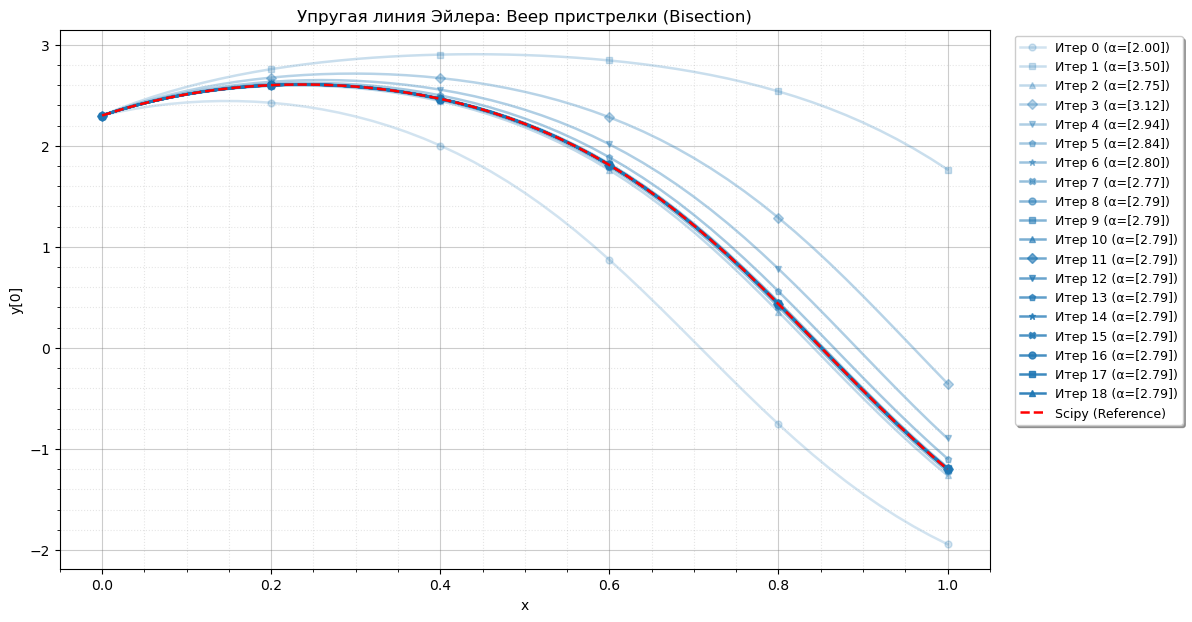


--- Веер пристрелки (Ext Newton): Упругая линия Эйлера ---


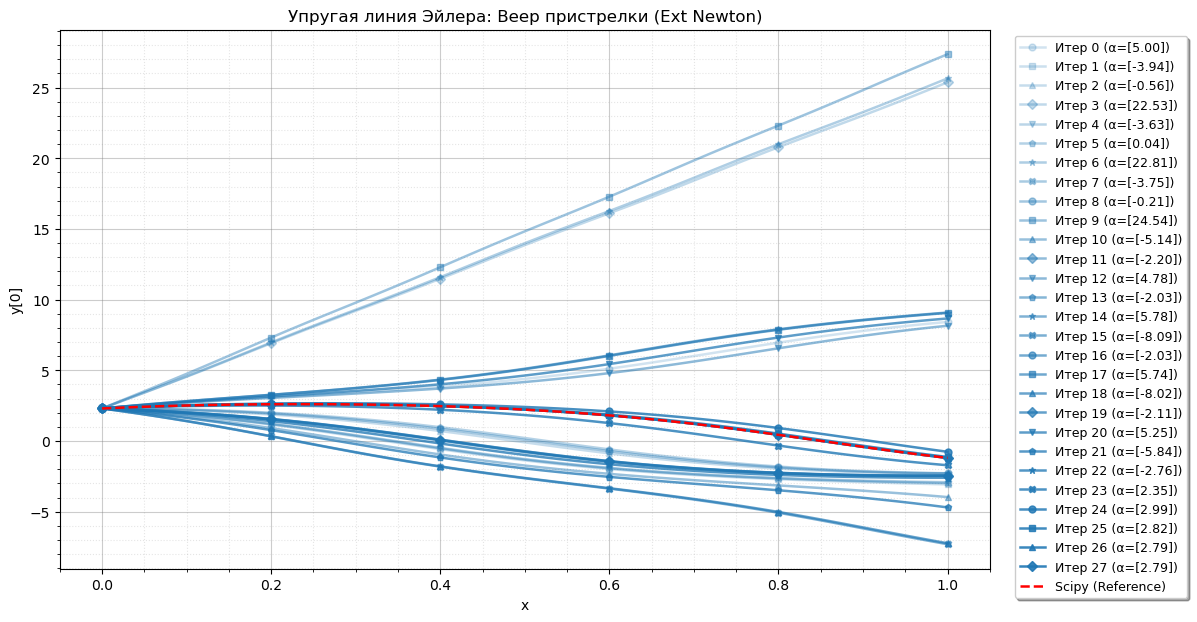


--- Веер пристрелки (FD Newton): Упругая линия Эйлера ---


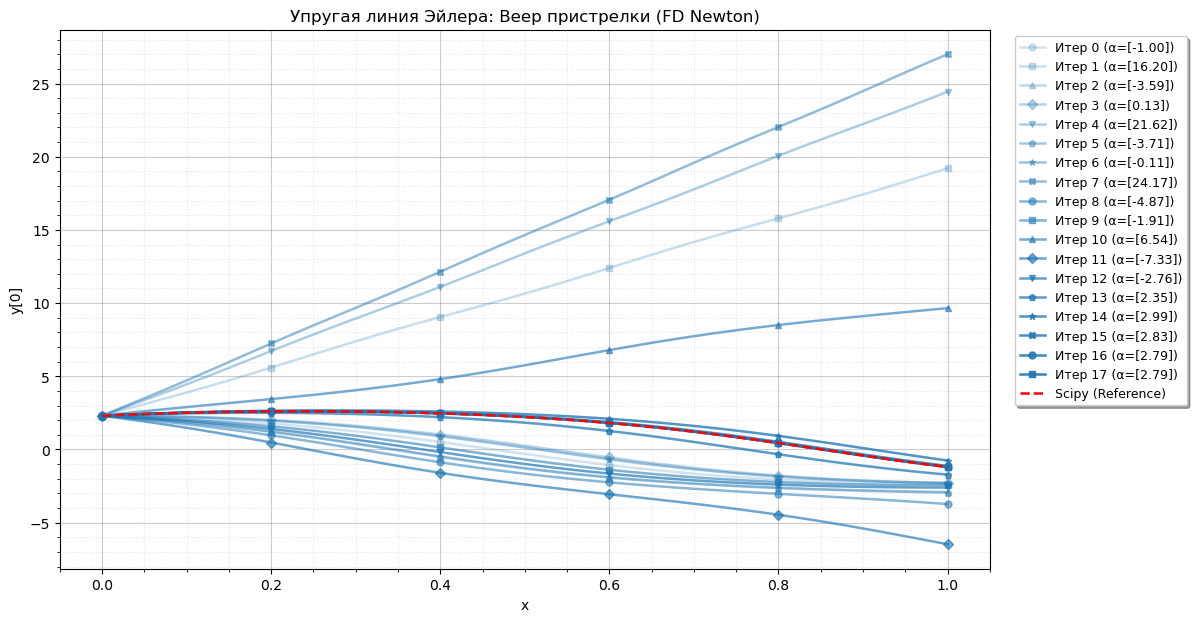

In [437]:
# ----------------------------------
#     5. Генерация всех графиков
# ----------------------------------

# ----- 5.1. Вееры пристрелки (3 графика) -----
run_shooting_fan(
    euler_prob,
    "Bisection",
    euler_shoot_bis,
    guess=np.array([-1.0, 5]),
    ref_x=x_ref_eu,
    ref_y=y_ref_eu,
    plot_dim_y=0,
)

run_shooting_fan(
    euler_prob,
    "Ext Newton",
    euler_shoot_ext,
    guess=np.array([5]),
    ref_x=x_ref_eu,
    ref_y=y_ref_eu,
    plot_dim_y=0,
)

run_shooting_fan(
    euler_prob,
    "FD Newton",
    euler_shoot_fd,
    guess=np.array([-1]),
    ref_x=x_ref_eu,
    ref_y=y_ref_eu,
    plot_dim_y=0,
)


--- Эволюция квазилинеаризации (Скалярная прогонка): Упругая линия Эйлера ---


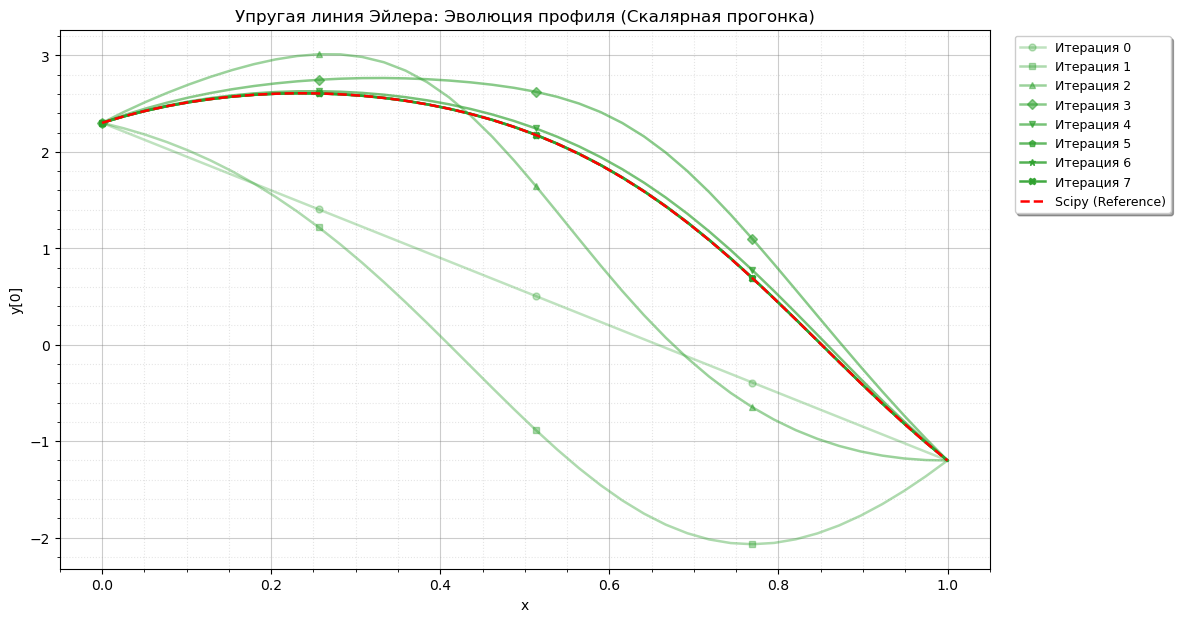

In [438]:
# ----- 5.2. Эволюция квазилинеаризации -----
# Shape: x_grid_eu is (N_GRID,), linear_profile is (N_GRID,)
guess_prof = (x_grid_eu, np.linspace(theta_a, theta_b, N_GRID))

run_quasilin_evolution(
    euler_prob,
    "Скалярная прогонка",
    euler_quasilin_fd,
    guess_profile=guess_prof,
    ref_x=x_ref_eu,
    ref_y=y_ref_eu,
    plot_dim_y=0,
)

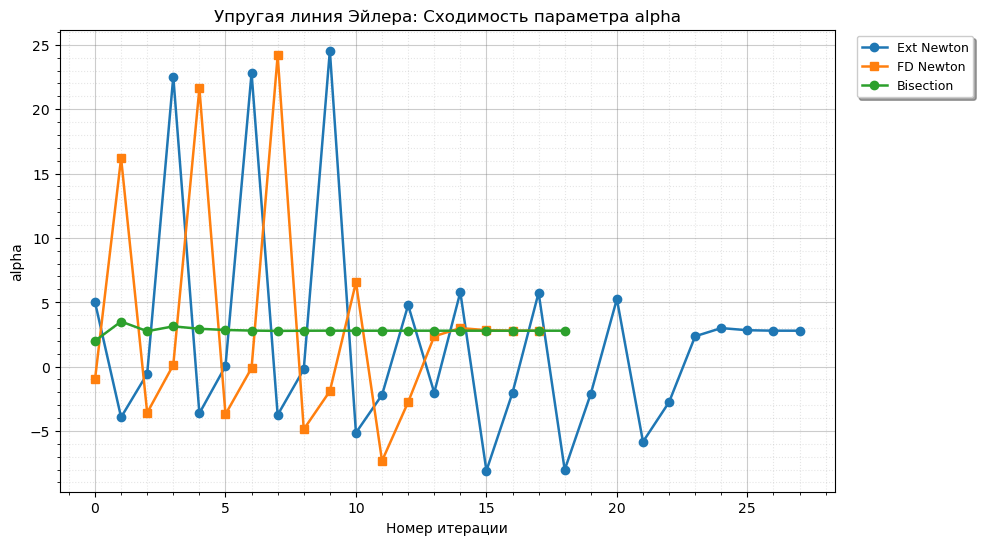

In [439]:
# ----- 5.3. Сходимость параметра alpha (Для методов пристрелки) -----
shoot_solvers = {
    "Ext Newton": euler_shoot_ext,
    "FD Newton": euler_shoot_fd,
    "Bisection": euler_shoot_bis,
}
run_parameter_convergence(euler_prob, solvers_dict=shoot_solvers, param_names=["alpha"])

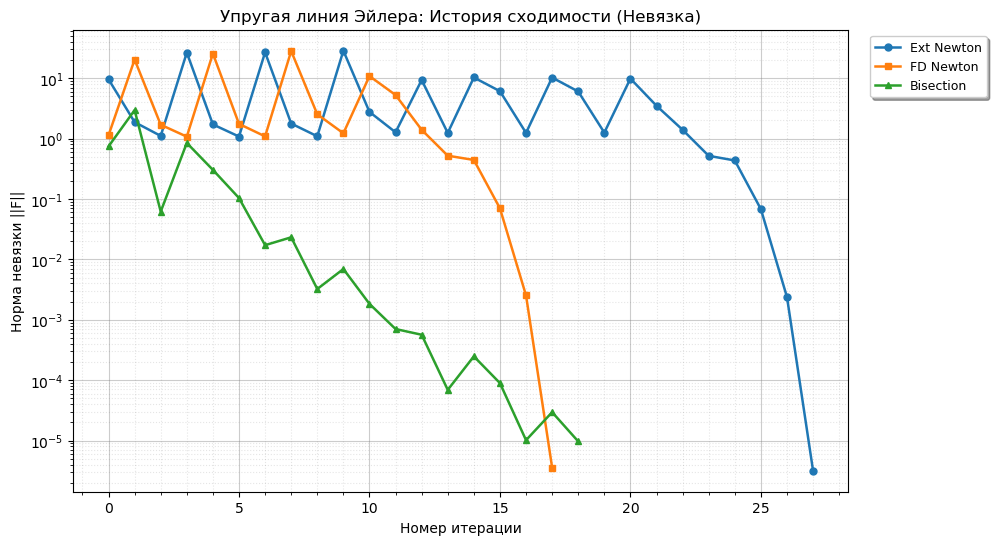

In [440]:
# ----- 5.4. История сходимости невязок (Для методов пристрелки) -----
run_convergence_history(euler_prob, solvers_dict=shoot_solvers)


--- Сравнение методов: Упругая линия Эйлера  ---
[Shoot (Ext Newton)] Сошелся за 20 итераций.
[Shoot (FD Newton)] Сошелся за 19 итераций.
[Shoot (Bisection)] Сошелся за 19 итераций.
[Quasilin (FD)] Сошелся за 7 итераций.
[Quasilin (Galerkin)] Сошелся за 8 итераций.
[Finite Diff] Сошелся за 8 итераций.


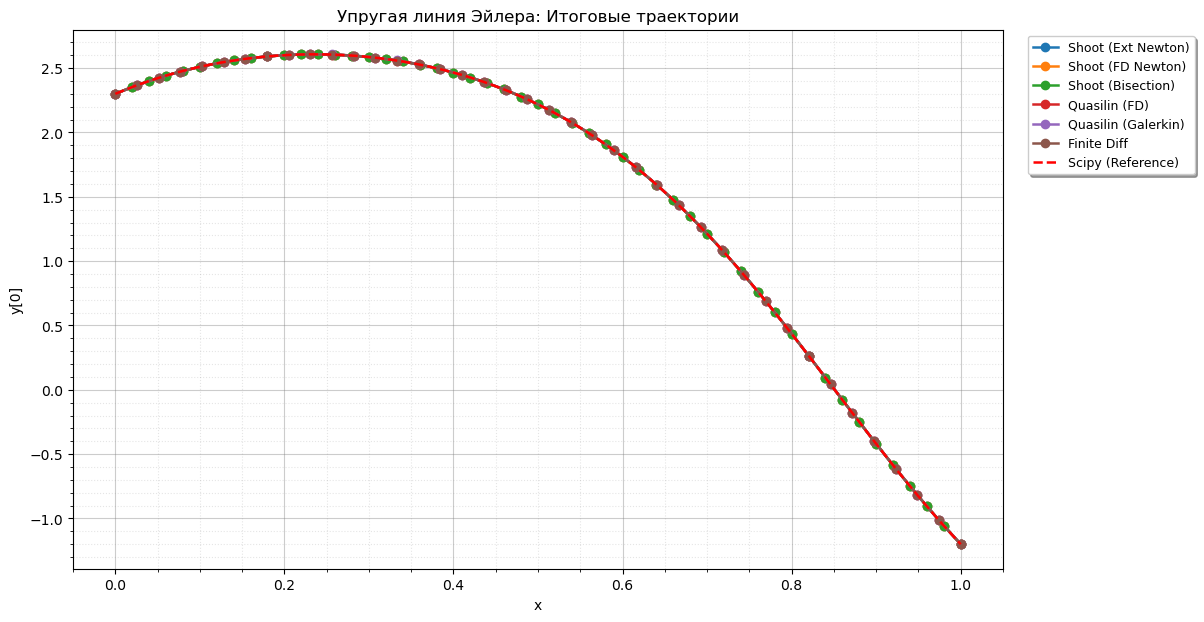

In [441]:
# ----- 5.5. Тотальное сравнение всех 6-ти методов -----
run_bvp_comparison(
    problem=euler_prob,
    solvers_dict={
        "Shoot (Ext Newton)": euler_shoot_ext,
        "Shoot (FD Newton)": euler_shoot_fd,
        "Shoot (Bisection)": euler_shoot_bis,
        "Quasilin (FD)": euler_quasilin_fd,
        "Quasilin (Galerkin)": euler_quasilin_gal,
        "Finite Diff": euler_fd_solver,
    },
    guesses_dict={
        "Shoot (Ext Newton)": np.array([0.0]),
        "Shoot (FD Newton)": np.array([0.0]),
        "Shoot (Bisection)": np.array([-1.0, 5]),
        "Quasilin (FD)": guess_prof,
        "Quasilin (Galerkin)": guess_prof,
        "Finite Diff": np.linspace(theta_a, theta_b, N_GRID),
    },
    ref_x=x_ref_eu,
    ref_y=y_ref_eu,
    plot_dim_y=0,
)

### Пример 2: Баллистика с сопротивлением воздуха

**Задача внешней баллистики** — классическая проблема механики, где нужно найти начальную скорость и угол броска снаряда так, чтобы он точно поразил мишень с координатами $(X_T, Y_T)$ за заданное время $T$.

В вакууме эта задача решается аналитически (параболическая траектория). Однако в реальной атмосфере действует сила аэродинамического сопротивления, которая пропорциональна квадрату скорости (число Рейнольдса $Re \gg 1$):
$$ \mathbf{F}_{drag} = -k |\mathbf{v}| \mathbf{v} $$

Запишем систему дифференциальных уравнений движения (4 уравнения 1-го порядка):
$$ 
\begin{cases}
x' = v_x \\
y' = v_y \\
v_x' = -\frac{c}{m} v \cdot v_x \\
v_y' = -g - \frac{c}{m} v \cdot v_y
\end{cases}
$$
где $v = \sqrt{v_x^2 + v_y^2}$ — модуль скорости.

**Краевые условия:**
Начало координат: $x(0) = 0, y(0) = 0$.
Точка попадания: $x(T) = X_T, y(T) = Y_T$.
Начальные скорости $v_{x0}, v_{y0}$ неизвестны. Мы параметризуем их через абсолютную скорость $v_0$ и угол $\theta$:
$$ v_{x0} = v_0 \cos\theta, \quad v_{y0} = v_0 \sin\theta $$
Таким образом, вектор неизвестных параметров для пристрелки: $\boldsymbol{\alpha} = [v_0, \theta]^T$.

Это существенно нелинейная векторная краевая задача.

#### Реализация

In [442]:
# ----------------------------------
#     1. Описание физики задачи
# ----------------------------------
# Физические константы: гравитация, коэффициент сопротивления, масса
g, c_drag, m = 9.81, 0.03, 1.0
# Параметры мишени и время полета
X_T, Y_T, T = 100.0, 20.0, 4.0

In [443]:
def bal_fun(t: float, y: np.ndarray) -> np.ndarray:
    """
    Правая часть системы дифференциальных уравнений внешней баллистики.

    Описывает полет снаряда с учетом квадратичного аэродинамического 
    сопротивления воздуха.

    Parameters
    ----------
    - t : float
        Текущее время полета (независимая переменная).
    - y : (4,) ndarray
        Вектор состояния системы: [x, y, v_x, v_y].

    Returns
    -------
    - dy_dt : (4,) ndarray
        Вектор производных фазовых координат по времени.

    Notes
    -----
    • *Mathematical foundation*
    Система уравнений:
    - dx/dt = v_x
    - dy/dt = v_y
    - dv_x/dt = -(c/m) * v * v_x
    - dv_y/dt = -g - (c/m) * v * v_y
    где v = sqrt(v_x^2 + v_y^2) - модуль вектора скорости.
    """
    # Shape: scalar
    vx, vy = y[2], y[3]
    v = np.sqrt(vx**2 + vy**2)
    
    # Shape: (4,)
    return np.array([vx, vy, -(c_drag / m) * v * vx, -g - (c_drag / m) * v * vy])


def bal_jac(t: float, y: np.ndarray) -> np.ndarray:
    """
    Аналитический Якобиан правой части системы уравнений баллистики.

    Parameters
    ----------
    - t : float
        Текущее время полета.
    - y : (4,) ndarray
        Вектор состояния системы: [x, y, v_x, v_y].

    Returns
    -------
    - J : (4, 4) ndarray
        Матрица производных вектора правой части по вектору состояния.

    Notes
    -----
    • *Mathematical foundation*
    - Матрица состоит из частных производных: J_{ij} = d(f_i) / d(y_j)
    - Производные скорости вычисляются по правилу сложной функции с учетом
      зависимости модуля скорости v от v_x и v_y.
    """
    # Shape: scalar
    vx, vy = y[2], y[3]
    
    # Добавление 1e-12 предотвращает деление на ноль в верхней точке сингулярности
    v = np.sqrt(vx**2 + vy**2) + 1e-12
    
    # Shape: (4, 4)
    J = np.zeros((4, 4))
    
    # Блок кинематики: dx/dt по v_x и dy/dt по v_y
    J[0, 2] = 1.0
    J[1, 3] = 1.0
    
    # Блок динамики (силы): производные ускорений по скоростям
    J[2, 2] = -(c_drag / m) * (v + vx**2 / v)
    J[2, 3] = -(c_drag / m) * (vx * vy / v)
    J[3, 2] = -(c_drag / m) * (vx * vy / v)
    J[3, 3] = -(c_drag / m) * (v + vy**2 / v)
    
    return J


def bal_bc(ya: np.ndarray, yb: np.ndarray) -> np.ndarray:
    """
    Векторная функция невязок краевых условий (целеполагания).

    Parameters
    ----------
    - ya : (4,) ndarray
        Вектор состояния в начальный момент времени t=0.
    - yb : (4,) ndarray
        Вектор состояния в конечный момент времени t=T.

    Returns
    -------
    - res : (2,) ndarray
        Невязки попадания в мишень (X_T, Y_T).
    """
    # Требуем, чтобы в момент T координаты (x, y) совпадали с координатами мишени
    # Shape: (2,)
    return np.array([yb[0] - X_T, yb[1] - Y_T])


def bal_y0(alpha: np.ndarray) -> np.ndarray:
    """
    Генератор вектора начальных условий по пристрелочным параметрам.

    Parameters
    ----------
    - alpha : (2,) ndarray
        Вектор параметров выстрела: [v_0, theta] (начальная скорость и угол).

    Returns
    -------
    - y0 : (4,) ndarray
        Полный вектор состояния в момент t=0.
    """
    # Выстрел производится из начала координат (0, 0)
    # Shape: (4,)
    return np.array(
        [0.0, 0.0, alpha[0] * np.cos(alpha[1]), alpha[0] * np.sin(alpha[1])]
    )

In [444]:
# ----------------------------------
#     Инициализация контейнера задачи
# ----------------------------------
bal_prob = BVPProblem(
    name="Баллистика",
    x_span=(0, T),
    n_dim=4,
    fun=bal_fun,
    jac=bal_jac,
    bc_residuals=bal_bc,
    y0_generator=bal_y0,
)

In [473]:
# ----------------------------------
#     2. 1D Бисекция (Фиксируем угол, ищем скорость)
# ----------------------------------
# Фиксированный угол в радианах
theta_fix = 0.55


def bal_bc_1d(ya: np.ndarray, yb: np.ndarray) -> np.ndarray:
    """
    Одномерная функция невязки: контролируем только попадание по координате X.
    
    Parameters
    ----------
    - ya : (4,) ndarray
        Начальное состояние.
    - yb : (4,) ndarray
        Конечное состояние.

    Returns
    -------
    - res : (1,) ndarray
        Отклонение от мишени по оси X.
    """
    # Shape: (1,)
    return np.array([yb[0] - X_T])


def bal_y0_1d(alpha: np.ndarray) -> np.ndarray:
    """
    Генератор начальных условий для скалярного параметра (только начальная скорость).
    
    Parameters
    ----------
    - alpha : (1,) ndarray
        Скалярный пристрелочный параметр: [v_0].

    Returns
    -------
    - y0 : (4,) ndarray
        Полный вектор состояния в момент t=0.
    """
    # Shape: (4,)
    return np.array(
        [0.0, 0.0, alpha[0] * np.cos(theta_fix), alpha[0] * np.sin(theta_fix)]
    )

In [474]:
bal_prob_1d = BVPProblem(
    name="Баллистика (1D)",
    x_span=(0, T),
    n_dim=4,
    fun=bal_fun,
    bc_residuals=bal_bc_1d,
    y0_generator=bal_y0_1d,
)

In [475]:
# ----------------------------------
#     3. Эталонное решение (SciPy)
# ----------------------------------
def _scipy_ref_bal() -> Tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет эталонное решение баллистической задачи с помощью scipy.integrate.solve_bvp.

    Returns
    -------
    - x_grid : (100,) ndarray
        Сетка времени полета.
    - y_traj : (100, 4) ndarray
        Траектория вектора состояния.
    """
    def f_sp(x: np.ndarray, y: np.ndarray) -> np.ndarray:
        v = np.sqrt(y[2] ** 2 + y[3] ** 2)
        return np.vstack(
            [y[2], y[3], -(c_drag / m) * v * y[2], -g - (c_drag / m) * v * y[3]]
        )

    def bc_sp(ya: np.ndarray, yb: np.ndarray) -> np.ndarray:
        # Требуем, чтобы в момент 0 координаты были равны 0, а в момент T равнялись X_T и Y_T
        return np.array([ya[0], ya[1], yb[0] - X_T, yb[1] - Y_T])

    # Сетка времени
    # Shape: (100,)
    xg = np.linspace(0, T, 100)
    
    # Начальное приближение функции состояния
    # Shape: (4, 100)
    yg = np.zeros((4, 100))
    yg[0], yg[1] = np.linspace(0, X_T, 100), np.linspace(0, Y_T, 100)
    # Примерная оценка средних скоростей
    yg[2], yg[3] = X_T / T, Y_T / T
    
    sol = sp_int.solve_bvp(f_sp, bc_sp, xg, yg)
    
    return sol.x, sol.y.T


x_ref_bal, y_ref_bal = _scipy_ref_bal()

In [476]:
# ----------------------------------
#     4. Инициализация решателей
# ----------------------------------
bal_shoot_ext = ShootingSolver(
    fun=bal_fun,
    bc_residuals=bal_bc,
    x_span=(0, T),
    n_dim=4,
    y0_generator=bal_y0,
    jac_fun=bal_jac,
    step_size=0.02,
)

bal_shoot_fd = ShootingFDNewton(
    fun=bal_fun,
    bc_residuals=bal_bc,
    x_span=(0, T),
    n_dim=4,
    y0_generator=bal_y0,
    step_size=0.02,
)

bal_shoot_bis = ShootingBisection(
    fun=bal_fun,
    bc_residuals=bal_bc_1d,
    x_span=(0, T),
    n_dim=4,
    y0_generator=bal_y0_1d,
    step_size=0.02,
)

# Маски и значения для линейной векторной краевой задачи (Метод суперпозиции)
bc_prm = {
    "left_mask": np.array([True, True, False, False]),
    "left_vals": np.array([0.0, 0.0, 0.0, 0.0]),
    "right_mask": np.array([True, True, False, False]),
    "right_vals": np.array([X_T, Y_T, 0.0, 0.0]),
}

bal_quasilin = QuasilinearizationSolver(
    fun=bal_fun,
    jac_fun=bal_jac,
    x_span=(0, T),
    n_dim=4,
    mode="vector",
    bc_params=bc_prm,
)


--- Веер пристрелки (Bisection (1D)): Баллистика (1D) ---


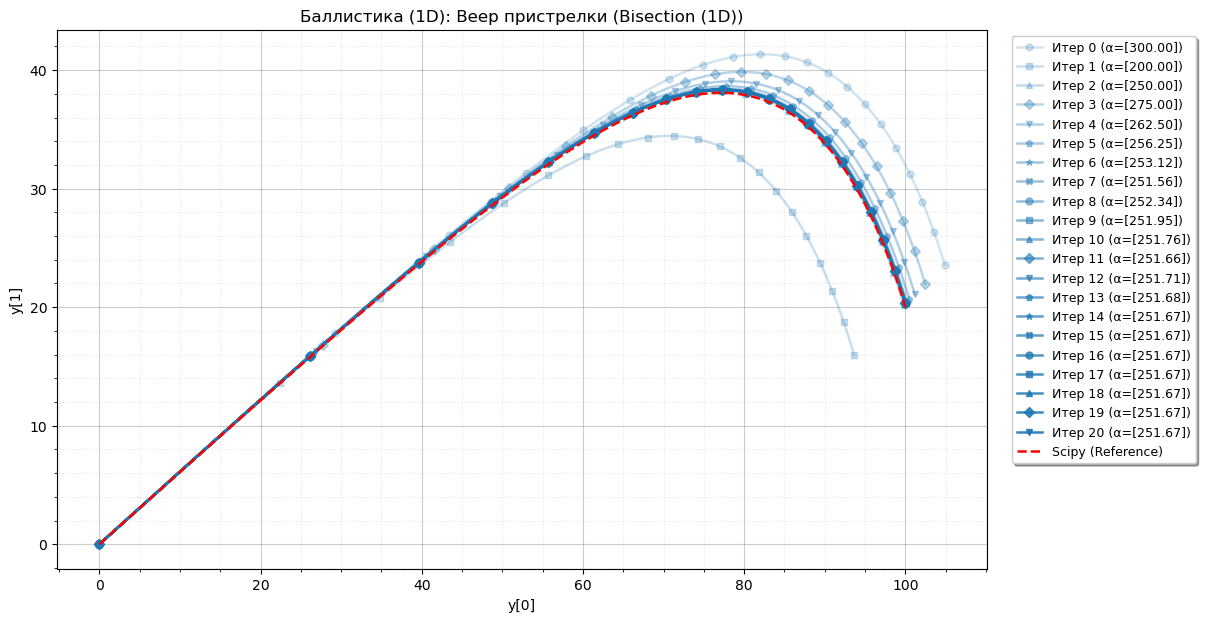

In [479]:
# ----------------------------------
#     5. Генерация графиков
# ----------------------------------
# Веер пристрелки: поиск скорости (Бисекция)
run_shooting_fan(
    bal_prob_1d,
    "Bisection (1D)",
    bal_shoot_bis,
    guess=np.array([100.0, 500.0]),
    ref_x=x_ref_bal,
    ref_y=y_ref_bal,
    plot_dim_y=1,
    plot_dim_x=0,
)


--- Веер пристрелки (Ext Newton): Баллистика ---


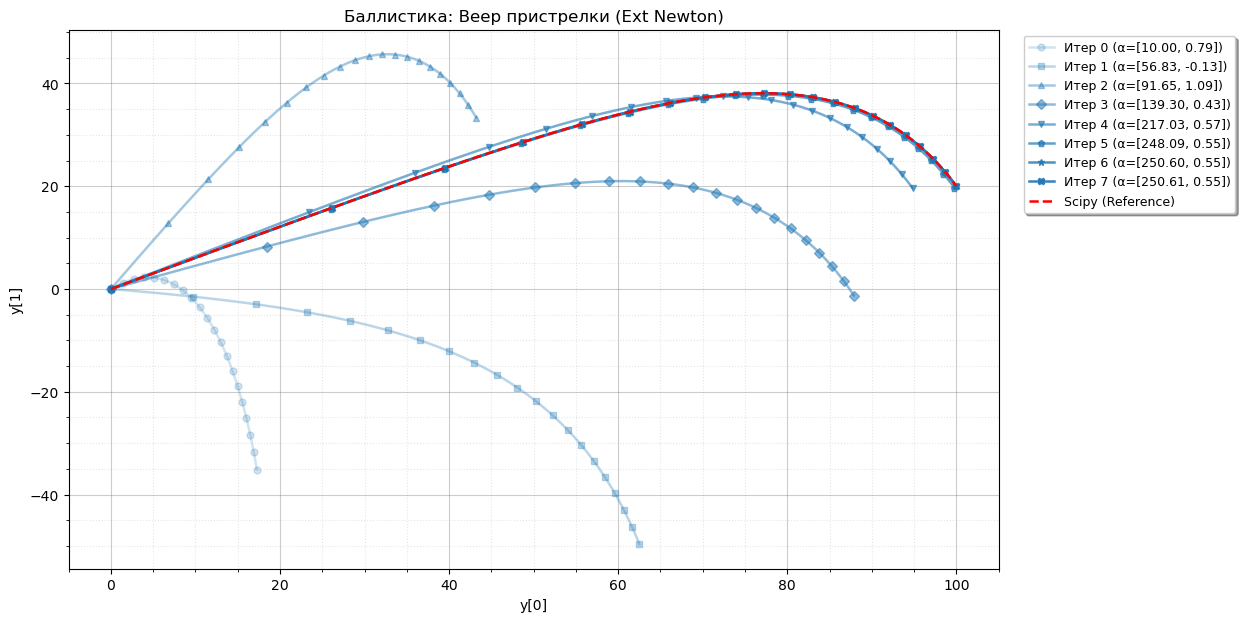

In [478]:
# Веер пристрелки: 2D параметры (Расширенный Ньютон)
run_shooting_fan(
    bal_prob,
    "Ext Newton",
    bal_shoot_ext,
    guess=np.array([10.0, 45.0 * np.pi / 180.0]),
    ref_x=x_ref_bal,
    ref_y=y_ref_bal,
    plot_dim_y=1,
    plot_dim_x=0,
)


--- Веер пристрелки (FD Newton): Баллистика ---


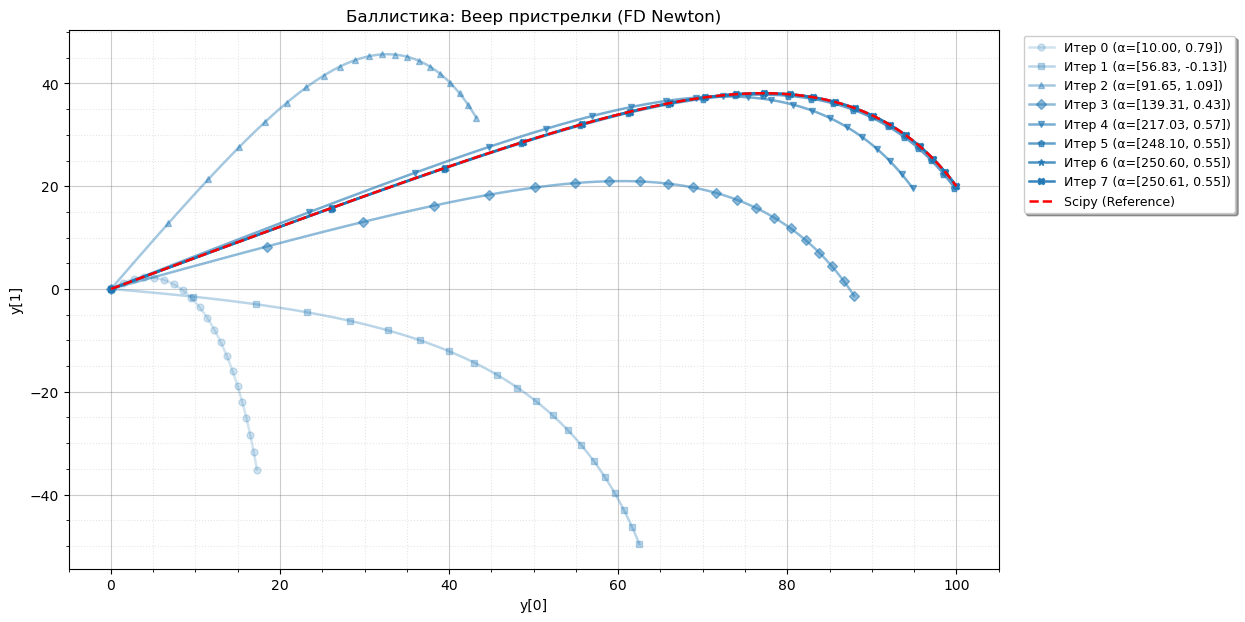

In [471]:
# Веер пристрелки: 2D параметры (Конечно-разностный Ньютон)
run_shooting_fan(
    bal_prob,
    "FD Newton",
    bal_shoot_fd,
    guess=np.array([10.0, 45.0 * np.pi / 180.0]),
    ref_x=x_ref_bal,
    ref_y=y_ref_bal,
    plot_dim_y=1,
    plot_dim_x=0,
)


--- Эволюция квазилинеаризации (Векторная суперпозиция): Баллистика ---


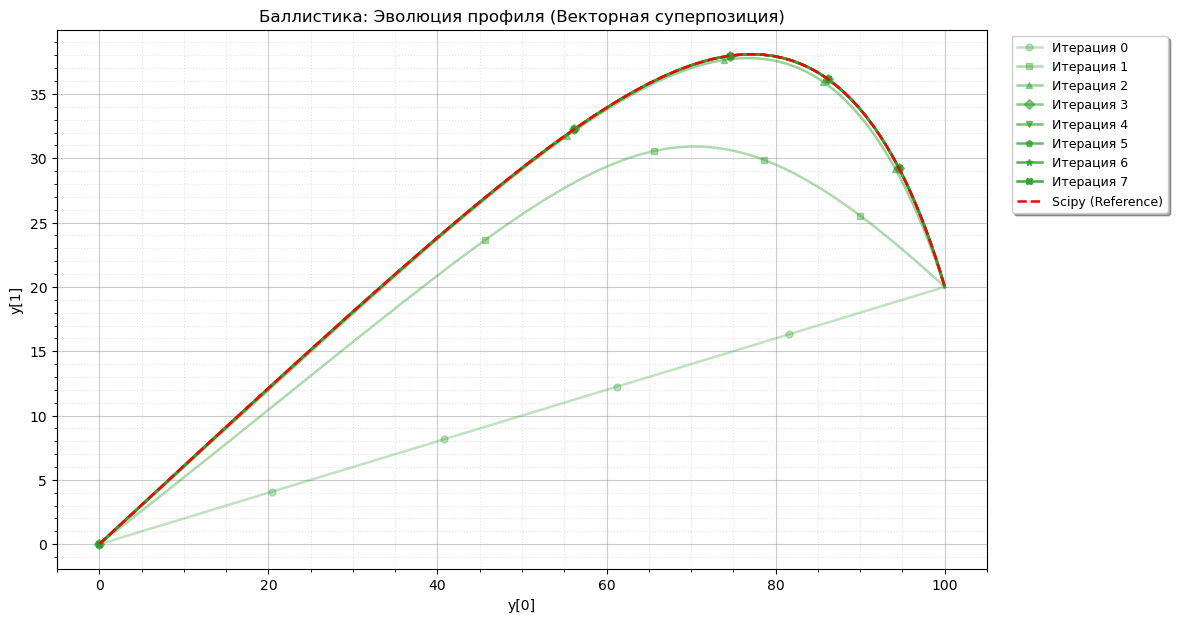

In [452]:
# Эволюция Квазилинеаризации
# Shape: x_grid_bal is (50,), y_g_bal is (50, 4)
x_grid_bal = np.linspace(0, T, 50)
y_g_bal = np.zeros((50, 4))
y_g_bal[:, 0] = np.linspace(0, X_T, 50)
y_g_bal[:, 1] = np.linspace(0, Y_T, 50)
y_g_bal[:, 2], y_g_bal[:, 3] = X_T / T, Y_T / T

run_quasilin_evolution(
    bal_prob,
    "Векторная суперпозиция",
    bal_quasilin,
    guess_profile=(x_grid_bal, y_g_bal),
    ref_x=x_ref_bal,
    ref_y=y_ref_bal,
    plot_dim_y=1,
    plot_dim_x=0,
)

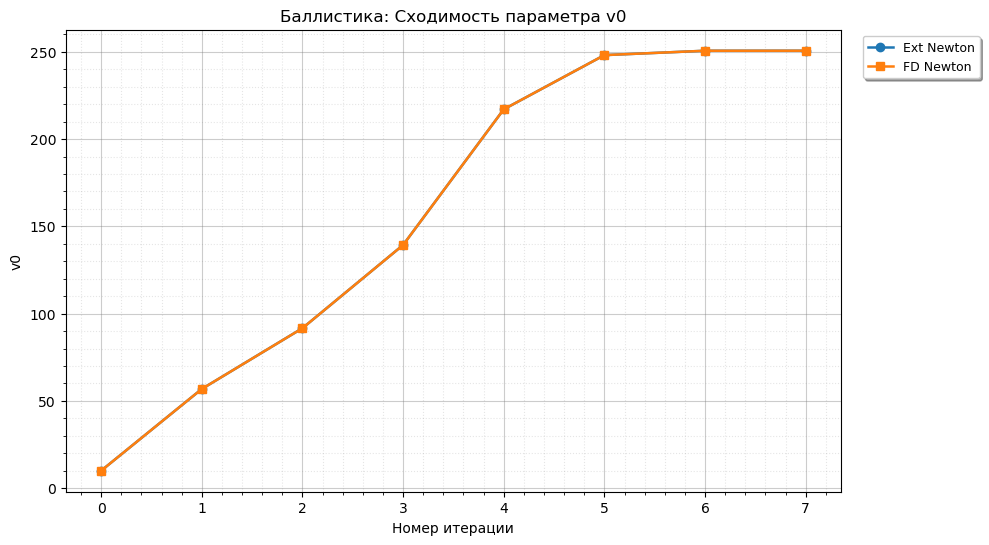

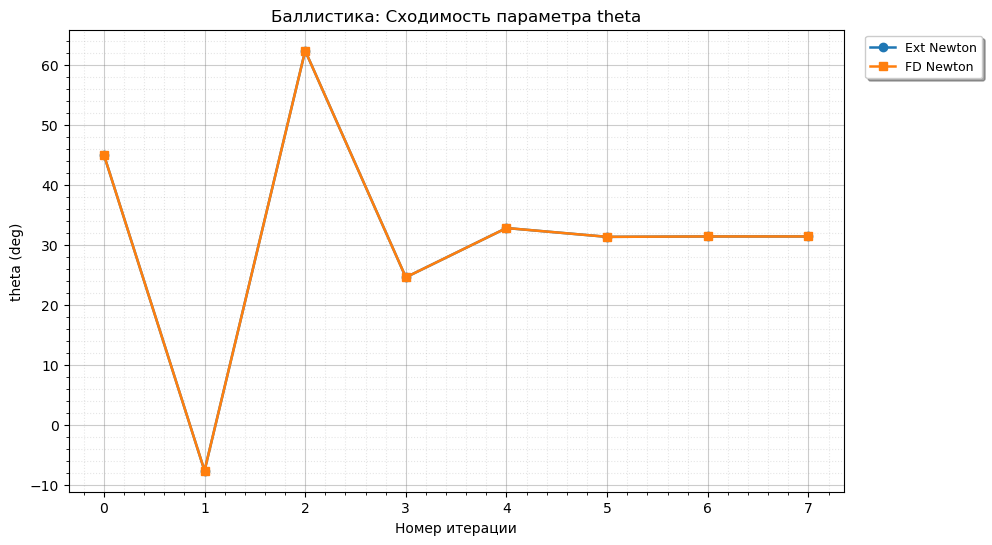

In [453]:
# Сходимость параметров (v0 и theta)
run_parameter_convergence(
    bal_prob,
    solvers_dict={"Ext Newton": bal_shoot_ext, "FD Newton": bal_shoot_fd},
    param_names=["v0", "theta"],
)

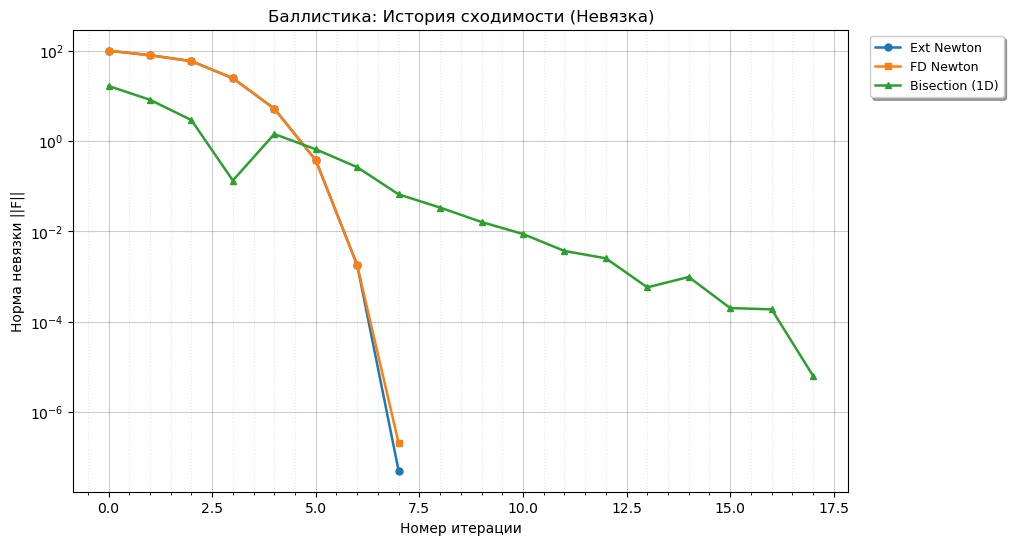

In [454]:
run_convergence_history(
    bal_prob,
    solvers_dict={
        "Ext Newton": bal_shoot_ext,
        "FD Newton": bal_shoot_fd,
        "Bisection (1D)": bal_shoot_bis,
        # "Quasilinearization": bal_quasilin,
    }
)


--- Сравнение методов: Баллистика  ---
[Ext Newton] Сошелся за 8 итераций.
[FD Newton] Сошелся за 8 итераций.
[Quasilinearization] Сошелся за 7 итераций.


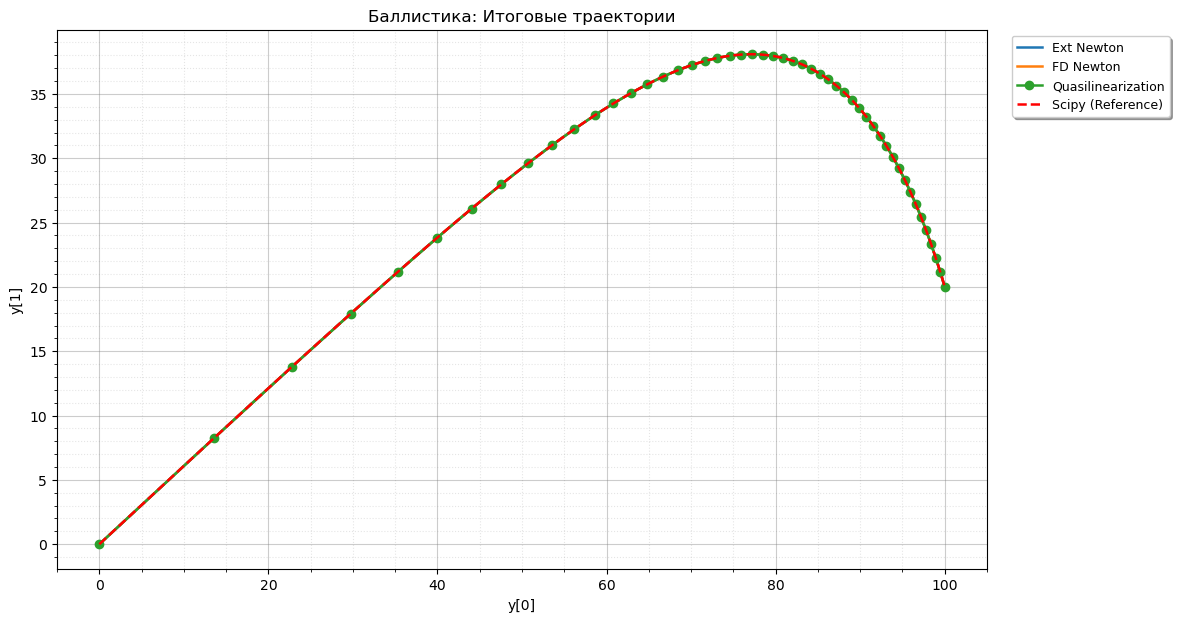

In [455]:
# Тотальное сравнение алгоритмов
run_bvp_comparison(
    bal_prob,
    solvers_dict={
        "Ext Newton": bal_shoot_ext,
        "FD Newton": bal_shoot_fd,
        "Quasilinearization": bal_quasilin,
    },
    guesses_dict={
        "Ext Newton": np.array([10.0, 45.0 * np.pi / 180.0]),
        "FD Newton": np.array([10.0, 45.0 * np.pi / 180.0]),
        "Quasilinearization": (x_grid_bal, y_g_bal),
    },
    ref_x=x_ref_bal,
    ref_y=y_ref_bal,
    plot_dim_y=1,
    plot_dim_x=0,
)

### Пример 3: Квантовый гармонический осциллятор (Поиск собственных значений)

**Квантовый гармонический осциллятор** — это одна из немногих квантовых систем, допускающих точное аналитическое решение.
Уравнение Шрёдингера в безразмерных единицах (где $\hbar=1, m=1, \omega=1$) для частицы в параболическом потенциале $V(x) = x^2$ имеет вид:
$$ \psi''(x) + (E - x^2)\psi(x) = 0 $$
Где $\psi(x)$ — волновая функция, а $E$ — энергия частицы.

Квантовая механика требует, чтобы частица была локализована в пространстве, следовательно, волновая функция должна затухать на бесконечности:
$$ \psi(x) \to 0 \quad \text{при} \quad x \to \pm \infty $$

На практике мы обрезаем бесконечную область до конечного интервала $[-L, L]$, где потенциальная стенка достаточно высока, и ставим граничные условия Дирихле:
$$ \psi(-L) = 0, \quad \psi(L) = 0 $$

Аналитическое решение утверждает, что энергетические уровни (собственные значения) квантуются:
$$ E_n = 2n + 1 \quad (n = 0, 1, 2, \dots) $$
А собственные функции выражаются через полиномы Эрмита: $\psi_n(x) \propto H_n(x) e^{-x^2 / 2}$.

Мы решим эту задачу двумя инструментами:
1. **Метод Галеркина на собственные значения** (найдет весь спектр сразу).
2. **Расширенный метод Пристрелки** (где $E$ выступает как параметр состояния).

#### Реализация

In [456]:
# ----------------------------------
#     1. Описание физики задачи
# ----------------------------------
L_osc = 6.0

In [457]:
def analytical_psi(n: int, x: np.ndarray) -> np.ndarray:
    """
    Вычисляет точную аналитическую волновую функцию осциллятора.

    Parameters
    ----------
    - n : int
        Главное квантовое число (номер энергетического уровня).
    - x : (N,) ndarray
        Пространственная сетка.

    Returns
    -------
    - psi_norm : (N,) ndarray
        L2-нормированная волновая функция.

    Notes
    -----
    • *Mathematical foundation*
    - Волновая функция: psi_n(x) = H_n(x) * exp(-x^2 / 2)
    - H_n(x) - полиномы Эрмита, вычисляемые по рекуррентной формуле:
      H_{n+1}(x) = 2x H_n(x) - 2n H_{n-1}(x)
    """
    # Shape: (N,)
    H_prev, H_curr = np.ones_like(x), 2.0 * x
    
    # ----------------- Рекурсия полиномов Эрмита -----------------
    if n == 0:
        H = H_prev
    elif n == 1:
        H = H_curr
    else:
        for k in range(1, n):
            # Shape: (N,)
            H_next = 2 * x * H_curr - 2 * k * H_prev
            H_prev, H_curr = H_curr, H_next
        H = H_curr
        
    # Базисная экспонента
    # Shape: (N,)
    psi = H * np.exp(-(x**2) / 2.0)
    
    # Нормировка (интеграл от квадрата модуля равен 1)
    return psi / float(np.sqrt(np.trapezoid(psi**2, x)))


def osc_fun(x: float, y_base: np.ndarray, E: float) -> np.ndarray:
    """
    Правая часть уравнения Шрёдингера для гармонического осциллятора.

    Parameters
    ----------
    - x : float
        Пространственная координата.
    - y_base : (2,) ndarray
        Базовый вектор состояния [psi, psi'].
    - E : float
        Энергия (параметр уравнения, играющий роль собственного значения).

    Returns
    -------
    - dy_dx : (2,) ndarray
        Вектор производных состояний.
    """
    # Уравнение: psi'' + (E - x^2)*psi = 0 -> psi'' = (x^2 - E)*psi
    # Shape: (2,)
    return np.array([y_base[1], (x**2 - E) * y_base[0]], dtype=np.float64)


def osc_jac(x: float, y_base: np.ndarray, E: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Аналитический Якобиан правой части осциллятора.

    Parameters
    ----------
    - x : float
        Пространственная координата.
    - y_base : (2,) ndarray
        Базовый вектор состояния.
    - E : float
        Текущая оценка энергии.

    Returns
    -------
    - tuple
        Кортеж (J_y, J_E):
        - J_y : (2, 2) ndarray, производные f по вектору состояния y.
        - J_E : (2, 1) ndarray, производные f по параметру E.
    """
    # Shape: J_y is (2, 2), J_E is (2, 1)
    return (
        np.array([[0.0, 1.0], [x**2 - E, 0.0]], dtype=np.float64), 
        np.array([[0.0], [-y_base[0]]], dtype=np.float64)
    )


def osc_bc(ya: np.ndarray, yb: np.ndarray) -> np.ndarray:
    """
    Граничное условие: волновая функция должна затухать на правой границе.

    Parameters
    ----------
    - ya : (2,) ndarray
        Состояние на левой границе (x = -L).
    - yb : (2,) ndarray
        Состояние на правой границе (x = L).

    Returns
    -------
    - res : (1,) ndarray
        Невязка (значение волновой функции на правом конце).
    """
    # Требуем psi(L) = 0
    # Shape: (1,)
    return np.array([yb[0]], dtype=np.float64)


def osc_y0(alpha: np.ndarray) -> np.ndarray:
    """
    Генератор расширенного начального вектора.

    Включает фиксированные малые начальные значения (чтобы запустить интегрирование) 
    и неизвестный параметр энергии E.

    Parameters
    ----------
    - alpha : (1,) ndarray
        Вектор параметров (содержит только E).

    Returns
    -------
    - y0_ext : (3,) ndarray
        Расширенный начальный вектор: [psi(-L), psi'(-L), E].
    """
    # Shape: (3,)
    return np.array([1e-6, 1e-6, alpha[0]], dtype=np.float64)

In [458]:
# ----------------------------------
#     Инициализация решателей
# ----------------------------------
osc_shoot_ext = ExtendedVectorShootingSolver(
    fun_parametrized=osc_fun,
    bc_residuals=osc_bc,
    x_span=(-L_osc, L_osc),
    n_dim=2,
    y0_generator_ext=osc_y0,
    jac_parametrized=osc_jac,
    step_size=0.02,
)

osc_shoot_fd = ExtendedVectorShootingSolver(
    fun_parametrized=osc_fun,
    bc_residuals=osc_bc,
    x_span=(-L_osc, L_osc),
    n_dim=2,
    y0_generator_ext=osc_y0,
    step_size=0.02,
)

gal_osc = EigenvalueGalerkinSolver(
    x_span=(-L_osc, L_osc), 
    n_nodes=300, 
    v_fun=lambda x: x**2
)

In [459]:
# ----------------------------------
#     2. Решение и агрегация
# ----------------------------------
# Интервалы и начальные догадки для уровней энергии (n = 0, 1, 2, 3)
intervals = [(-0.5, 1.5), (2.5, 3.5), (4.5, 5.5), (6.5, 7.5)]
guesses = [1.0, 3.0, 5.0, 7.0]

results: Dict[str, List[Tuple[float, np.ndarray, np.ndarray]]] = {
    m:[] for m in ["bisection", "newton_extended", "newton_finite_diff", "galerkin"]
}

# ----- 2a. Галеркин решает весь спектр сразу -----
x_gal, spectrum = gal_osc.solve_spectrum(num_modes=4)
for E_n, psi in spectrum:
    results["galerkin"].append((E_n, x_gal, psi))

# ----- 2b. Перебор мод для методов пристрелки -----
for i in range(4):
    a_bis, (t, Y_b) = osc_shoot_fd.solve(intervals[i], root_method="bisection")
    
    a_ext, (_, Y_e) = osc_shoot_ext.solve(
        np.array([guesses[i]]), root_method="newton_extended"
    )
    
    a_fd, (_, Y_f) = osc_shoot_fd.solve(
        np.array([guesses[i]]), root_method="newton_finite_diff"
    )

    for rm, a, Y in [
        ("bisection", a_bis, Y_b),
        ("newton_extended", a_ext, Y_e),
        ("newton_finite_diff", a_fd, Y_f),
    ]:
        # Извлекаем волновую функцию из расширенного вектора состояний
        # Shape: (Steps,)
        psi = Y[:, 0]
        
        # L2-Нормировка
        psi = psi / np.sqrt(np.trapezoid(psi**2, t))
        
        # Коррекция фазы (сверка знака с аналитическим решением)
        if np.sum(psi * analytical_psi(i, t)) < 0:
            psi = -psi
            
        results[rm].append((float(a[0]), t, psi))

In [460]:
# ----------------------------------
#     3. Построение графиков
# ----------------------------------

In [461]:
# ----- График 2: Уровни энергии (psi + E) -----
x_p = np.linspace(-L_osc, L_osc, 500)

y_tot, x_tot, lbl_tot, clr_tot, lst_tot, mrk_tot = (
    [x_p**2], # Внимание: переменная x_p не определена в исходном коде
    [x_p],
    [r"$V(x) = x^2$"],
    ["black"],
    ["-"],
    [""],
)

for i in range(4):
    E, x_num, p_num = results["bisection"][i]
    
    # Добавление линии энергии, аналитического профиля и численного профиля
    y_tot.extend([np.full_like(x_num, E), analytical_psi(i, x_p) + E, p_num + E])
    x_tot.extend([x_num, x_p, x_num])
    
    lbl_tot.extend(
        [
            rf"$E_{i} = {E:.2f}$" if i == 0 else "_nolegend_",
            "Analytical" if i == 0 else "_nolegend_",
            "Bisection" if i == 0 else "_nolegend_",
        ]
    )
    clr_tot.extend(["gray", "red", f"C{i}"])
    lst_tot.extend(["--", "-", "-"])
    mrk_tot.extend(["", "", "o"])

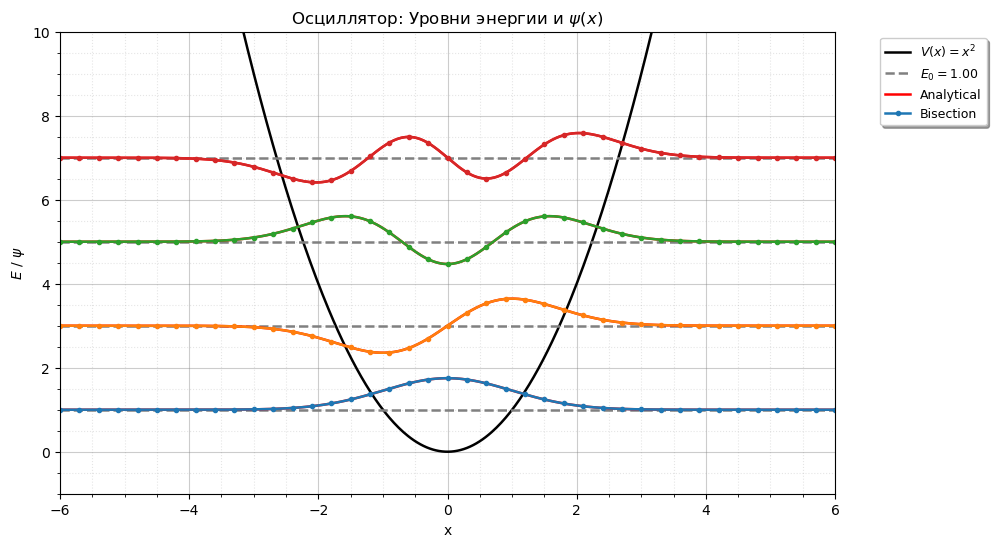

In [462]:
pt.plot_signals(
    y_tot,
    x_tot,
    labels=lbl_tot,
    colors=clr_tot,
    linestyles=lst_tot,
    markers=mrk_tot,
    markersize=3,
    markevery=15,
    title=r"Осциллятор: Уровни энергии и $\psi(x)$",
    xlabel="x",
    ylabel=r"$E \ / \ \psi$",
    limits=((-L_osc, L_osc), (-1, 10)),
)

In [463]:
# ----- График 3: Плотности вероятности (|psi|^2 + E) -----
y_sq = (
    [x_p**2]
    + [
        np.full_like(results["bisection"][i][1], results["bisection"][i][0])
        for i in range(4)
    ]
    + [analytical_psi(i, x_p) ** 2 + results["bisection"][i][0] for i in range(4)]
    + [results["bisection"][i][2] ** 2 + results["bisection"][i][0] for i in range(4)]
)

x_sq = (
    [x_p]
    + [results["bisection"][i][1] for i in range(4)]
    + [x_p] * 4
    + [results["bisection"][i][1] for i in range(4)]
)

lbl_sq = (
    [r"$V(x) = x^2$"]
    + [
        rf"$E_{i} = {results['bisection'][i][0]:.2f}$" if i == 0 else "_nolegend_"
        for i in range(4)
    ]
    + ["Analytical" if i == 0 else "_nolegend_"] * 4
    + ["Bisection" if i == 0 else "_nolegend_"] * 4
)

clr_sq = ["black"] + ["gray"] * 4 + ["red"] * 4 + [f"C{i}" for i in range(4)]
lst_sq = ["-"] + ["--"] * 4 + ["-"] * 4 + ["-"] * 4
mrk_sq = [""] * 9 + ["o"] * 4

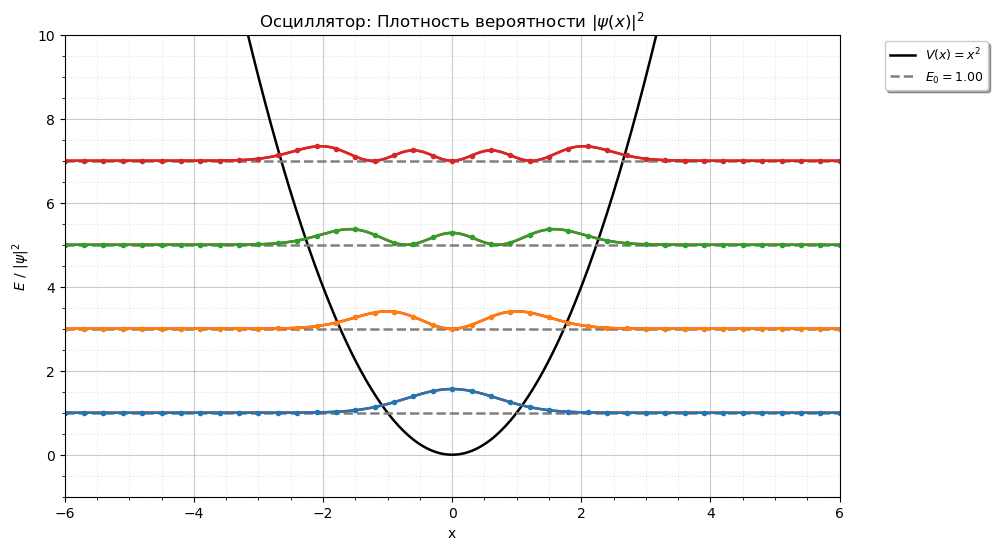

In [464]:
pt.plot_signals(
    y_sq,
    x_sq,
    labels=lbl_sq,
    colors=clr_sq,
    linestyles=lst_sq,
    markers=mrk_sq,
    markersize=3,
    markevery=15,
    title=r"Осциллятор: Плотность вероятности $|\psi(x)|^2$",
    xlabel="x",
    ylabel=r"$E \ / \ |\psi|^2$",
    limits=((-L_osc, L_osc), (-1, 10)),
)

### Пример 4: Атом водорода

**Атом водорода** — это квантовомеханическая система из электрона, движущегося в центрально-симметричном кулоновском поле ядра $V(r) = -1/r$. В нерелятивистском приближении стационарные состояния системы полностью описываются набором коммутирующих операторов $\hat{H}, \hat{L}^2, \hat{L}_z$.

**1. Разделение переменных:**
Благодаря сферической симметрии гамильтониана, трехмерное уравнение Шрёдингера $\hat{H}\Psi = E\Psi$ допускает точное разделение переменных. Волновая функция ищется в виде:
$$ \Psi_{nlm}(r, \theta, \varphi) = \frac{u_{nl}(r)}{r} Y_l^m(\theta, \varphi) = \frac{u_{nl}(r)}{r} \Theta_{lm}(\theta) \Phi_m(\varphi) $$
где $n, l, m$ — главное, орбитальное и магнитное квантовые числа соответственно.

**2. Угловая часть (Сферические гармоники $Y_l^m$):**
Угловая зависимость определяется уравнением на собственные значения квадрата углового момента $\hat{L}^2 Y_l^m = l(l+1) Y_l^m$, которое распадается на два независимых дифференциальных уравнения:

*   **Азимутальное уравнение (на $\varphi$):**
    Описывает проекцию углового момента на ось $z$.
    $$ \frac{d^2 \Phi}{d\varphi^2} + m^2 \Phi = 0 $$
    Из физического требования однозначности волновой функции $\Phi(\varphi + 2\pi) = \Phi(\varphi)$ следует дискретный спектр $m \in \mathbb{Z}$ ($m = 0, \pm 1, \pm 2, \dots$). Решения имеют вид: $\Phi_m(\varphi) = \frac{1}{\sqrt{2\pi}} e^{im\varphi}$.

*   **Полярное уравнение (на $\theta$):**
    $$ \frac{1}{\sin\theta} \frac{d}{d\theta} \left( \sin\theta \frac{d\Theta}{d\theta} \right) + \left( l(l+1) - \frac{m^2}{\sin^2\theta} \right) \Theta = 0 $$
    Регулярные (конечные) решения этого уравнения на отрезке $\theta \in [0, \pi]$ существуют только при $l \ge |m|$ и выражаются через нормированные присоединенные полиномы Лежандра $P_l^{|m|}(\cos \theta)$. В нашей реализации мы можем напрямую интегрировать это ОДУ как задачу Коши для построения точных 3D-моделей орбиталей.

**3. Радиальное уравнение:**
После выделения угловой части, для функции $u(r)$ получается эффективное одномерное уравнение Шрёдингера:
$$ u''(r) + \left( E + \frac{1}{r} - \frac{l(l+1)}{r^2} \right) u(r) = 0 $$
*   **Слагаемые:** Слагаемое $1/r$ отвечает за кулоновское притяжение, а центробежный барьер $\frac{l(l+1)}{r^2}$ «отталкивает» электрон от ядра при $l > 0$.
*   **Граничные условия:** $u(0) = 0$ (регулярность в начале координат) и $u(r \to \infty) = 0$ (нормируемость связанного состояния).
*   **Спектр энергий:** Требование конечности волновой функции на бесконечности приводит к жесткому квантованию энергии, зависящему только от главного квантового числа $n$ ($n > l$):
$$ E_n = -\frac{1}{4 n^2} \quad \text{(в Ридбергах, с учетом масштабирования уравнения)} $$

#### Реализация

In [245]:
# ----------------------------------
#     1. Радиальные волновые функции (Пристрелка по энергии)
# ----------------------------------
# Параметры интегрирования: правая граница и отступ от нуля (из-за сингулярности 1/r)
R_max_H, eps_H = 40.0, 1e-4

In [246]:
def get_hydro_solver(l_val: int) -> ExtendedVectorShootingSolver:
    """
    Создает решатель для радиального уравнения Шрёдингера атома водорода.

    Рассматривается уравнение для функции u(r) = r * R(r).
    В связи с сингулярностью кулоновского потенциала в нуле, интегрирование
    начинается с малой величины eps_H, где начальные условия задаются
    асимптотическим разложением.

    Parameters
    ----------
    - l_val : int
        Орбитальное квантовое число (определяет центробежный барьер).

    Returns
    -------
    - solver : ExtendedVectorShootingSolver
        Экземпляр решателя методом расширенной пристрелки по параметру E.

    Notes
    -----
    • *Mathematical foundation*
    - Радиальное уравнение: u'' + (E + 1/r - l(l+1)/r^2)u = 0
    - Асимптотика при r -> 0: u(r) ~ r^(l+1)
    """
    
    def H_fun(x: float, y_base: np.ndarray, E: float) -> np.ndarray:
        # Уравнение 2-го порядка сведено к системе двух уравнений 1-го порядка
        # Shape: (2,)
        return np.array(
            [y_base[1], (-E - 1.0 / x + l_val * (l_val + 1) / (x**2)) * y_base[0]],
            dtype=np.float64
        )

    def H_bc(ya: np.ndarray, yb: np.ndarray) -> np.ndarray:
        # Граничное условие на бесконечности (правом конце): u(r_max) = 0
        # Shape: (1,)
        return np.array([yb[0]], dtype=np.float64)

    def H_y0(alpha: np.ndarray) -> np.ndarray:
        # Начальные условия задаются аналитической асимптотикой в точке eps_H.
        # Третий элемент - пристрелочный параметр (энергия E).
        # Shape: (3,)
        return np.array(
            [eps_H ** (l_val + 1), (l_val + 1) * eps_H**l_val, alpha[0]], 
            dtype=np.float64
        )

    return ExtendedVectorShootingSolver(
        fun_parametrized=H_fun,
        bc_residuals=H_bc,
        x_span=(eps_H, R_max_H),
        n_dim=2,
        y0_generator_ext=H_y0,
        step_size=0.02,
    )

In [247]:
# Конфигурации для поиска уровней: (n, l, интервал_поиска_E)
configs: List[Tuple[int, int, Tuple[float, float]]] = [
    (1, 0, (-0.4, -0.1)),
    (2, 0, (-0.1, -0.04)),
    (2, 1, (-0.1, -0.04)),
    (3, 0, (-0.04, -0.01)),
    (3, 1, (-0.04, -0.01)),
    (3, 2, (-0.04, -0.01)),
]

results_rad: List[Tuple[int, int, float, np.ndarray, np.ndarray, np.ndarray]] =[]

In [248]:
# ----------------------------------
#     Решение радиальной задачи
# ----------------------------------
for n, l, interval in configs:
    solver = get_hydro_solver(l)
    
    # Решение краевой задачи методом бисекции (поиск энергии)
    alpha_opt, (r_arr, y_arr) = solver.solve(
        interval, root_method="bisection", max_iter=50
    )
    
    # Выделение функции u(r)
    # Shape: (Steps,)
    u = y_arr[:, 0]
    
    # Нормировка (интеграл от u^2 равен 1)
    # Shape: (Steps,)
    u_norm = u / float(np.sqrt(np.trapezoid(u**2, r_arr)))
    
    # Восстановление истинной радиальной функции R(r) = u(r) / r
    # Shape: (Steps,)
    R_nl = u_norm / r_arr
    
    results_rad.append((n, l, float(alpha_opt[0]), r_arr, R_nl, u_norm))

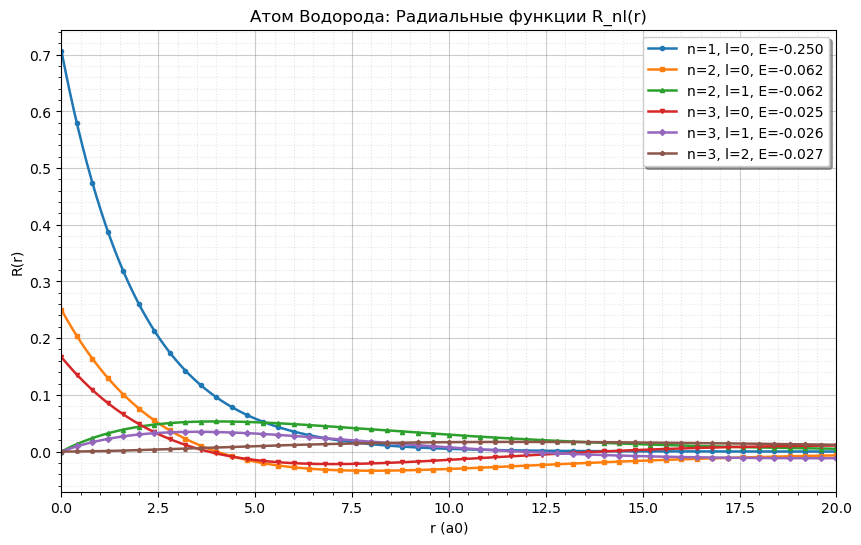

In [249]:
# ----------------------------------
#     Отрисовка радиальных функций
# ----------------------------------
y_wf = [res[4] for res in results_rad]
x_wf = [res[3] for res in results_rad]
labels_wf = [f"n={r[0]}, l={r[1]}, E={r[2]:.3f}" for r in results_rad]

pt.plot_signals(
    y_wf,
    x_wf,
    labels=labels_wf,
    markers=["o", "s", "^", "v", "D", "p"],
    markersize=3,
    markevery=20,
    title="Атом Водорода: Радиальные функции R_nl(r)",
    xlabel="r (a0)",
    ylabel="R(r)",
    limits=((0, 20), None),
)

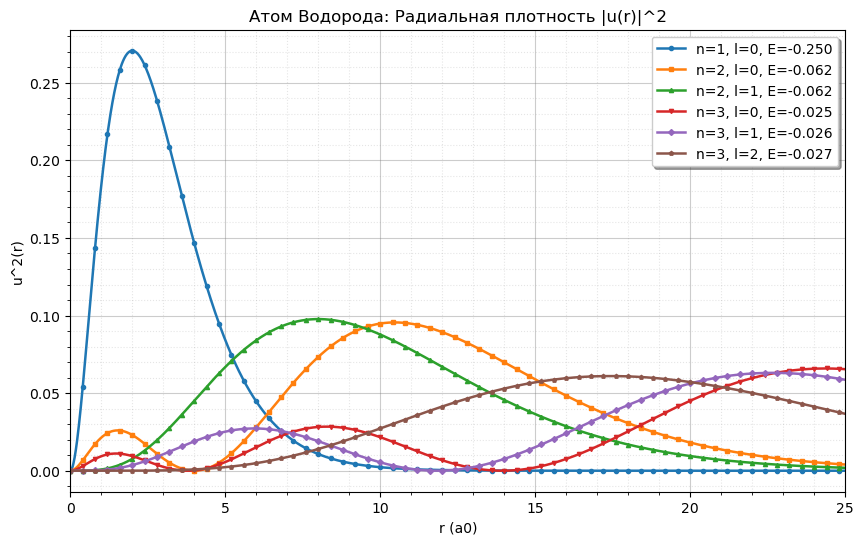

In [250]:
y_dens = [res[5] ** 2 for res in results_rad]

pt.plot_signals(
    y_dens,
    x_wf,
    labels=labels_wf,
    markers=["o", "s", "^", "v", "D", "p"],
    markersize=3,
    markevery=20,
    title="Атом Водорода: Радиальная плотность |u(r)|^2",
    xlabel="r (a0)",
    ylabel="u^2(r)",
    limits=((0, 25), None),
)

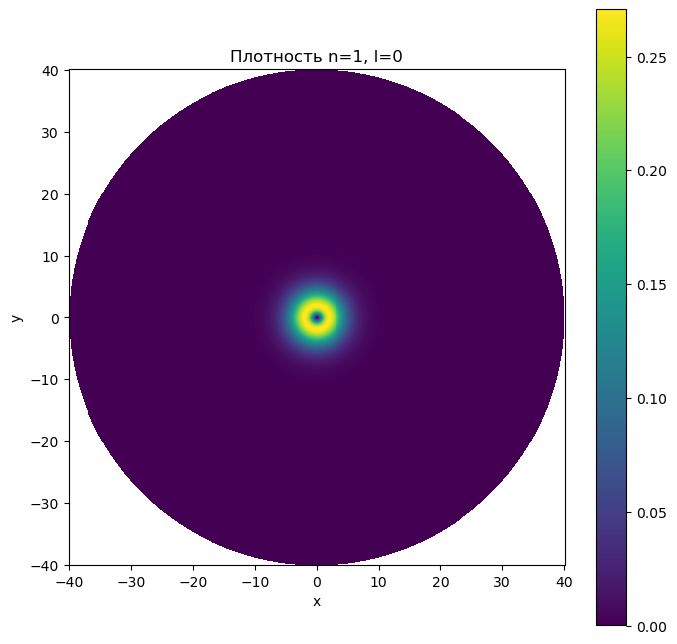

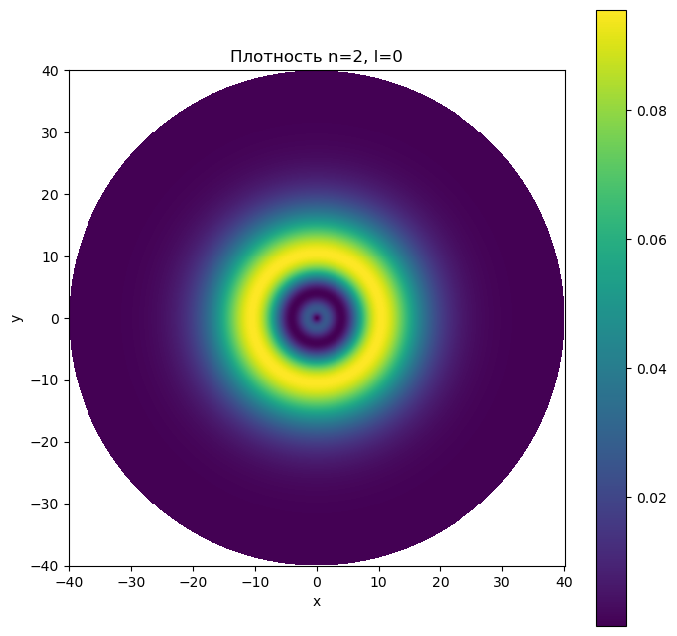

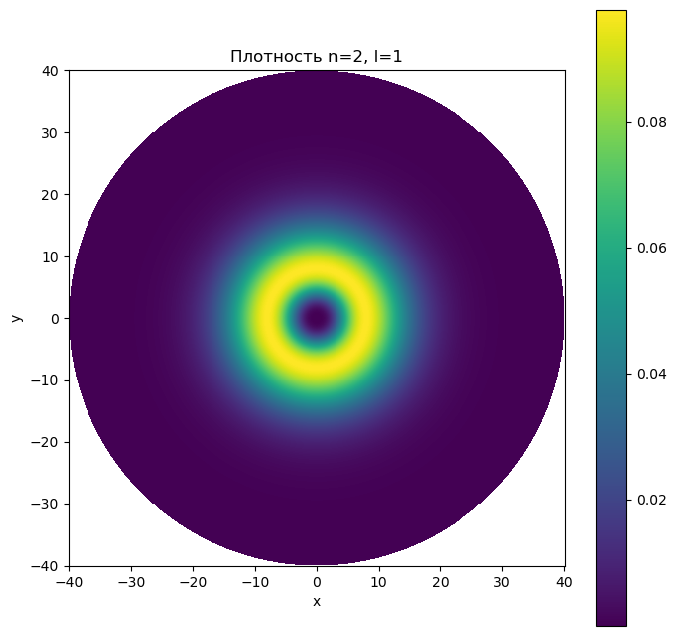

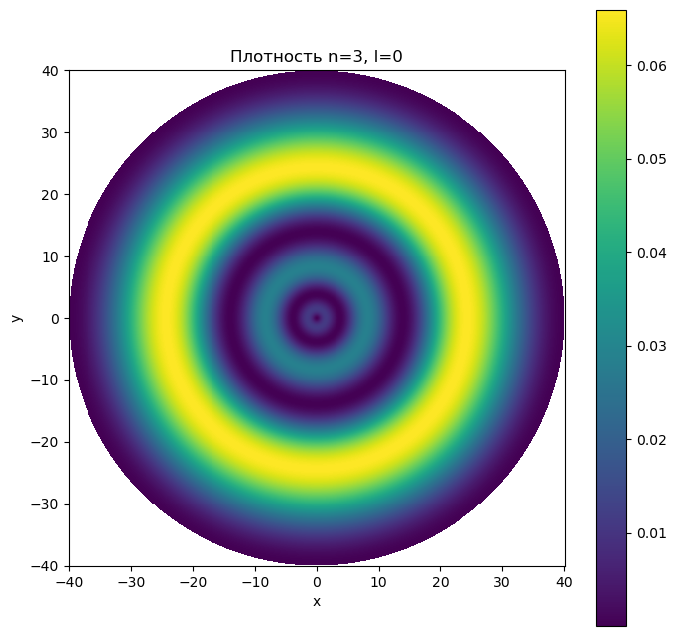

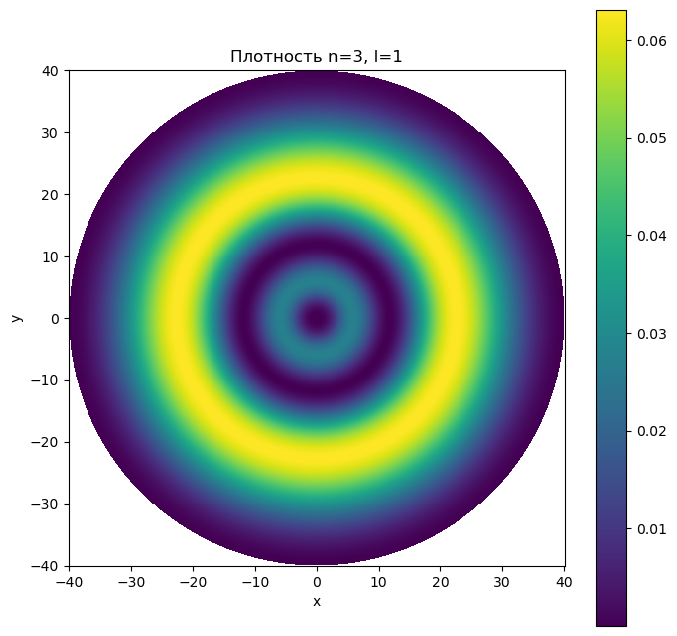

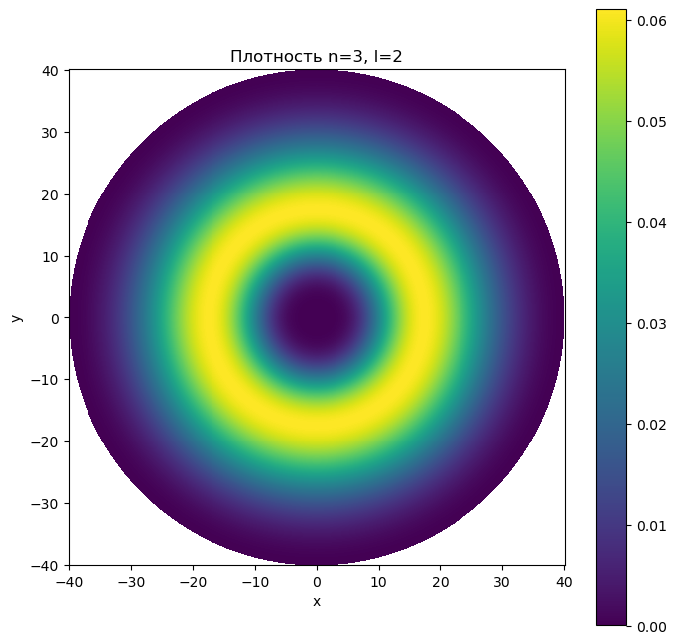

In [251]:
for n, l, E, r, R, u in results_rad[:]:
    pt.plot_radial_heatmap_2d(r, u**2, title=f"Плотность n={n}, l={l}")

In [252]:
# ----------------------------------
#     2. Сферические гармоники (Интегрирование полиномов Лежандра)
# ----------------------------------

def compute_associated_legendre(
    l_val: int, 
    m_val: int, 
    *, 
    N_theta: int = 300
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет присоединенные полиномы Лежандра P_l^m(cos(theta)).

    Выполняет численное интегрирование соответствующего дифференциального 
    уравнения методом Рунге-Кутты (RK8_DOP853) от 0 до pi (с отступами от полюсов).

    Parameters
    ----------
    - l_val : int
        Орбитальное квантовое число.
    - m_val : int
        Магнитное квантовое число (|m| <= l).
    - N_theta : int, optional
        Количество узлов пространственной сетки по углу theta.

    Returns
    -------
    - t_arr : (N_theta,) ndarray
        Сетка по углу theta в радианах.
    - P_sol : (N_theta,) ndarray
        Нормированные значения полинома Лежандра на сетке.

    Notes
    -----
    • *Mathematical foundation*
    - Уравнение для P_l^m(cos(theta)):
      P'' + cot(theta)P' + (l(l+1) - m^2/sin^2(theta))P = 0
    - Начальные условия на полюсе (theta -> 0) зависят от |m|:
      При m=0: P(0)=1, P'(0)=0. При m!=0: P ~ sin(theta)^|m|.
    """
    am = abs(m_val)
    eps_th = 1e-3
    
    # Асимптотические начальные условия вблизи полюса (theta = eps_th)
    P0 = 1.0 if am == 0 else (np.sin(eps_th) ** am)
    Q0 = 0.0 if am == 0 else (am * np.cos(eps_th) * (np.sin(eps_th) ** (am - 1)))

    def rhs(theta: float, y: np.ndarray) -> np.ndarray:
        st, ct = np.sin(theta), np.cos(theta)
        
        # Защита от деления на ноль на полюсах
        if abs(st) < 1e-14:
            st = 1e-14
            
        # Уравнение сводится к системе 1-го порядка
        # Shape: (2,)
        return np.array(
            [y[1], -(ct / st) * y[1] - (l_val * (l_val + 1) - am**2 / st**2) * y[0]],
            dtype=np.float64
        )

    # Решение задачи Коши
    solver = RK8_DOP853(
        rhs,
        eps_th,
        np.array([P0, Q0], dtype=np.float64),
        (np.pi - 2 * eps_th) / (N_theta - 1),
        np.pi - eps_th,
    )
    
    # Shape: t_arr is (Steps,), y_arr is (Steps, 2)
    t_arr, y_arr = solver.integrate()
    
    # Извлечение самого полинома
    # Shape: (Steps,)
    P_sol = y_arr[:, 0]
    
    # L2-Нормировка на сфере (интеграл от P^2 * sin(theta) d(theta))
    norm = float(np.sqrt(np.trapezoid(P_sol**2 * np.sin(t_arr), t_arr)))
    P_sol = P_sol / norm
    
    return t_arr, P_sol

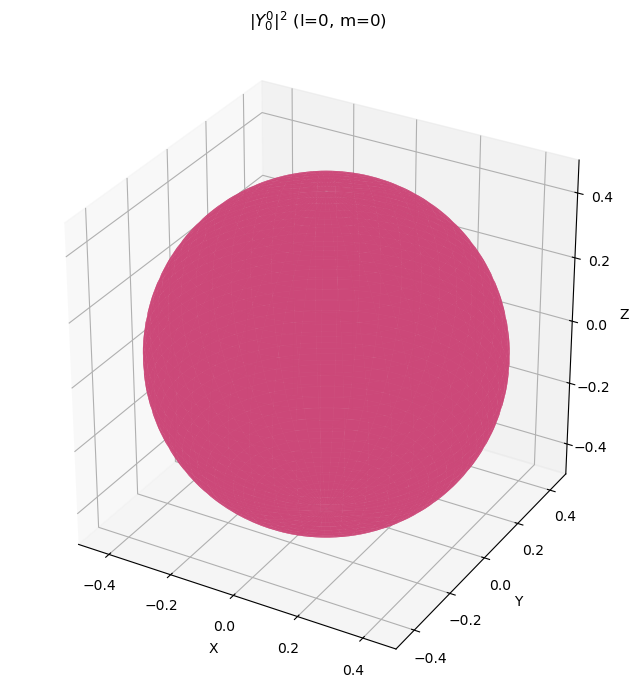

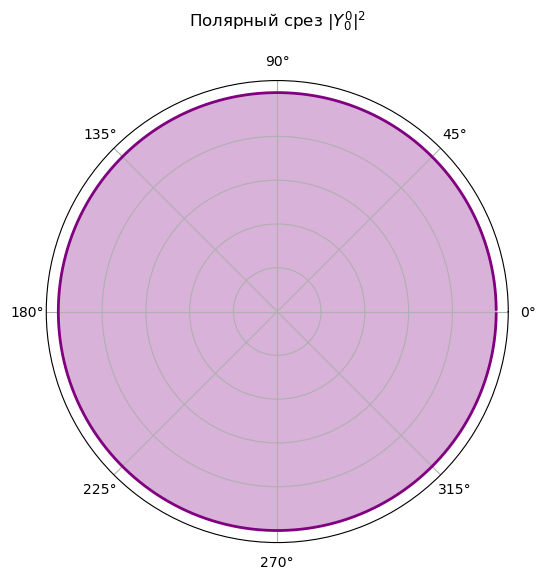

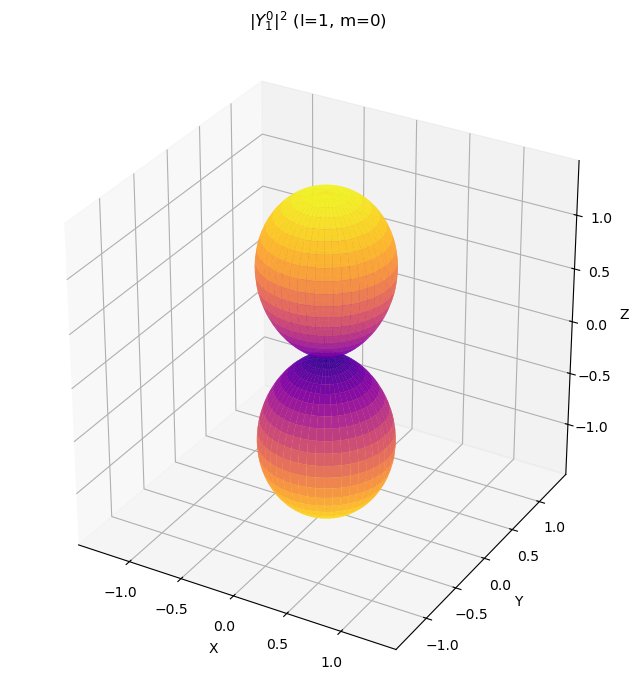

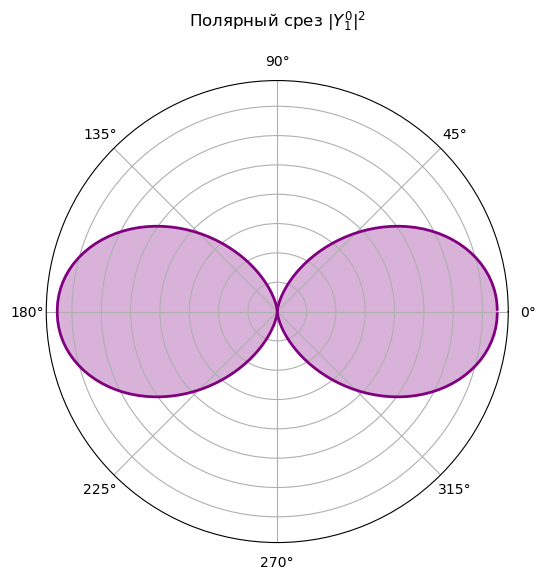

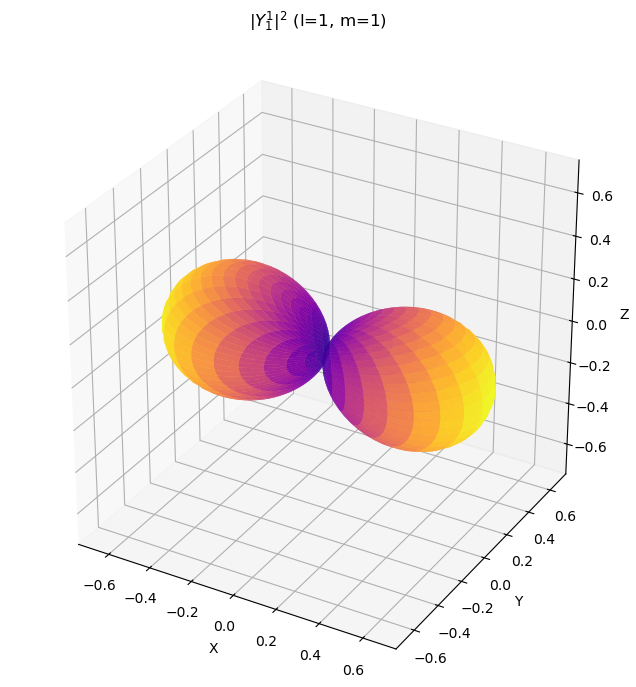

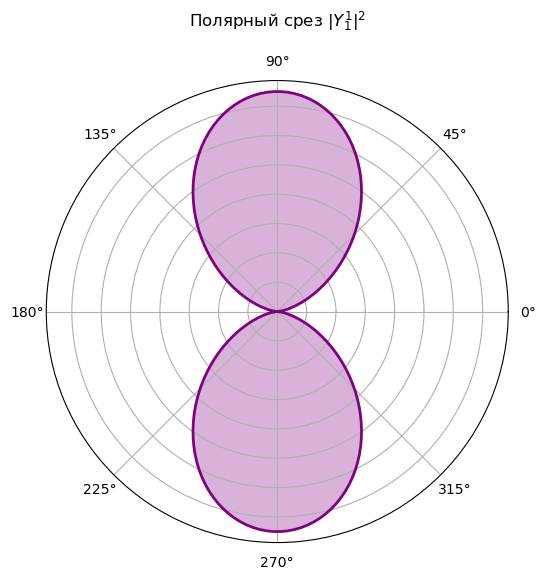

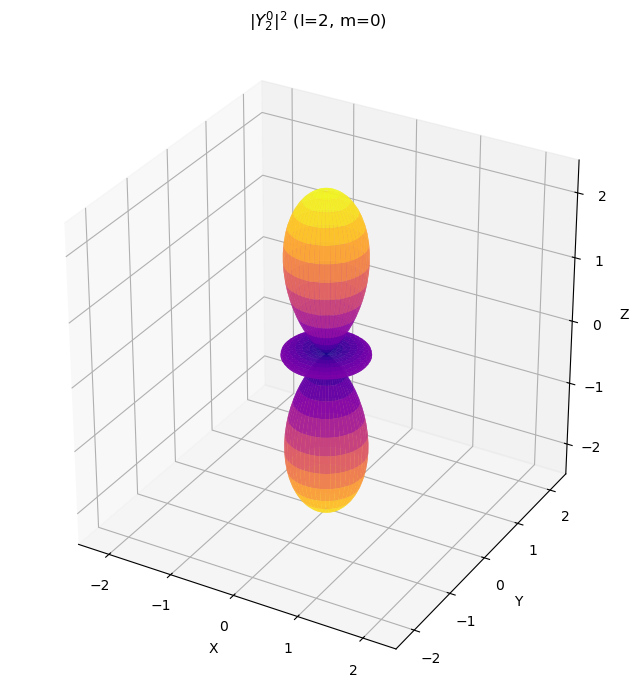

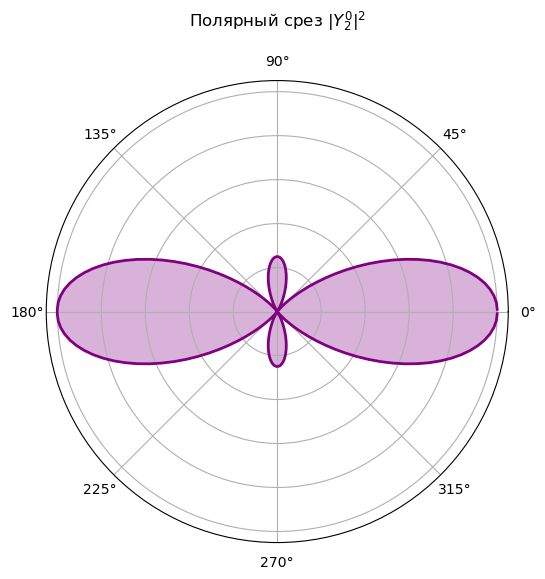

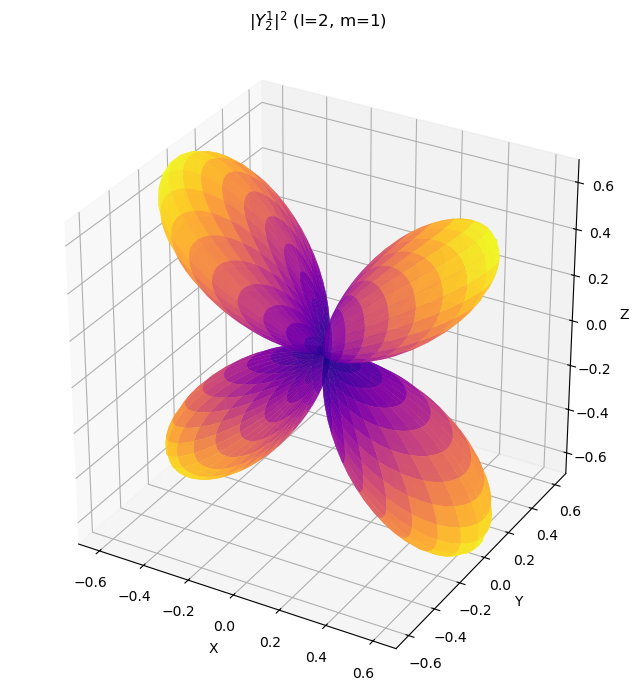

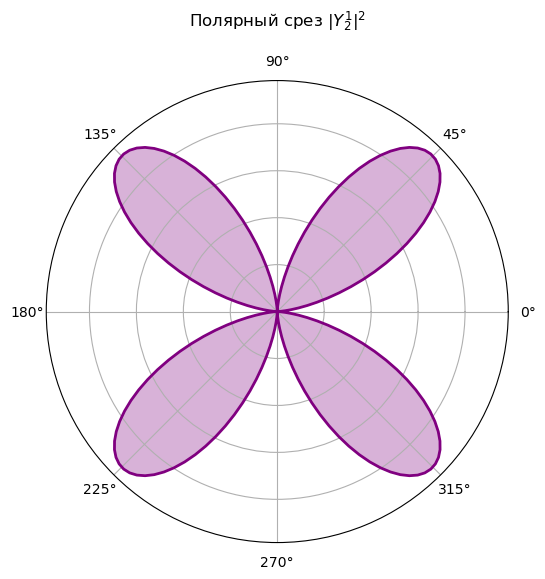

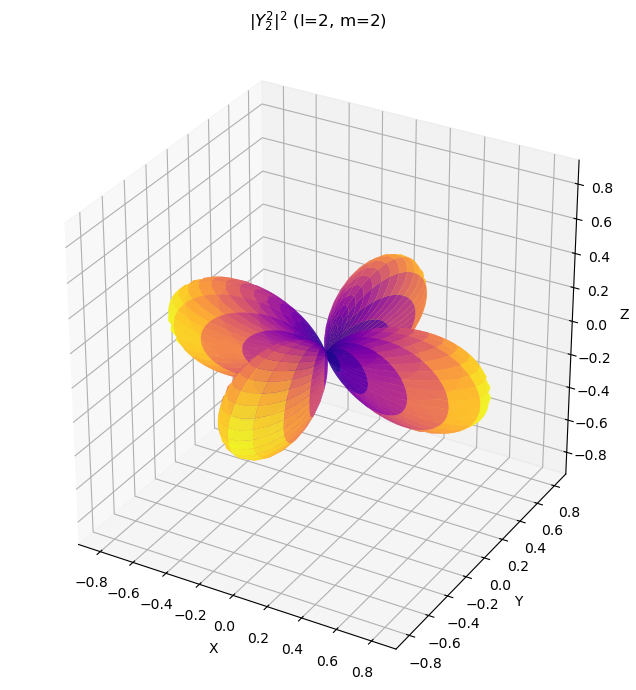

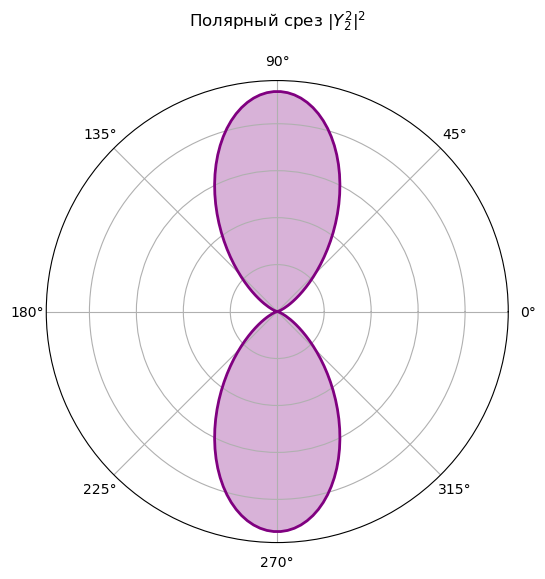

In [253]:
# ----------------------------------
#     Построение 3D графиков орбит
# ----------------------------------
# Сетка по азимутальному углу Phi [0, 2pi] и зенитному углу Theta [0, pi]
# Shape: Phi is (100, 100), Theta is (100, 100)
Phi, Theta = np.meshgrid(
    np.linspace(0, 2 * np.pi, 100), 
    np.linspace(0.01, np.pi - 0.01, 100)
)

for l_val, m_val in [(0, 0), (1, 0), (1, 1), (2, 0), (2, 1), (2, 2)]:
    # 1D срез углов Theta для интерполяции
    # Shape: (100,)
    theta_1d = Theta[:, 0]
    
    # Численное получение радиальной части Y_l^m (Полинома Лежандра)
    # Shape: theta_sol is (Steps,), P_sol is (Steps,)
    theta_sol, P_sol = compute_associated_legendre(l_val, m_val, N_theta=100)
    
    # Интерполяция на заданную сетку и размножение для 2D массива
    # Shape: (100, 100)
    P_2d = np.tile(np.interp(theta_1d, theta_sol, P_sol)[:, np.newaxis], (1, 100))
    
    # Угловая (азимутальная) часть (вещественная форма сферических гармоник)
    # Shape: (100, 100)
    angular = (
        np.cos(m_val * Phi)
        if m_val > 0
        else (np.sin(abs(m_val) * Phi) if m_val < 0 else np.ones_like(Phi))
    )

    # Квадрат модуля сферической гармоники (плотность вероятности)
    # Shape: (100, 100)
    R_sph = np.abs(P_2d * angular) ** 2
    
    # Переход в декартовы координаты для 3D визуализации
    # Shape: (100, 100)
    X_3d, Y_3d, Z_3d = (
        R_sph * np.sin(Theta) * np.cos(Phi),
        R_sph * np.sin(Theta) * np.sin(Phi),
        R_sph * np.cos(Theta),
    )

    pt.plot_spherical_harmonics_3d(
        X_3d,
        Y_3d,
        Z_3d,
        R_sph,
        title=rf"$|Y_{{{l_val}}}^{{{m_val}}}|^2$ (l={l_val}, m={m_val})",
    )

    # Полярный график (сечение орбитали)
    # Склейка двух полупериодов для создания замкнутой кривой (0 -> 2pi)
    # Shape: (200,)
    theta_full = np.concatenate([theta_1d, 2 * np.pi - theta_1d[::-1]])
    P_full = np.concatenate([P_sol, P_sol[::-1]])
    
    pt.plot_polar_curve(
        theta_full, 
        P_full**2, 
        title=rf"Полярный срез $|Y_{{{l_val}}}^{{{m_val}}}|^2$"
    )